In [1]:
print("TfL project ready!")

TfL project ready!


In [2]:
import requests

url = "https://api.tfl.gov.uk/StopPoint/Mode/tube"

params = {
    "page": 1
}

response = requests.get(url, params=params, timeout=30)

print("Status:", response.status_code)

data = response.json()

print(data.keys())
print("Number of stop points:", len(data["stopPoints"]))

Status: 200
dict_keys(['$type', 'stopPoints', 'pageSize', 'total', 'page'])
Number of stop points: 1000


In [3]:
print("Page:", data["page"])
print("Page size:", data["pageSize"])
print("Total records:", data["total"])import requests
import pandas as pd

url = "https://api.tfl.gov.uk/StopPoint/Mode/tube"

all_stop_points = []
page = 1

while True:

    params = {
        "page": page
    }

    response = requests.get(
        url,
        params=params,
        timeout=30
    )

    response.raise_for_status()

    data = response.json()

    all_stop_points.extend(
        data["stopPoints"]
    )

    print(
        f"Page {page} downloaded - "
        f"{len(data['stopPoints'])} records"
    )

    if len(all_stop_points) >= data["total"]:
        break

    page += 1

print()
print("Total downloaded:", len(all_stop_points))

Page: 1
Page size: 1000
Total records: 1751


In [7]:
%pip install pandas

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
import pandas as pd

print("Pandas version:", pd.__version__)

Pandas version: 3.0.5


In [15]:
import requests

url = "https://api.tfl.gov.uk/StopPoint/Mode/tube"

all_stop_points = []
page = 1

while True:
    params = {
        "page": page
    }

    response = requests.get(
        url,
        params=params,
        timeout=30
    )

    response.raise_for_status()

    data = response.json()

    all_stop_points.extend(data["stopPoints"])

    print(
        f"Page {page}: "
        f"{len(data['stopPoints'])} records"
    )

    if len(all_stop_points) >= data["total"]:
        break

    page += 1

print("Total downloaded:", len(all_stop_points))

Page 1: 1000 records
Page 2: 751 records
Total downloaded: 1751


In [16]:
import pandas as pd

stations = pd.DataFrame([
    {
        "station_id": x.get("id"),
        "naptan_id": x.get("naptanId"),
        "station_name": x.get("commonName"),
        "latitude": x.get("lat"),
        "longitude": x.get("lon"),
        "stop_type": x.get("stopType"),
        "modes": ", ".join(x.get("modes", []))
    }
    for x in all_stop_points
])

display(stations.head())

print("Shape:", stations.shape)print(stations["stop_type"].value_counts(dropna=False))

,station_id,naptan_id,station_name,latitude,longitude,stop_type,modes
0,4900ZZLUACT1,4900ZZLUACT1,Acton Town Station,51.503010,-0.280420,NaptanMetroEntrance,tube
1,4900ZZLUACT2,4900ZZLUACT2,Acton Town Station,51.503240,-0.279910,NaptanMetroEntrance,tube
2,9400ZZLUACT,9400ZZLUACT,Acton Town Underground Station,51.503057,-0.280462,NaptanMetroAccessArea,tube
3,9400ZZLUACT1,9400ZZLUACT1,Acton Town Underground Station,51.502890,-0.280079,NaptanMetroPlatform,tube
4,9400ZZLUACT2,9400ZZLUACT2,Acton Town Underground Station,51.502844,-0.280009,NaptanMetroPlatform,tube


Shape: (1751, 7)


In [17]:
print(stations["stop_type"].value_counts(dropna=False))

stop_type
NaptanMetroPlatform      571
NaptanMetroEntrance      490
NaptanMetroAccessArea    272
NaptanMetroStation       272
NaptanRailAccessArea      77
TransportInterchange      69
Name: count, dtype: int64


In [18]:
tube_stations = stations[
    stations["stop_type"] == "NaptanMetroStation"
].copy()

print("Tube stations:", len(tube_stations))

display(tube_stations.head())print(
    "Duplicate station IDs:",
    tube_stations["station_id"].duplicated().sum()
)

print(
    "Duplicate station names:",
    tube_stations["station_name"].duplicated().sum()
)

Tube stations: 272


,station_id,naptan_id,station_name,latitude,longitude,stop_type,modes
7,940GZZLUACT,940GZZLUACT,Acton Town Underground Station,51.503057,-0.280462,NaptanMetroStation,tube
17,940GZZLUADE,940GZZLUADE,Aldgate East Underground Station,51.515037,-0.072384,NaptanMetroStation,tube
24,940GZZLUALD,940GZZLUALD,Aldgate Underground Station,51.514246,-0.075689,NaptanMetroStation,tube
29,940GZZLUALP,940GZZLUALP,Alperton Underground Station,51.540627,-0.299610,NaptanMetroStation,tube
35,940GZZLUAMS,940GZZLUAMS,Amersham Underground Station,51.674126,-0.607714,NaptanMetroStation,tube


In [19]:
print(
    "Duplicate station IDs:",
    tube_stations["station_id"].duplicated().sum()
)

print(
    "Duplicate station names:",
    tube_stations["station_name"].duplicated().sum()
)tube_stations.to_csv(
    "tfl_tube_stations_clean.csv",
    index=False
)

Duplicate station IDs: 0
Duplicate station names: 0


In [22]:
tube_stations.to_csv(
    "tfl_tube_stations_clean.csv",
    index=False
)

In [23]:
import requests
import pandas as pd
from datetime import datetime

url = "https://api.tfl.gov.uk/Line/Mode/tube/Status"

response = requests.get(url, timeout=30)
response.raise_for_status()

line_data = response.json()

print("Lines returned:", len(line_data))

Lines returned: 11


In [24]:
line_status = []

for line in line_data:
    for status in line.get("lineStatuses", []):
        line_status.append({
            "timestamp": datetime.now(),
            "line_id": line.get("id"),
            "line_name": line.get("name"),
            "mode": line.get("modeName"),
            "status_severity": status.get("statusSeverity"),
            "status_description": status.get("statusSeverityDescription"),
            "reason": status.get("reason")
        })

line_status_df = pd.DataFrame(line_status)

display(line_status_df)

,timestamp,line_id,line_name,mode,status_severity,status_description,reason
0,2026-09-04 23:15:07.700405,bakerloo,Bakerloo,tube,10,Good Service,NaN
1,2026-09-04 23:15:07.700424,central,Central,tube,10,Good Service,NaN
2,2026-09-04 23:15:07.700428,circle,Circle,tube,10,Good Service,NaN
3,2026-09-04 23:15:07.700430,district,District,tube,10,Good Service,NaN
4,2026-09-04 23:15:07.700432,hammersmith-city,Hammersmith & City,tube,10,Good Service,NaN
5,2026-09-04 23:15:07.700435,jubilee,Jubilee,tube,6,Severe Delays,Jubilee Line: No service between Waterloo and ...
6,2026-09-04 23:15:07.700437,jubilee,Jubilee,tube,3,Part Suspended,Jubilee Line: No service between Waterloo and ...
7,2026-09-04 23:15:07.700438,metropolitan,Metropolitan,tube,10,Good Service,NaN
8,2026-09-04 23:15:07.700440,northern,Northern,tube,10,Good Service,NaN
9,2026-09-04 23:15:07.700442,piccadilly,Piccadilly,tube,9,Minor Delays,Piccadilly Line: Minor delays between Acton To...


In [25]:
line_status_df.to_csv(
    "tfl_line_status_current.csv",
    index=False
)

In [26]:
import requests

url = "https://api.tfl.gov.uk/Line/Meta/Modes"

response = requests.get(url, timeout=30)

print("Status:", response.status_code)

modes = response.json()

for mode in modes:
    print(mode.get("modeName"))

Status: 200
bus
cable-car
coach
cycle
cycle-hire
dlr
elizabeth-line
interchange-keep-sitting
interchange-secure
national-rail
overground
replacement-bus
river-bus
river-tour
taxi
tram
tube
walking


In [29]:
import requests
import pandas as pd
import time

modes = [
    "tube",
    "elizabeth-line",
    "overground",
    "dlr",
    "bus",
    "national-rail"
]

all_records = []

for mode in modes:
    page = 1

    while True:
        url = f"https://api.tfl.gov.uk/StopPoint/Mode/{mode}"

        response = requests.get(
            url,
            params={"page": page},
            timeout=30
        )

        # If rate-limited, wait and retry
        if response.status_code == 429:
            print(f"{mode} | rate limit reached, waiting 60 seconds...")
            time.sleep(60)
            continue

        response.raise_for_status()
        data = response.json()

        records = data.get("stopPoints", [])

        # Stop if no more records
        if len(records) == 0:
            break

        for x in records:
            all_records.append({
                "mode_requested": mode,
                "station_id": x.get("id"),
                "naptan_id": x.get("naptanId"),
                "station_name": x.get("commonName"),
                "latitude": x.get("lat"),
                "longitude": x.get("lon"),
                "stop_type": x.get("stopType"),
                "modes": ", ".join(x.get("modes", []))
            })

        print(
            f"{mode} | page {page} | "
            f"{len(records)} records"
        )

        page += 1

        # Small pause to reduce API pressure
        time.sleep(1)

stations_all = pd.DataFrame(all_records)

print("\nTotal records:", len(stations_all))
display(stations_all.head())

tube | page 1 | 1000 records
tube | page 2 | 751 records
elizabeth-line | page 1 | 119 records
overground | page 1 | 546 records
dlr | page 1 | 274 records
bus | page 1 | 1000 records
bus | page 2 | 1000 records
bus | page 3 | 1000 records
bus | page 4 | 1000 records
bus | page 5 | 1000 records
bus | page 6 | 1000 records
bus | page 7 | 1000 records
bus | page 8 | 1000 records
bus | page 9 | 1000 records
bus | page 10 | 1000 records
bus | page 11 | 1000 records
bus | page 12 | 1000 records
bus | page 13 | 1000 records
bus | page 14 | 1000 records
bus | page 15 | 1000 records
bus | page 16 | 1000 records
bus | page 17 | 1000 records
bus | page 18 | 1000 records
bus | page 19 | 1000 records
bus | page 20 | 1000 records
bus | page 21 | 1000 records
bus | page 22 | 1000 records
bus | page 23 | 1000 records
bus | page 24 | 1000 records
bus | page 25 | 1000 records
bus | page 26 | 1000 records
bus | page 27 | 1000 records
bus | page 28 | 1000 records
bus | page 29 | 1000 records
bus | page 3

,mode_requested,station_id,naptan_id,station_name,latitude,longitude,stop_type,modes
0,tube,4900ZZLUACT1,4900ZZLUACT1,Acton Town Station,51.503010,-0.280420,NaptanMetroEntrance,tube
1,tube,4900ZZLUACT2,4900ZZLUACT2,Acton Town Station,51.503240,-0.279910,NaptanMetroEntrance,tube
2,tube,9400ZZLUACT,9400ZZLUACT,Acton Town Underground Station,51.503057,-0.280462,NaptanMetroAccessArea,tube
3,tube,9400ZZLUACT1,9400ZZLUACT1,Acton Town Underground Station,51.502890,-0.280079,NaptanMetroPlatform,tube
4,tube,9400ZZLUACT2,9400ZZLUACT2,Acton Town Underground Station,51.502844,-0.280009,NaptanMetroPlatform,tube


In [30]:
# Records by mode and stop type

stop_type_summary = (
    stations_all
    .groupby(["mode_requested", "stop_type"])
    .size()
    .reset_index(name="record_count")
)

display(stop_type_summary)

,mode_requested,stop_type,record_count
0,bus,NaptanBusCoachStation,27
1,bus,NaptanCoachBay,42
2,bus,NaptanCoachVariableBay,1
3,bus,NaptanFerryEntrance,1
4,bus,NaptanFerryPort,2
5,bus,NaptanMetroEntrance,10
6,bus,NaptanMetroStation,14
7,bus,NaptanOnstreetBusCoachStopCluster,172
8,bus,NaptanOnstreetBusCoachStopPair,11058
9,bus,NaptanPublicBusCoachTram,21018


In [31]:
print("Total records:", len(stations_all))

print(
    "Unique station/stop IDs:",
    stations_all["station_id"].nunique()
)

print(
    "Duplicate IDs:",
    stations_all["station_id"].duplicated().sum()
)

print(
    "Missing coordinates:",
    stations_all[["latitude", "longitude"]]
    .isna()
    .any(axis=1)
    .sum()
)

print(
    "Unique names:",
    stations_all["station_name"].nunique()
)

Total records: 42150
Unique station/stop IDs: 41741
Duplicate IDs: 409
Missing coordinates: 0
Unique names: 13925


In [32]:
stations_all.to_csv(
    "tfl_all_modes_stoppoints_raw.csv",
    index=False
)

print("Raw StopPoint dataset saved.")stop_type_summary = (
    stations_all
    .groupby(["mode_requested", "stop_type"])
    .size()
    .reset_index(name="record_count")
)

display(stop_type_summary)

Raw StopPoint dataset saved.


In [33]:
stop_type_summary = (
    stations_all
    .groupby(["mode_requested", "stop_type"])
    .size()
    .reset_index(name="record_count")
)

display(stop_type_summary)

,mode_requested,stop_type,record_count
0,bus,NaptanBusCoachStation,27
1,bus,NaptanCoachBay,42
2,bus,NaptanCoachVariableBay,1
3,bus,NaptanFerryEntrance,1
4,bus,NaptanFerryPort,2
5,bus,NaptanMetroEntrance,10
6,bus,NaptanMetroStation,14
7,bus,NaptanOnstreetBusCoachStopCluster,172
8,bus,NaptanOnstreetBusCoachStopPair,11058
9,bus,NaptanPublicBusCoachTram,21018


In [34]:
for mode in stations_all["mode_requested"].unique():
    
    print(f"\n--- {mode.upper()} ---")
    
    print(
        stations_all.loc[
            stations_all["mode_requested"] == mode,
            "stop_type"
        ].value_counts()
    )


--- TUBE ---
stop_type
NaptanMetroPlatform      571
NaptanMetroEntrance      490
NaptanMetroAccessArea    272
NaptanMetroStation       272
NaptanRailAccessArea      77
TransportInterchange      69
Name: count, dtype: int64

--- ELIZABETH-LINE ---
stop_type
NaptanRailAccessArea    62
NaptanRailStation       43
TransportInterchange    14
Name: count, dtype: int64

--- OVERGROUND ---
stop_type
NaptanRailAccessArea    209
NaptanRailEntrance      178
NaptanRailStation       115
TransportInterchange     39
NaptanMetroEntrance       5
Name: count, dtype: int64

--- DLR ---
stop_type
NaptanMetroPlatform      84
NaptanMetroEntrance      73
NaptanMetroAccessArea    45
NaptanMetroStation       45
TransportInterchange     15
NaptanRailAccessArea     10
NaptanRailEntrance        2
Name: count, dtype: int64

--- BUS ---
stop_type
NaptanPublicBusCoachTram             21018
NaptanOnstreetBusCoachStopPair       11058
NaptanOnstreetBusCoachStopCluster      172
TransportInterchange                    92

In [35]:
rail_filters = {
    "tube": "NaptanMetroStation",
    "dlr": "NaptanMetroStation",
    "elizabeth-line": "NaptanRailStation",
    "overground": "NaptanRailStation",
    "national-rail": "NaptanRailStation"
}

rail_parts = []

for mode, stop_type in rail_filters.items():
    
    temp = stations_all[
        (stations_all["mode_requested"] == mode) &
        (stations_all["stop_type"] == stop_type)
    ].copy()

    rail_parts.append(temp)

rail_stations = pd.concat(
    rail_parts,
    ignore_index=True
)

display(rail_stations.head())

print("Rail station records:", len(rail_stations))
print(
    "Unique IDs:",
    rail_stations["station_id"].nunique()
)

,mode_requested,station_id,naptan_id,station_name,latitude,longitude,stop_type,modes
0,tube,940GZZLUACT,940GZZLUACT,Acton Town Underground Station,51.503057,-0.280462,NaptanMetroStation,tube
1,tube,940GZZLUADE,940GZZLUADE,Aldgate East Underground Station,51.515037,-0.072384,NaptanMetroStation,tube
2,tube,940GZZLUALD,940GZZLUALD,Aldgate Underground Station,51.514246,-0.075689,NaptanMetroStation,tube
3,tube,940GZZLUALP,940GZZLUALP,Alperton Underground Station,51.540627,-0.299610,NaptanMetroStation,tube
4,tube,940GZZLUAMS,940GZZLUAMS,Amersham Underground Station,51.674126,-0.607714,NaptanMetroStation,tube


Rail station records: 2933
Unique IDs: 2861


In [36]:
bus_stops = stations_all[
    (stations_all["mode_requested"] == "bus") &
    (stations_all["stop_type"] == "NaptanPublicBusCoachTram")
].copy()

print("Bus stop records:", len(bus_stops))

print(
    "Unique bus stop IDs:",
    bus_stops["station_id"].nunique()
)

display(bus_stops.head())

Bus stop records: 21018
Unique bus stop IDs: 21018


,mode_requested,station_id,naptan_id,station_name,latitude,longitude,stop_type,modes
2690,bus,490004889E,490004889E,Abbeville Road,51.45264,-0.14249,NaptanPublicBusCoachTram,bus
2691,bus,490004889W,490004889W,Abbeville Road,51.45273,-0.14290,NaptanPublicBusCoachTram,bus
2693,bus,490003025W,490003025W,Abbey Lane,51.53378,-0.00718,NaptanPublicBusCoachTram,bus
2695,bus,490003027W,490003027W,Abbey Road,51.53997,-0.18668,NaptanPublicBusCoachTram,bus
2696,bus,490003028E,490003028E,Abbey Road,51.52934,-0.26991,NaptanPublicBusCoachTram,bus


In [37]:
rail_duplicates = rail_stations[
    rail_stations["station_id"].duplicated(
        keep=False
    )
].sort_values(
    ["station_id", "mode_requested"]
)

print(
    "Duplicated rail IDs:",
    rail_stations["station_id"]
    .duplicated()
    .sum()
)

display(
    rail_duplicates[
        [
            "station_id",
            "station_name",
            "mode_requested",
            "stop_type",
            "modes"
        ]
    ].head(50)
)

Duplicated rail IDs: 72


,station_id,station_name,mode_requested,stop_type,modes
318,910GACTONML,Acton Main Line Rail Station,elizabeth-line,NaptanRailStation,"elizabeth-line, national-rail"
494,910GACTONML,Acton Main Line Rail Station,national-rail,NaptanRailStation,"elizabeth-line, national-rail"
535,910GANERLEY,Anerley Rail Station,national-rail,NaptanRailStation,"national-rail, overground"
361,910GANERLEY,Anerley Rail Station,overground,NaptanRailStation,"national-rail, overground"
621,910GBARKING,Barking Rail Station,national-rail,NaptanRailStation,"national-rail, overground"
362,910GBARKING,Barking Rail Station,overground,NaptanRailStation,"national-rail, overground"
321,910GBNHAM,Burnham (Berks) Rail Station,elizabeth-line,NaptanRailStation,"elizabeth-line, national-rail"
856,910GBNHAM,Burnham (Berks) Rail Station,national-rail,NaptanRailStation,"elizabeth-line, national-rail"
821,910GBROCKLY,Brockley Rail Station,national-rail,NaptanRailStation,"national-rail, overground"
366,910GBROCKLY,Brockley Rail Station,overground,NaptanRailStation,"national-rail, overground"


In [38]:
rail_stations.to_csv(
    "tfl_rail_stations_clean.csv",
    index=False
)

bus_stops.to_csv(
    "tfl_bus_stops_clean.csv",
    index=False
)

print("Files saved successfully.")import requests
import pandas as pd
from datetime import datetime

modes = [
    "tube",
    "elizabeth-line",
    "overground",
    "dlr"
]

status_records = []

for mode in modes:
    
    url = f"https://api.tfl.gov.uk/Line/Mode/{mode}/Status"
    
    response = requests.get(url, timeout=30)
    response.raise_for_status()
    
    data = response.json()
    
    for line in data:
        for status in line.get("lineStatuses", []):
            
            status_records.append({
                "collected_at": datetime.now(),
                "mode": mode,
                "line_id": line.get("id"),
                "line_name": line.get("name"),
                "status_severity": status.get("statusSeverity"),
                "status": status.get("statusSeverityDescription"),
                "reason": status.get("reason")
            })

line_status = pd.DataFrame(status_records)

display(line_status)

print("Records:", len(line_status))

Files saved successfully.


In [39]:
import requests
import pandas as pd
from datetime import datetime

modes = [
    "tube",
    "elizabeth-line",
    "overground",
    "dlr"
]

status_records = []

for mode in modes:
    
    url = f"https://api.tfl.gov.uk/Line/Mode/{mode}/Status"
    
    response = requests.get(url, timeout=30)
    response.raise_for_status()
    
    data = response.json()
    
    for line in data:
        for status in line.get("lineStatuses", []):
            
            status_records.append({
                "collected_at": datetime.now(),
                "mode": mode,
                "line_id": line.get("id"),
                "line_name": line.get("name"),
                "status_severity": status.get("statusSeverity"),
                "status": status.get("statusSeverityDescription"),
                "reason": status.get("reason")
            })

line_status = pd.DataFrame(status_records)

display(line_status)

print("Records:", len(line_status))

,collected_at,mode,line_id,line_name,status_severity,status,reason
0,2026-09-04 23:40:20.334080,tube,bakerloo,Bakerloo,10,Good Service,NaN
1,2026-09-04 23:40:20.334109,tube,central,Central,10,Good Service,NaN
2,2026-09-04 23:40:20.334115,tube,circle,Circle,10,Good Service,NaN
3,2026-09-04 23:40:20.334118,tube,district,District,10,Good Service,NaN
4,2026-09-04 23:40:20.334121,tube,hammersmith-city,Hammersmith & City,10,Good Service,NaN
5,2026-09-04 23:40:20.334125,tube,jubilee,Jubilee,6,Severe Delays,Jubilee Line: No service between Waterloo and ...
6,2026-09-04 23:40:20.334129,tube,jubilee,Jubilee,3,Part Suspended,Jubilee Line: No service between Waterloo and ...
7,2026-09-04 23:40:20.334132,tube,metropolitan,Metropolitan,10,Good Service,NaN
8,2026-09-04 23:40:20.334135,tube,northern,Northern,10,Good Service,NaN
9,2026-09-04 23:40:20.334137,tube,piccadilly,Piccadilly,10,Good Service,NaN


Records: 20


In [40]:
line_status.to_csv(
    "tfl_line_status_current.csv",
    index=False
)

print("Line status saved.")

Line status saved.


In [41]:
import requests
import pandas as pd
from datetime import datetime

modes = [
    "tube",
    "elizabeth-line",
    "overground",
    "dlr"
]

disruption_records = []

for mode in modes:

    url = f"https://api.tfl.gov.uk/Line/Mode/{mode}/Disruption"

    response = requests.get(
        url,
        timeout=30
    )

    print(mode, "Status:", response.status_code)

    response.raise_for_status()
    data = response.json()

    for d in data:

        disruption_records.append({
            "collected_at": datetime.now(),
            "mode": mode,
            "category": d.get("category"),
            "category_description": d.get("categoryDescription"),
            "description": d.get("description"),
            "closure_text": d.get("closureText"),
            "additional_info": d.get("additionalInfo")
        })

disruptions = pd.DataFrame(disruption_records)

print("\nTotal disruptions:", len(disruptions))

display(disruptions)

tube Status: 200
elizabeth-line Status: 200
overground Status: 200
dlr Status: 200

Total disruptions: 4


,collected_at,mode,category,category_description,description,closure_text,additional_info
0,2026-09-04 23:41:50.891839,tube,RealTime,RealTime,Victoria Line: Minor delays due to train cance...,minorDelays,None
1,2026-09-04 23:41:50.891866,tube,RealTime,RealTime,Jubilee Line: No service between Waterloo and ...,severeDelays,None
2,2026-09-04 23:41:50.891873,tube,RealTime,RealTime,Jubilee Line: No service between Waterloo and ...,partSuspended,None
3,2026-09-04 23:41:53.646538,overground,RealTime,RealTime,Mildmay Line: Severe delays due to an earlier ...,severeDelays,None


In [42]:
print(disruptions.columns.tolist())

print()

if not disruptions.empty:
    print(disruptions["mode"].value_counts())
    print()
    print(disruptions["category"].value_counts(dropna=False))
else:
    print("No current disruptions found.")

['collected_at', 'mode', 'category', 'category_description', 'description', 'closure_text', 'additional_info']

mode
tube          3
overground    1
Name: count, dtype: int64

category
RealTime    4
Name: count, dtype: int64


In [43]:
disruptions.to_csv(
    "tfl_disruptions_current.csv",
    index=False
)

print("Disruption snapshot saved.")

Disruption snapshot saved.


In [44]:
stratford = rail_stations[
    rail_stations["station_name"]
    .str.contains("Stratford", case=False, na=False)
]

display(
    stratford[
        ["station_id", "station_name", "mode_requested", "modes"]
    ]
)

,station_id,station_name,mode_requested,modes
222,940GZZLUSTD,Stratford Underground Station,tube,tube
308,940GZZDLSTD,Stratford DLR Station,dlr,dlr
309,940GZZDLSHS,Stratford High Street DLR Station,dlr,dlr
310,940GZZDLSIT,Stratford International DLR Station,dlr,dlr
352,910GSTFD,Stratford (London) Rail Station,elizabeth-line,"elizabeth-line, national-rail, overground"
451,910GSTFD,Stratford (London) Rail Station,overground,"elizabeth-line, national-rail, overground"
1306,910GFSTR,Fenny Stratford Rail Station,national-rail,national-rail
2575,910GSTFD,Stratford (London) Rail Station,national-rail,"elizabeth-line, national-rail, overground"
2576,910GSTFODOM,Stratford International Rail Station,national-rail,national-rail
2577,910GSOAVPWY,Stratford-upon-Avon Parkway Rail Station,national-rail,national-rail


In [45]:
station_id = "940GZZLUSTD"

url = f"https://api.tfl.gov.uk/StopPoint/{station_id}/Arrivals"

response = requests.get(
    url,
    timeout=30
)

print("Status:", response.status_code)

response.raise_for_status()

arrival_data = response.json()

print("Arrival predictions:", len(arrival_data))

Status: 200
Arrival predictions: 23


In [46]:
from datetime import datetime
import pandas as pd

arrival_records = []

for x in arrival_data:

    arrival_records.append({
        "collected_at": datetime.now(),
        "prediction_id": x.get("id"),
        "vehicle_id": x.get("vehicleId"),
        "station_id": x.get("naptanId"),
        "station_name": x.get("stationName"),
        "line_id": x.get("lineId"),
        "line_name": x.get("lineName"),
        "platform_name": x.get("platformName"),
        "destination_name": x.get("destinationName"),
        "direction": x.get("direction"),
        "time_to_station_seconds": x.get("timeToStation"),
        "expected_arrival": x.get("expectedArrival"),
        "current_location": x.get("currentLocation"),
        "towards": x.get("towards")
    })

arrivals = pd.DataFrame(arrival_records)

display(arrivals.head(20))

print("Records:", len(arrivals))

,collected_at,prediction_id,vehicle_id,station_id,station_name,line_id,line_name,platform_name,destination_name,direction,time_to_station_seconds,expected_arrival,current_location,towards
0,2026-09-04 23:55:15.683968,-721357303,005,940GZZLUSTD,Stratford Underground Station,central,Central,Westbound - Platform 3,West Ruislip Underground Station,inbound,1031,2026-09-04T23:01:06Z,Woodford Junction,West Ruislip
1,2026-09-04 23:55:15.683988,-1230537996,016,940GZZLUSTD,Stratford Underground Station,central,Central,Eastbound - Platform 6,Hainault Underground Station,outbound,191,2026-09-04T22:47:06Z,Between Mile End and Stratford,Hainault via Newbury Park
2,2026-09-04 23:55:15.683995,-2033697006,030,940GZZLUSTD,Stratford Underground Station,central,Central,Eastbound - Platform 6,Hainault Underground Station,outbound,911,2026-09-04T22:59:06Z,At St. Paul's,Hainault via Newbury Park
3,2026-09-04 23:55:15.683999,-2034811118,040,940GZZLUSTD,Stratford Underground Station,central,Central,Eastbound - Platform 6,Grange Hill Underground Station,outbound,431,2026-09-04T22:51:06Z,At Bethnal Green,Grange Hill via Woodford
4,2026-09-04 23:55:15.684003,-2035007726,070,940GZZLUSTD,Stratford Underground Station,central,Central,Westbound - Platform 3,West Ruislip Underground Station,inbound,310,2026-09-04T22:49:05Z,Left Leytonstone,West Ruislip
5,2026-09-04 23:55:15.684007,1751163900,121,940GZZLUSTD,Stratford Underground Station,central,Central,Eastbound - Platform 6,Grange Hill Underground Station,outbound,1691,2026-09-04T23:12:06Z,Between Queensway and Lancaster Gate,Grange Hill via Woodford
6,2026-09-04 23:55:15.684011,-1364075328,303,940GZZLUSTD,Stratford Underground Station,central,Central,Eastbound - Platform 6,Epping Underground Station,outbound,671,2026-09-04T22:55:06Z,At Liverpool Street,Epping
7,2026-09-04 23:55:15.684014,-1229423887,306,940GZZLUSTD,Stratford Underground Station,central,Central,Eastbound - Platform 6,Hainault Underground Station,outbound,1151,2026-09-04T23:03:06Z,Between Tottenham Court Road and Holborn,Hainault via Newbury Park
8,2026-09-04 23:55:15.684018,-2033565921,310,940GZZLUSTD,Stratford Underground Station,central,Central,Westbound - Platform 3,Ealing Broadway Underground Station,inbound,23,2026-09-04T22:44:18Z,At Platform,Ealing Broadway
9,2026-09-04 23:55:15.684022,1752081402,341,940GZZLUSTD,Stratford Underground Station,central,Central,Westbound - Platform 3,Ealing Broadway Underground Station,inbound,1091,2026-09-04T23:02:06Z,At Barkingside,Ealing Broadway


Records: 23


In [47]:
arrivals.to_csv(
    "tfl_stratford_arrivals_current.csv",
    index=False
)

print("Stratford arrivals saved.")
print("Rows:", len(arrivals))

Stratford arrivals saved.
Rows: 23


In [48]:
import requests

station_id = "940GZZLUSTD"

url = f"https://api.tfl.gov.uk/crowding/{station_id}"

response = requests.get(
    url,
    timeout=30
)

print("Status:", response.status_code)

if response.status_code == 200:
    crowding_data = response.json()
    print(crowding_data)
else:
    print(response.text[:1000])

Status: 200
{'naptan': '940GZZLUSTD', 'daysOfWeek': [{'dayOfWeek': 'FRI', 'amPeakTimeBand': '11:45-13:45', 'pmPeakTimeBand': '15:00-17:00', 'timeBands': [{'timeBand': '00:00-00:15', 'percentageOfBaseLine': 0.15}, {'timeBand': '00:15-00:30', 'percentageOfBaseLine': 0.12}, {'timeBand': '00:30-00:45', 'percentageOfBaseLine': 0.1}, {'timeBand': '00:45-01:00', 'percentageOfBaseLine': 0.08}, {'timeBand': '01:00-01:15', 'percentageOfBaseLine': 0.06}, {'timeBand': '01:15-01:30', 'percentageOfBaseLine': 0.04}, {'timeBand': '01:30-01:45', 'percentageOfBaseLine': 0.02}, {'timeBand': '01:45-02:00', 'percentageOfBaseLine': 0.01}, {'timeBand': '02:00-02:15', 'percentageOfBaseLine': 0.01}, {'timeBand': '02:15-02:30', 'percentageOfBaseLine': 0.01}, {'timeBand': '02:30-02:45', 'percentageOfBaseLine': 0.01}, {'timeBand': '02:45-03:00', 'percentageOfBaseLine': 0.01}, {'timeBand': '03:00-03:15', 'percentageOfBaseLine': 0.01}, {'timeBand': '03:15-03:30', 'percentageOfBaseLine': 0.01}, {'timeBand': '03:30-0

In [49]:
import requests

station_id = "940GZZLUSTD"

url = f"https://api.tfl.gov.uk/Occupancy/StopPoint/{station_id}"

response = requests.get(
    url,
    timeout=30
)

print("Status:", response.status_code)

if response.status_code == 200:
    occupancy_data = response.json()
    print(occupancy_data)
else:
    print(response.text[:1000])

Status: 404
{"$type":"Tfl.Api.Presentation.Entities.ApiError, Tfl.Api.Presentation.Entities","timestampUtc":"2026-09-04T22:56:30.5199483Z","exceptionType":"EntityNotFoundException","httpStatusCode":404,"httpStatus":"NotFound","relativeUri":"/Occupancy/StopPoint/940GZZLUSTD","message":"Resource not found: http://api:8001/Occupancy/StopPoint/940GZZLUSTD"}


In [50]:
url = "https://api.tfl.gov.uk/Disruptions/Lifts/v2"

response = requests.get(
    url,
    timeout=30
)

print("Status:", response.status_code)

if response.status_code == 200:
    lift_data = response.json()

    print("Lift disruption records:", len(lift_data))

    for item in lift_data[:5]:
        print(item)
        print()
else:
    print(response.text[:1000])

Status: 200
Lift disruption records: 14
{'stationUniqueId': '940GZZLUWYP', 'disruptedLiftUniqueIds': ['940GZZLUWYP-Lift-5'], 'message': 'WEMBLEY PARK STATION: From Monday 10 March until Autumn 2026, no lift service between the street (Wembley Way / car park) and ticket hall. Step-free access is still available by using the entrance/exit on Bridge Road which is level between street and ticket hall. Lifts remain available to all platforms.'}

{'stationUniqueId': 'HUBGFD', 'disruptedLiftUniqueIds': ['HUBGFD-Lift-1'], 'message': 'Greenford: No Step Free Access - Step free access is not available due to a faulty lift. Call us on 0343 222 1234 if you need help planning your journey.'}

{'stationUniqueId': 'HUBZCW', 'disruptedLiftUniqueIds': ['HUBZCW-Lift-2'], 'message': 'Canada Water: No Step Free Access - Step free access is not available between the ticket hall and the northbound Windrush line platform due to a faulty lift. Call us on 0343 222 1234 if you need help planning your journey.'}

In [51]:
import pandas as pd
from datetime import datetime

lift_records = []

for item in lift_data:
    lift_records.append({
        "collected_at": datetime.now(),
        "station_id": item.get("stationUniqueId"),
        "lift_ids": ", ".join(
            item.get("disruptedLiftUniqueIds", [])
        ),
        "message": item.get("message")
    })

lift_disruptions = pd.DataFrame(lift_records)

display(lift_disruptions)

print("Records:", len(lift_disruptions))

,collected_at,station_id,lift_ids,message
0,2026-09-04 23:58:54.250815,940GZZLUWYP,940GZZLUWYP-Lift-5,WEMBLEY PARK STATION: From Monday 10 March unt...
1,2026-09-04 23:58:54.250834,HUBGFD,HUBGFD-Lift-1,Greenford: No Step Free Access - Step free acc...
2,2026-09-04 23:58:54.250838,HUBZCW,HUBZCW-Lift-2,Canada Water: No Step Free Access - Step free ...
3,2026-09-04 23:58:54.250839,HUBZCW,HUBZCW-Lift-4,Canada Water: No Step Free Access - Step free ...
4,2026-09-04 23:58:54.250841,910GWEALING,910GWEALING-Lift-2,West Ealing: No Step Free Access - Step free a...
5,2026-09-04 23:58:54.250843,HUBWBP,"HUBWBP-Lift-3, HUBWBP-Lift-4",West Brompton: No Step Free Access - Step free...
6,2026-09-04 23:58:54.250845,HUBKGX,"HUBKGX-Lift-A, HUBKGX-Lift-B",ST PANCRAS INTERNATIONAL STATION: From Monday ...
7,2026-09-04 23:58:54.250847,HUBZMG,HUBZMG-Lift-4,Moorgate: From Tuesday 1 until Monday 14 Septe...
8,2026-09-04 23:58:54.250849,910GCLDNNRB,910GCLDNNRB-Lift-2,Caledonian Road & Barnsbury: No Step Free Acce...
9,2026-09-04 23:58:54.250851,HUBEPH,"HUBEPH-Lift-6, HUBEPH-Lift-5",ELEPHANT & CASTLE UNDERGROUND STATION: Until l...


Records: 14


In [52]:
lift_disruptions.to_csv(
    "tfl_lift_disruptions_current.csv",
    index=False
)

print("Lift disruption data saved.")

Lift disruption data saved.


In [53]:
import requests

from_id = "940GZZLUSTD"
to_id = "940GZZLULVT"

url = f"https://api.tfl.gov.uk/Journey/JourneyResults/{from_id}/to/{to_id}"

response = requests.get(
    url,
    timeout=30
)

print("Status:", response.status_code)

if response.status_code == 200:
    journey_data = response.json()
    print(journey_data.keys())
else:
    print(response.text[:1000])

Status: 200
dict_keys(['$type', 'journeys', 'lines', 'stopMessages', 'recommendedMaxAgeMinutes', 'searchCriteria', 'journeyVector'])


In [54]:
journeys = journey_data.get("journeys", [])

print("Journey options:", len(journeys))

for i, journey in enumerate(journeys[:3], start=1):
    print("\nJourney", i)
    print("Duration:", journey.get("duration"), "minutes")
    print("Start:", journey.get("startDateTime"))
    print("Arrival:", journey.get("arrivalDateTime"))

Journey options: 3

Journey 1
Duration: 8 minutes
Start: 2026-09-05T00:01:00
Arrival: 2026-09-05T00:09:00

Journey 2
Duration: 10 minutes
Start: 2026-09-05T00:03:00
Arrival: 2026-09-05T00:13:00

Journey 3
Duration: 9 minutes
Start: 2026-09-05T00:10:00
Arrival: 2026-09-05T00:19:00


In [55]:
for i, journey in enumerate(journeys[:1], start=1):

    print(f"\nJourney {i}")

    for leg in journey.get("legs", []):

        print(
            leg.get("instruction", {}).get("summary"),
            "|",
            leg.get("mode", {}).get("name"),
            "|",
            leg.get("duration"),
            "minutes"
        )


Journey 1
Elizabeth line to Liverpool Street Station | elizabeth-line | 8 minutes


In [56]:
display(
    arrivals[
        [
            "vehicle_id",
            "line_name",
            "station_name",
            "destination_name"
        ]
    ].dropna().head(10)
)

,vehicle_id,line_name,station_name,destination_name
0,005,Central,Stratford Underground Station,West Ruislip Underground Station
1,016,Central,Stratford Underground Station,Hainault Underground Station
2,030,Central,Stratford Underground Station,Hainault Underground Station
3,040,Central,Stratford Underground Station,Grange Hill Underground Station
4,070,Central,Stratford Underground Station,West Ruislip Underground Station
5,121,Central,Stratford Underground Station,Grange Hill Underground Station
6,303,Central,Stratford Underground Station,Epping Underground Station
7,306,Central,Stratford Underground Station,Hainault Underground Station
8,310,Central,Stratford Underground Station,Ealing Broadway Underground Station
9,341,Central,Stratford Underground Station,Ealing Broadway Underground Station


In [58]:
vehicle_id = "121"

url = f"https://api.tfl.gov.uk/Vehicle/{vehicle_id}/Arrivals"

response = requests.get(
    url,
    timeout=30
)

print("Status:", response.status_code)

if response.status_code == 200:
    vehicle_data = response.json()
    print("Records:", len(vehicle_data))
else:
    print(response.text[:1000])

Status: 200
Records: 9


In [59]:
vehicle_arrivals = pd.DataFrame([
    {
        "vehicle_id": x.get("vehicleId"),
        "line_id": x.get("lineId"),
        "line_name": x.get("lineName"),
        "station_id": x.get("naptanId"),
        "station_name": x.get("stationName"),
        "platform": x.get("platformName"),
        "destination": x.get("destinationName"),
        "time_to_station_sec": x.get("timeToStation"),
        "expected_arrival": x.get("expectedArrival")
    }
    for x in vehicle_data
])

display(vehicle_arrivals)

,vehicle_id,line_id,line_name,station_id,station_name,platform,destination,time_to_station_sec,expected_arrival
0,121,central,Central,940GZZLUBLG,Bethnal Green Underground Station,Eastbound - Platform 2,Grange Hill Underground Station,82,2026-09-04T23:04:05Z
1,121,central,Central,940GZZLUMED,Mile End Underground Station,Eastbound - Platform 4,Grange Hill Underground Station,262,2026-09-04T23:07:05Z
2,121,central,Central,940GZZLUSTD,Stratford Underground Station,Eastbound - Platform 6,Grange Hill Underground Station,502,2026-09-04T23:11:05Z
3,121,central,Central,940GZZLULYN,Leyton Underground Station,Eastbound - Platform 2,Grange Hill Underground Station,682,2026-09-04T23:14:05Z
4,121,central,Central,940GZZLULYS,Leytonstone Underground Station,Eastbound - Platform 3,Grange Hill Underground Station,802,2026-09-04T23:16:05Z
5,121,central,Central,940GZZLUSNB,Snaresbrook Underground Station,Eastbound - Platform 2,Grange Hill Underground Station,983,2026-09-04T23:19:06Z
6,121,central,Central,940GZZLUSWF,South Woodford Underground Station,Eastbound - Platform 2,Grange Hill Underground Station,1103,2026-09-04T23:21:06Z
7,121,central,Central,940GZZLUWOF,Woodford Underground Station,Eastbound - Platform 3,Grange Hill Underground Station,1282,2026-09-04T23:24:05Z
8,121,central,Central,940GZZLURVY,Roding Valley Underground Station,Outer Rail - Platform 2,Grange Hill Underground Station,1522,2026-09-04T23:28:05Z


In [61]:
import os

raw_dir = r"C:\Users\User\Documents\UEL\Project\London Public Transport Intelligence Platform\data\raw"

print("Raw folder exists:", os.path.exists(raw_dir))

if os.path.exists(raw_dir):
    print("\nFolders/files inside raw:")
    
    for item in os.listdir(raw_dir):
        print(item)

Raw folder exists: True

Folders/files inside raw:
network_demand
numbat
ptal
station_footfall


In [62]:
import os

network_dir = r"C:\Users\User\Documents\UEL\Project\London Public Transport Intelligence Platform\data\raw\network_demand"

print("Folder exists:", os.path.exists(network_dir))

print("\nFiles inside network_demand:")

for item in os.listdir(network_dir):
    print(item)

Folder exists: True

Files inside network_demand:
journey


In [64]:
import os
import glob
import pandas as pd

journey_dir = os.path.join(
    network_dir,
    "journey"
)

print("Journey folder exists:", os.path.exists(journey_dir))

print("\nFiles inside journey:")

for item in os.listdir(journey_dir):
    print(item)

Journey folder exists: True

Files inside journey:
Journeys_2019.csv
Journeys_2020.csv
Journeys_2021.csv
Journeys_2022.csv
Journeys_2023.csv
Journeys_2024.csv
Journeys_2024_2025 .csv
Journeys_2025_2026 .csv


In [65]:
journey_files = glob.glob(
    os.path.join(journey_dir, "*.csv")
)

print("\nJourney files found:", len(journey_files))

for file in journey_files:
    print(os.path.basename(file))


Journey files found: 8
Journeys_2019.csv
Journeys_2020.csv
Journeys_2021.csv
Journeys_2022.csv
Journeys_2023.csv
Journeys_2024.csv
Journeys_2024_2025 .csv
Journeys_2025_2026 .csv


In [66]:
for file in journey_files:

    df_temp = pd.read_csv(file)

    print("\n" + "=" * 60)
    print("FILE:", os.path.basename(file))
    print("ROWS:", len(df_temp))
    print("COLUMNS:", len(df_temp.columns))
    print("COLUMN NAMES:")
    print(df_temp.columns.tolist())


FILE: Journeys_2019.csv
ROWS: 365
COLUMNS: 4
COLUMN NAMES:
['TravelDate', 'DayOFWeek', 'TubeJourneyCount', 'BusJourneyCount']

FILE: Journeys_2020.csv
ROWS: 366
COLUMNS: 4
COLUMN NAMES:
['TravelDate', 'DayOFWeek', 'TubeJourneyCount', 'BusJourneyCount']

FILE: Journeys_2021.csv
ROWS: 365
COLUMNS: 4
COLUMN NAMES:
['TravelDate', 'DayOFWeek', 'TubeJourneyCount', 'BusJourneyCount']

FILE: Journeys_2022.csv
ROWS: 365
COLUMNS: 4
COLUMN NAMES:
['TravelDate', 'DayOFWeek', 'TubeJourneyCount', 'BusJourneyCount']

FILE: Journeys_2023.csv
ROWS: 365
COLUMNS: 4
COLUMN NAMES:
['TravelDate', 'DayOfWeek', 'TubeJourneyCount', 'BusJourneyCount']

FILE: Journeys_2024.csv
ROWS: 366
COLUMNS: 4
COLUMN NAMES:
['TravelDate', 'DayOfWeek', 'TubeJourneyCount', 'BusJourneyCount']

FILE: Journeys_2024_2025 .csv
ROWS: 727
COLUMNS: 4
COLUMN NAMES:
['TravelDate', 'DayOfWeek', 'TubeJourneyCount', 'BusJourneyCount']

FILE: Journeys_2025_2026 .csv
ROWS: 606
COLUMNS: 4
COLUMN NAMES:
['TravelDate', 'DayOfWeek', 'TubeJourne

In [67]:
for file in journey_files:

    df_temp = pd.read_csv(file)

    print("\nFILE:", os.path.basename(file))
    display(df_temp.head(3))


FILE: Journeys_2019.csv


,TravelDate,DayOFWeek,TubeJourneyCount,BusJourneyCount
0,20190101,Tuesday,1801000,2312000
1,20190102,Wednesday,3410000,4536000
2,20190103,Thursday,3604000,4742000



FILE: Journeys_2020.csv


,TravelDate,DayOFWeek,TubeJourneyCount,BusJourneyCount
0,20200101,Wednesday,1831000,2191000
1,20200102,Thursday,3245000,4356000
2,20200103,Friday,3395000,4680000



FILE: Journeys_2021.csv


...

,TravelDate,DayOfWeek,TubeJourneyCount,BusJourneyCount
0,20240101,Monday,1631000,2252000
1,20240102,Tuesday,2622000,3856000
2,20240103,Wednesday,2856000,4269000



FILE: Journeys_2024_2025 .csv


,TravelDate,DayOfWeek,TubeJourneyCount,BusJourneyCount
0,20240101,Monday,1631000,2252000
1,20240102,Tuesday,2622000,3856000
2,20240103,Wednesday,2856000,4269000



FILE: Journeys_2025_2026 .csv


,TravelDate,DayOfWeek,TubeJourneyCount,BusJourneyCount
0,20250101,Wednesday,1523000,1959000
1,20250102,Thursday,2711000,3913000
2,20250103,Friday,2742000,4051000


In [68]:
import os
import pandas as pd

selected_files = [
    "Journeys_2019.csv",
    "Journeys_2020.csv",
    "Journeys_2021.csv",
    "Journeys_2022.csv",
    "Journeys_2023.csv",
    "Journeys_2024.csv",
    "Journeys_2025_2026 .csv"
]

journey_frames = []

for filename in selected_files:

    file_path = os.path.join(
        journey_dir,
        filename
    )

    df = pd.read_csv(file_path)

    # Standardise column name
    df = df.rename(columns={
        "DayOFWeek": "DayOfWeek"
    })

    # Convert YYYYMMDD to date
    df["TravelDate"] = pd.to_datetime(
        df["TravelDate"].astype(str),
        format="%Y%m%d",
        errors="coerce"
    )

    # Keep source for traceability
    df["SourceFile"] = filename.strip()

    journey_frames.append(df)

journeys = pd.concat(
    journey_frames,
    ignore_index=True
)

print("Combined rows:", len(journeys))

display(journeys.head())

Combined rows: 2798


,TravelDate,DayOfWeek,TubeJourneyCount,BusJourneyCount,SourceFile
0,2019-01-01,Tuesday,1801000,2312000,Journeys_2019.csv
1,2019-01-02,Wednesday,3410000,4536000,Journeys_2019.csv
2,2019-01-03,Thursday,3604000,4742000,Journeys_2019.csv
3,2019-01-04,Friday,3693000,4984000,Journeys_2019.csv
4,2019-01-05,Saturday,2583000,4046000,Journeys_2019.csv


In [69]:
print("Shape:", journeys.shape)

print("\nDate range:")
print(
    journeys["TravelDate"].min(),
    "to",
    journeys["TravelDate"].max()
)

print("\nMissing values:")
print(journeys.isna().sum())

print("\nDuplicate dates:")
print(journeys["TravelDate"].duplicated().sum())

print("\nData types:")
print(journeys.dtypes)

Shape: (2798, 5)

Date range:
2019-01-01 00:00:00 to 2026-08-29 00:00:00

Missing values:
TravelDate          0
DayOfWeek           0
TubeJourneyCount    0
BusJourneyCount     0
SourceFile          0
dtype: int64

Duplicate dates:
0

Data types:
TravelDate          datetime64[us]
DayOfWeek                      str
TubeJourneyCount             int64
BusJourneyCount              int64
SourceFile                     str
dtype: object


In [70]:
# Expected daily dates
expected_dates = pd.date_range(
    start=journeys["TravelDate"].min(),
    end=journeys["TravelDate"].max(),
    freq="D"
)

missing_dates = expected_dates.difference(
    journeys["TravelDate"]
)

print("Expected dates:", len(expected_dates))
print("Actual dates:", len(journeys))
print("Missing dates:", len(missing_dates))

if len(missing_dates) > 0:
    print("\nMissing dates:")
    print(missing_dates)


# Check supplied day of week
journeys["CalculatedDayOfWeek"] = (
    journeys["TravelDate"].dt.day_name()
)

mismatches = (
    journeys["DayOfWeek"]
    != journeys["CalculatedDayOfWeek"]
)

print(
    "\nDay-of-week mismatches:",
    mismatches.sum()
)

Expected dates: 2798
Actual dates: 2798
Missing dates: 0

Day-of-week mismatches: 0


In [71]:
display(
    journeys[
        ["TubeJourneyCount", "BusJourneyCount"]
    ].describe()
)

print(
    "Negative Tube values:",
    (journeys["TubeJourneyCount"] < 0).sum()
)

print(
    "Negative Bus values:",
    (journeys["BusJourneyCount"] < 0).sum()
)

print(
    "Zero Tube values:",
    (journeys["TubeJourneyCount"] == 0).sum()
)

print(
    "Zero Bus values:",
    (journeys["BusJourneyCount"] == 0).sum()
)

,TubeJourneyCount,BusJourneyCount
count,2.798000e+03,2.798000e+03
mean,2.742338e+06,4.223199e+06
std,1.120864e+06,1.315385e+06
min,0.000000e+00,0.000000e+00
25%,2.005000e+06,3.371500e+06
50%,3.021500e+06,4.515000e+06
75%,3.578750e+06,5.151000e+06
max,4.952000e+06,7.271000e+06


Negative Tube values: 0
Negative Bus values: 0
Zero Tube values: 7
Zero Bus values: 2


In [72]:
journeys["Year"] = journeys["TravelDate"].dt.year
journeys["Month"] = journeys["TravelDate"].dt.month
journeys["MonthName"] = journeys["TravelDate"].dt.month_name()
journeys["Quarter"] = journeys["TravelDate"].dt.quarter
journeys["DayOfMonth"] = journeys["TravelDate"].dt.day
journeys["WeekOfYear"] = (
    journeys["TravelDate"].dt.isocalendar().week.astype(int)
)

journeys["IsWeekend"] = (
    journeys["DayOfWeek"]
    .isin(["Saturday", "Sunday"])
    .astype(int)
)

journeys["TotalJourneyCount"] = (
    journeys["TubeJourneyCount"]
    + journeys["BusJourneyCount"]
)

display(journeys.head())

,TravelDate,DayOfWeek,TubeJourneyCount,BusJourneyCount,SourceFile,CalculatedDayOfWeek,Year,Month,MonthName,Quarter,DayOfMonth,WeekOfYear,IsWeekend,TotalJourneyCount
0,2019-01-01,Tuesday,1801000,2312000,Journeys_2019.csv,Tuesday,2019,1,January,1,1,1,0,4113000
1,2019-01-02,Wednesday,3410000,4536000,Journeys_2019.csv,Wednesday,2019,1,January,1,2,1,0,7946000
2,2019-01-03,Thursday,3604000,4742000,Journeys_2019.csv,Thursday,2019,1,January,1,3,1,0,8346000
3,2019-01-04,Friday,3693000,4984000,Journeys_2019.csv,Friday,2019,1,January,1,4,1,0,8677000
4,2019-01-05,Saturday,2583000,4046000,Journeys_2019.csv,Saturday,2019,1,January,1,5,1,1,6629000


In [73]:
zero_journeys = journeys[
    (journeys["TubeJourneyCount"] == 0) |
    (journeys["BusJourneyCount"] == 0)
][
    [
        "TravelDate",
        "DayOfWeek",
        "TubeJourneyCount",
        "BusJourneyCount",
        "SourceFile"
    ]
]

display(zero_journeys)

,TravelDate,DayOfWeek,TubeJourneyCount,BusJourneyCount,SourceFile
358,2019-12-25,Wednesday,0,1000,Journeys_2019.csv
724,2020-12-25,Friday,0,0,Journeys_2020.csv
1089,2021-12-25,Saturday,0,0,Journeys_2021.csv
1454,2022-12-25,Sunday,0,1000,Journeys_2022.csv
1819,2023-12-25,Monday,0,1000,Journeys_2023.csv
2185,2024-12-25,Wednesday,0,1000,Journeys_2024.csv
2550,2025-12-25,Thursday,0,2000,Journeys_2025_2026 .csv


In [74]:
expected_dates = pd.date_range(
    journeys["TravelDate"].min(),
    journeys["TravelDate"].max(),
    freq="D"
)

missing_dates = expected_dates.difference(
    journeys["TravelDate"]
)

print("Expected dates:", len(expected_dates))
print("Actual dates:", len(journeys))
print("Missing dates:", len(missing_dates))

journeys["CalculatedDayOfWeek"] = (
    journeys["TravelDate"].dt.day_name()
)

print(
    "Day-of-week mismatches:",
    (
        journeys["DayOfWeek"]
        != journeys["CalculatedDayOfWeek"]
    ).sum()
)

Expected dates: 2798
Actual dates: 2798
Missing dates: 0
Day-of-week mismatches: 0


In [76]:
journeys["Year"] = journeys["TravelDate"].dt.year
journeys["Month"] = journeys["TravelDate"].dt.month
journeys["MonthName"] = journeys["TravelDate"].dt.month_name()
journeys["Quarter"] = journeys["TravelDate"].dt.quarter
journeys["WeekOfYear"] = (
    journeys["TravelDate"]
    .dt.isocalendar()
    .week
    .astype(int)
)

journeys["IsWeekend"] = (
    journeys["DayOfWeek"]
    .isin(["Saturday", "Sunday"])
    .astype(int)
)

journeys["TotalJourneyCount"] = (
    journeys["TubeJourneyCount"]
    + journeys["BusJourneyCount"]
)

In [77]:
processed_dir = os.path.join(
    project_dir,
    "data",
    "processed"
)

os.makedirs(
    processed_dir,
    exist_ok=True
)

In [78]:
journeys_path = os.path.join(
    processed_dir,
    "journeys_clean.csv"
)

journeys.to_csv(
    journeys_path,
    index=False
)

print("Saved successfully:")
print(journeys_path)

print("\nFinal shape:", journeys.shape)

Saved successfully:
C:\Users\User\Documents\UEL\Project\London Public Transport Intelligence Platform\data\processed\journeys_clean.csv

Final shape: (2798, 14)


In [79]:
import os
import glob
import pandas as pd

footfall_dir = os.path.join(
    raw_dir,
    "station_footfall"
)

print("Station Footfall folder exists:",
      os.path.exists(footfall_dir))

print("\nFiles inside station_footfall:")

for item in os.listdir(footfall_dir):
    print(item)

Station Footfall folder exists: True

Files inside station_footfall:
StationFootfall_2019.csv
StationFootfall_2020.csv
StationFootfall_2021.csv
StationFootfall_2022.csv
StationFootfall_2023.csv
StationFootfall_2024.csv
StationFootfall_2024_2025 .csv
StationFootfall_2025_2026 .csv


In [80]:
footfall_files = glob.glob(
    os.path.join(footfall_dir, "*.csv")
)

print("\nCSV files found:", len(footfall_files))

for file in footfall_files:
    print(os.path.basename(file))


CSV files found: 8
StationFootfall_2019.csv
StationFootfall_2020.csv
StationFootfall_2021.csv
StationFootfall_2022.csv
StationFootfall_2023.csv
StationFootfall_2024.csv
StationFootfall_2024_2025 .csv
StationFootfall_2025_2026 .csv


In [81]:
for file in footfall_files:

    df_temp = pd.read_csv(file)

    print("\n" + "=" * 60)
    print("FILE:", os.path.basename(file))
    print("ROWS:", len(df_temp))
    print("COLUMNS:", len(df_temp.columns))
    print("COLUMN NAMES:")
    print(df_temp.columns.tolist())


FILE: StationFootfall_2019.csv
ROWS: 151639
COLUMNS: 5
COLUMN NAMES:
['TravelDate', 'DayOFWeek', 'Station', 'EntryTapCount', 'ExitTapCount']

FILE: StationFootfall_2020.csv
ROWS: 150089
COLUMNS: 5
COLUMN NAMES:
['TravelDate', 'DayOFWeek', 'Station', 'EntryTapCount', 'ExitTapCount']

FILE: StationFootfall_2021.csv
ROWS: 154167
COLUMNS: 5
COLUMN NAMES:
['TravelDate', 'DayOFWeek', 'Station', 'EntryTapCount', 'ExitTapCount']

FILE: StationFootfall_2022.csv
ROWS: 155130
COLUMNS: 5
COLUMN NAMES:
['TravelDate', 'DayOFWeek', 'Station', 'EntryTapCount', 'ExitTapCount']

FILE: StationFootfall_2023.csv
ROWS: 156491
COLUMNS: 5
COLUMN NAMES:
['TravelDate', 'DayOfWeek', 'Station', 'EntryTapCount', 'ExitTapCount']

FILE: StationFootfall_2024.csv
ROWS: 156995
COLUMNS: 5
COLUMN NAMES:
['TravelDate', 'DayOfWeek', 'Station', 'EntryTapCount', 'ExitTapCount']

FILE: StationFootfall_2024_2025 .csv
ROWS: 311447
COLUMNS: 5
COLUMN NAMES:
['TravelDate', 'DayOfWeek', 'Station', 'EntryTapCount', 'ExitTapCount']


In [82]:
selected_footfall_files = [
    "StationFootfall_2019.csv",
    "StationFootfall_2020.csv",
    "StationFootfall_2021.csv",
    "StationFootfall_2022.csv",
    "StationFootfall_2023.csv",
    "StationFootfall_2024.csv",
    "StationFootfall_2025_2026 .csv"
]

for filename in selected_footfall_files:

    file_path = os.path.join(
        footfall_dir,
        filename
    )

    df_temp = pd.read_csv(file_path)

    print("\n" + "=" * 60)
    print("FILE:", filename)

    print("First date:", df_temp["TravelDate"].iloc[0])
    print("Last date:", df_temp["TravelDate"].iloc[-1])

    print("Unique stations:",
          df_temp["Station"].nunique())

    print("Missing values:")
    print(df_temp.isna().sum())

    print("Duplicate Station-Date rows:",
          df_temp.duplicated(
              subset=["TravelDate", "Station"]
          ).sum())


FILE: StationFootfall_2019.csv
First date: 20190101
Last date: 20191231
Unique stations: 421
Missing values:
TravelDate       0
DayOFWeek        0
Station          0
EntryTapCount    0
ExitTapCount     0
dtype: int64
Duplicate Station-Date rows: 0

FILE: StationFootfall_2020.csv
First date: 20200101
Last date: 20201231
Unique stations: 428
Missing values:
TravelDate       0
DayOFWeek        0
Station          0
EntryTapCount    0
ExitTapCount     0
dtype: int64
Duplicate Station-Date rows: 0

FILE: StationFootfall_2021.csv
First date: 20210101
Last date: 20211231
Unique stations: 433
Missing values:
TravelDate       0
DayOFWeek        0
Station          0
EntryTapCount    0
ExitTapCount     0
dtype: int64
Duplicate Station-Date rows: 0

FILE: StationFootfall_2022.csv
First date: 20220101
Last date: 20221231
Unique stations: 435
Missing values:
TravelDate       0
DayOFWeek        0
Station          0
EntryTapCount    0
ExitTapCount     0
dtype: int64
Duplicate Station-Date rows: 0

FIL

In [83]:
for filename in selected_footfall_files:

    file_path = os.path.join(
        footfall_dir,
        filename
    )

    df_temp = pd.read_csv(file_path)

    print(
        filename,
        "| Stations:",
        df_temp["Station"].nunique()
    )

StationFootfall_2019.csv | Stations: 421
StationFootfall_2020.csv | Stations: 428
StationFootfall_2021.csv | Stations: 433
StationFootfall_2022.csv | Stations: 435
StationFootfall_2023.csv | Stations: 434
StationFootfall_2024.csv | Stations: 434
StationFootfall_2025_2026 .csv | Stations: 437


In [84]:
footfall_frames = []

for filename in selected_footfall_files:

    file_path = os.path.join(
        footfall_dir,
        filename
    )

    df = pd.read_csv(file_path)

    # Standardise column name
    df = df.rename(columns={
        "DayOFWeek": "DayOfWeek"
    })

    # Convert YYYYMMDD to date
    df["TravelDate"] = pd.to_datetime(
        df["TravelDate"].astype(str),
        format="%Y%m%d",
        errors="coerce"
    )

    # Keep source for traceability
    df["SourceFile"] = filename.strip()

    footfall_frames.append(df)


footfall = pd.concat(
    footfall_frames,
    ignore_index=True
)

print("Combined shape:", footfall.shape)
print(
    "Date range:",
    footfall["TravelDate"].min(),
    "to",
    footfall["TravelDate"].max()
)

print(
    "Unique stations:",
    footfall["Station"].nunique()
)

display(footfall.head())

Combined shape: (1184258, 6)
Date range: 2019-01-01 00:00:00 to 2026-08-29 00:00:00
Unique stations: 439


,TravelDate,DayOfWeek,Station,EntryTapCount,ExitTapCount,SourceFile
0,2019-01-01,Tuesday,Abbey Road DLR,324,320,StationFootfall_2019.csv
1,2019-01-01,Tuesday,Abbey Wood,1366,1306,StationFootfall_2019.csv
2,2019-01-01,Tuesday,Acton Central,922,929,StationFootfall_2019.csv
3,2019-01-01,Tuesday,Acton Main Line,100,74,StationFootfall_2019.csv
4,2019-01-01,Tuesday,Acton Town,3306,3856,StationFootfall_2019.csv


In [85]:
print("Shape:", footfall.shape)

print("\nMissing values:")
print(footfall.isna().sum())

print(
    "\nDuplicate Station-Date rows:",
    footfall.duplicated(
        subset=["TravelDate", "Station"]
    ).sum()
)

print(
    "\nNegative Entry counts:",
    (footfall["EntryTapCount"] < 0).sum()
)

print(
    "Negative Exit counts:",
    (footfall["ExitTapCount"] < 0).sum()
)

print(
    "\nZero Entry counts:",
    (footfall["EntryTapCount"] == 0).sum()
)

print(
    "Zero Exit counts:",
    (footfall["ExitTapCount"] == 0).sum()
)

Shape: (1184258, 6)

Missing values:
TravelDate       0
DayOfWeek        0
Station          0
EntryTapCount    0
ExitTapCount     0
SourceFile       0
dtype: int64

Duplicate Station-Date rows: 0

Negative Entry counts: 0
Negative Exit counts: 0

Zero Entry counts: 6429
Zero Exit counts: 2645


In [86]:
# Check count distributions

display(
    footfall[
        ["EntryTapCount", "ExitTapCount"]
    ].describe()
)


# Check day-of-week accuracy

footfall["CalculatedDayOfWeek"] = (
    footfall["TravelDate"].dt.day_name()
)

print(
    "Day-of-week mismatches:",
    (
        footfall["DayOfWeek"]
        != footfall["CalculatedDayOfWeek"]
    ).sum()
)


# Number of stations by year

footfall["Year"] = footfall["TravelDate"].dt.year

stations_by_year = (
    footfall
    .groupby("Year")["Station"]
    .nunique()
)

print("\nStations by year:")
print(stations_by_year)

,EntryTapCount,ExitTapCount
count,1.184258e+06,1.184258e+06
mean,7.720519e+03,7.743106e+03
std,1.290593e+04,1.323479e+04
min,0.000000e+00,0.000000e+00
25%,1.693000e+03,1.631000e+03
50%,3.732000e+03,3.633000e+03
75%,7.893000e+03,7.801000e+03
max,1.614980e+05,1.805380e+05


Day-of-week mismatches: 0

Stations by year:
Year
2019    421
2020    428
2021    433
2022    435
2023    434
2024    434
2025    437
2026    434
Name: Station, dtype: int64


In [87]:
# Date features
footfall["Month"] = footfall["TravelDate"].dt.month
footfall["MonthName"] = footfall["TravelDate"].dt.month_name()
footfall["Quarter"] = footfall["TravelDate"].dt.quarter

footfall["WeekOfYear"] = (
    footfall["TravelDate"]
    .dt.isocalendar()
    .week
    .astype(int)
)

footfall["IsWeekend"] = (
    footfall["DayOfWeek"]
    .isin(["Saturday", "Sunday"])
    .astype(int)
)

# Total station activity
footfall["TotalTapCount"] = (
    footfall["EntryTapCount"]
    + footfall["ExitTapCount"]
)

# Remove temporary validation column
if "CalculatedDayOfWeek" in footfall.columns:
    footfall = footfall.drop(
        columns=["CalculatedDayOfWeek"]
    )

print("Final shape:", footfall.shape)
display(footfall.head())

Final shape: (1184258, 13)


,TravelDate,DayOfWeek,Station,EntryTapCount,ExitTapCount,SourceFile,Year,Month,MonthName,Quarter,WeekOfYear,IsWeekend,TotalTapCount
0,2019-01-01,Tuesday,Abbey Road DLR,324,320,StationFootfall_2019.csv,2019,1,January,1,1,0,644
1,2019-01-01,Tuesday,Abbey Wood,1366,1306,StationFootfall_2019.csv,2019,1,January,1,1,0,2672
2,2019-01-01,Tuesday,Acton Central,922,929,StationFootfall_2019.csv,2019,1,January,1,1,0,1851
3,2019-01-01,Tuesday,Acton Main Line,100,74,StationFootfall_2019.csv,2019,1,January,1,1,0,174
4,2019-01-01,Tuesday,Acton Town,3306,3856,StationFootfall_2019.csv,2019,1,January,1,1,0,7162


In [88]:
# Date features
footfall["Month"] = footfall["TravelDate"].dt.month
footfall["MonthName"] = footfall["TravelDate"].dt.month_name()
footfall["Quarter"] = footfall["TravelDate"].dt.quarter

footfall["WeekOfYear"] = (
    footfall["TravelDate"]
    .dt.isocalendar()
    .week
    .astype(int)
)

footfall["IsWeekend"] = (
    footfall["DayOfWeek"]
    .isin(["Saturday", "Sunday"])
    .astype(int)
)

# Total station activity
footfall["TotalTapCount"] = (
    footfall["EntryTapCount"]
    + footfall["ExitTapCount"]
)

# Remove temporary validation column
if "CalculatedDayOfWeek" in footfall.columns:
    footfall = footfall.drop(
        columns=["CalculatedDayOfWeek"]
    )

print("Final shape:", footfall.shape)
display(footfall.head())

Final shape: (1184258, 13)


,TravelDate,DayOfWeek,Station,EntryTapCount,ExitTapCount,SourceFile,Year,Month,MonthName,Quarter,WeekOfYear,IsWeekend,TotalTapCount
0,2019-01-01,Tuesday,Abbey Road DLR,324,320,StationFootfall_2019.csv,2019,1,January,1,1,0,644
1,2019-01-01,Tuesday,Abbey Wood,1366,1306,StationFootfall_2019.csv,2019,1,January,1,1,0,2672
2,2019-01-01,Tuesday,Acton Central,922,929,StationFootfall_2019.csv,2019,1,January,1,1,0,1851
3,2019-01-01,Tuesday,Acton Main Line,100,74,StationFootfall_2019.csv,2019,1,January,1,1,0,174
4,2019-01-01,Tuesday,Acton Town,3306,3856,StationFootfall_2019.csv,2019,1,January,1,1,0,7162


In [91]:
%pip install openpyxl

Defaulting to user installation because normal site-packages is not writeable

   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   ---------------------------------------- 2/2 [openpyxl]

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [89]:
numbat_dir = os.path.join(
    raw_dir,
    "numbat"
)

print("NUMBAT folder exists:",
      os.path.exists(numbat_dir))

print("\nFiles:")

for item in os.listdir(numbat_dir):
    print(item)

NUMBAT folder exists: True

Files:
AC2025_AnnualisedEntryExit_public.xlsx
NBT25FRI_Outputs.xlsx
NBT25MON_Outputs.xlsx
NBT25SAT_Outputs.xlsx
NBT25SUN_Outputs.xlsx
NBT25TWT_Outputs.xlsx


In [92]:
import os
import glob
import pandas as pd
import openpyxl

print("openpyxl version:", openpyxl.__version__)

numbat_dir = os.path.join(
    raw_dir,
    "numbat"
)

numbat_files = glob.glob(
    os.path.join(numbat_dir, "*.xlsx")
)

print("\nExcel files found:", len(numbat_files))

for file in numbat_files:

    xls = pd.ExcelFile(file)

    print("\n" + "=" * 60)
    print("FILE:", os.path.basename(file))
    print("SHEETS:")

    for sheet in xls.sheet_names:
        print(" -", sheet)

openpyxl version: 3.1.5

Excel files found: 6

FILE: AC2025_AnnualisedEntryExit_public.xlsx
SHEETS:
 - AC25_v08.2_E9_annualised

FILE: NBT25FRI_Outputs.xlsx
SHEETS:
 - _Cover
 - Link_Loads
 - Link_Frequencies
 - Line_Boarders
 - Station_Flows
 - Station_Entries
 - Station_Exits
 - Station_Boarders
 - Station_Alighters

FILE: NBT25MON_Outputs.xlsx
SHEETS:
 - _Cover
 - Link_Loads
 - Link_Frequencies
 - Line_Boarders
 - Station_Flows
 - Station_Entries
 - Station_Exits
 - Station_Boarders
 - Station_Alighters

FILE: NBT25SAT_Outputs.xlsx
SHEETS:
 - _Cover
 - Link_Loads
 - Link_Frequencies
 - Line_Boarders
 - Station_Flows
 - Station_Entries
 - Station_Exits
 - Station_Boarders
 - Station_Alighters

FILE: NBT25SUN_Outputs.xlsx
SHEETS:
 - _Cover
 - Link_Loads
 - Link_Frequencies
 - Line_Boarders
 - Station_Flows
 - Station_Entries
 - Station_Exits
 - Station_Boarders
 - Station_Alighters

FILE: NBT25TWT_Outputs.xlsx
SHEETS:
 - _Cover
 - Link_Loads
 - Link_Frequencies
 - Line_Boarders
 - Sta

In [93]:
test_file = os.path.join(
    numbat_dir,
    "NBT25MON_Outputs.xlsx"
)

sheets_to_check = [
    "Station_Entries",
    "Station_Exits",
    "Station_Flows",
    "Station_Boarders",
    "Station_Alighters"
]

for sheet in sheets_to_check:

    df_temp = pd.read_excel(
        test_file,
        sheet_name=sheet
    )

    print("\n" + "=" * 70)
    print("SHEET:", sheet)
    print("ROWS:", len(df_temp))
    print("COLUMNS:", len(df_temp.columns))
    print("COLUMN NAMES:")
    print(df_temp.columns.tolist())

    display(df_temp.head(3))


SHEET: Station_Entries
ROWS: 473
COLUMNS: 107
COLUMN NAMES:
['Station Entries', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'hour (hr)', 5, '5.1', '5.2', '5.3', 6, '6.1', '6.2', '6.3', 7, '7.1', '7.2', '7.3', 8, '8.1', '8.2', '8.3', 9, '9.1', '9.2', '9.3', 10, '10.1', '10.2', '10.3', 11, '11.1', '11.2', '11.3', 12, '12.1', '12.2', '12.3', 13, '13.1', '13.2', '13.3', 14, '14.1', '14.2', '14.3', 15, '15.1', '15.2', '15.3', 16, '16.1', '16.2', '16.3', 17, '17.1', '17.2', '17.3', 18, '18.1', '18.2', '18.3', 19, '19.1', '19.2', '19.3', 20, '20.1', '20.2', '20.3', 21, '21.1', '21.2', '21.3', 22, '22.1', '22.2', '22.3', 23, '23.1', '23.2', '23.3', 24, '24.1', '24.2', '24.3', 25, '25.1', '25.2', '25.3', 26, '26.1', '26.2', '26.3', 27, '27.1', '27.2', '27.3', 28, '28.1', '28.2', '28.3']


,Station Entries,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,26.2,26.3,27,27.1,27.2,27.3,28,28.1,28.2,28.3
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,107,108,109,110,111,112,113,114,115,116
1,NLC,ASC,Station,Fare Zone,Total,Early,AM Peak,Midday,PM Peak,Evening,...,0230-0245,0245-0300,0300-0315,0315-0330,0330-0345,0345-0400,0400-0415,0415-0430,0430-0445,0445-0500
2,750,ABRd,Abbey Road,2/3,2250.86879,206.794439,624.727479,723.628359,447.237084,187.455976,...,0,0,0,0,0,0,0,0,0,0



SHEET: Station_Exits
ROWS: 473
COLUMNS: 107
COLUMN NAMES:
['Station Exits', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'hour (hr)', 5, '5.1', '5.2', '5.3', 6, '6.1', '6.2', '6.3', 7, '7.1', '7.2', '7.3', 8, '8.1', '8.2', '8.3', 9, '9.1', '9.2', '9.3', 10, '10.1', '10.2', '10.3', 11, '11.1', '11.2', '11.3', 12, '12.1', '12.2', '12.3', 13, '13.1', '13.2', '13.3', 14, '14.1', '14.2', '14.3', 15, '15.1', '15.2', '15.3', 16, '16.1', '16.2', '16.3', 17, '17.1', '17.2', '17.3', 18, '18.1', '18.2', '18.3', 19, '19.1', '19.2', '19.3', 20, '20.1', '20.2', '20.3', 21, '21.1', '21.2', '21.3', 22, '22.1', '22.2', '22.3', 23, '23.1', '23.2', '23.3', 24, '24.1', '24.2', '24.3', 25, '25.1', '25.2', '25.3', 26, '26.1', '26.2', '26.3', 27, '27.1', '27.2', '27.3', 28, '28.1', '28.2', '28.3']


,Station Exits,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,26.2,26.3,27,27.1,27.2,27.3,28,28.1,28.2,28.3
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,107,108,109,110,111,112,113,114,115,116
1,NLC,ASC,Station,Fare Zone,Total,Early,AM Peak,Midday,PM Peak,Evening,...,0230-0245,0245-0300,0300-0315,0315-0330,0330-0345,0345-0400,0400-0415,0415-0430,0430-0445,0445-0500
2,750,ABRd,Abbey Road,2/3,2290.703083,121.450125,427.567665,589.18766,672.709404,331.597128,...,0,0,0,0,0,0,0,0,0,0



SHEET: Station_Flows
ROWS: 5629
COLUMNS: 114
COLUMN NAMES:
['Station Flows', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16', 'hour (hr)', 5, '5.1', '5.2', '5.3', 6, '6.1', '6.2', '6.3', 7, '7.1', '7.2', '7.3', 8, '8.1', '8.2', '8.3', 9, '9.1', '9.2', '9.3', 10, '10.1', '10.2', '10.3', 11, '11.1', '11.2', '11.3', 12, '12.1', '12.2', '12.3', 13, '13.1', '13.2', '13.3', 14, '14.1', '14.2', '14.3', 15, '15.1', '15.2', '15.3', 16, '16.1', '16.2', '16.3', 17, '17.1', '17.2', '17.3', 18, '18.1', '18.2', '18.3', 19, '19.1', '19.2', '19.3', 20, '20.1', '20.2', '20.3', 21, '21.1', '21.2', '21.3', 22, '22.1', '22.2', '22.3', 23, '23.1', '23.2', '23.3', 24, '24.1', '24.2', '24.3', 25, '25.1', '25.2', '25.3', 26, '26.1', '26.2', '26.3', 27, '27.1', '27.2', '27.3', 28, '28.1', '28.2', '28.3']


,Station Flows,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,26.2,26.3,27,27.1,27.2,27.3,28,28.1,28.2,28.3
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,107,108,109,110,111,112,113,114,115,116
1,ID,Complex NLC,From NLC,From ASC,From Station,From Node,To NLC,To ASC,To Station,To Node,...,0230-0245,0245-0300,0300-0315,0315-0330,0330-0345,0345-0400,0400-0415,0415-0430,0430-0445,0445-0500
2,620801>620816,500,500,ACTu,Acton Town,EntEx,500,ACTu,Acton Town,District // EB,...,0,0,0,0,0,0,0,0,0,0



SHEET: Station_Boarders
ROWS: 1168
COLUMNS: 111
COLUMN NAMES:
['Station Boarders', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'hour (hr)', 5, '5.1', '5.2', '5.3', 6, '6.1', '6.2', '6.3', 7, '7.1', '7.2', '7.3', 8, '8.1', '8.2', '8.3', 9, '9.1', '9.2', '9.3', 10, '10.1', '10.2', '10.3', 11, '11.1', '11.2', '11.3', 12, '12.1', '12.2', '12.3', 13, '13.1', '13.2', '13.3', 14, '14.1', '14.2', '14.3', 15, '15.1', '15.2', '15.3', 16, '16.1', '16.2', '16.3', 17, '17.1', '17.2', '17.3', 18, '18.1', '18.2', '18.3', 19, '19.1', '19.2', '19.3', 20, '20.1', '20.2', '20.3', 21, '21.1', '21.2', '21.3', 22, '22.1', '22.2', '22.3', 23, '23.1', '23.2', '23.3', 24, '24.1', '24.2', '24.3', 25, '25.1', '25.2', '25.3', 26, '26.1', '26.2', '26.3', 27, '27.1', '27.2', '27.3', 28, '28.1', '28.2', '28.3']


,Station Boarders,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,26.2,26.3,27,27.1,27.2,27.3,28,28.1,28.2,28.3
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,107,108,109,110,111,112,113,114,115,116
1,ID,NLC,ASC,Station,Mode,Line,Dir,Platform,Total,Early,...,0230-0245,0245-0300,0300-0315,0315-0330,0330-0345,0345-0400,0400-0415,0415-0430,0430-0445,0445-0500
2,111091,750,ABRd,Abbey Road,DLR,DLR,IB,DLR // IB,1439.744929,128.956896,...,0,0,0,0,0,0,0,0,0,0



SHEET: Station_Alighters
ROWS: 1168
COLUMNS: 111
COLUMN NAMES:
['Station Alighters', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'hour (hr)', 5, '5.1', '5.2', '5.3', 6, '6.1', '6.2', '6.3', 7, '7.1', '7.2', '7.3', 8, '8.1', '8.2', '8.3', 9, '9.1', '9.2', '9.3', 10, '10.1', '10.2', '10.3', 11, '11.1', '11.2', '11.3', 12, '12.1', '12.2', '12.3', 13, '13.1', '13.2', '13.3', 14, '14.1', '14.2', '14.3', 15, '15.1', '15.2', '15.3', 16, '16.1', '16.2', '16.3', 17, '17.1', '17.2', '17.3', 18, '18.1', '18.2', '18.3', 19, '19.1', '19.2', '19.3', 20, '20.1', '20.2', '20.3', 21, '21.1', '21.2', '21.3', 22, '22.1', '22.2', '22.3', 23, '23.1', '23.2', '23.3', 24, '24.1', '24.2', '24.3', 25, '25.1', '25.2', '25.3', 26, '26.1', '26.2', '26.3', 27, '27.1', '27.2', '27.3', 28, '28.1', '28.2', '28.3']


,Station Alighters,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,26.2,26.3,27,27.1,27.2,27.3,28,28.1,28.2,28.3
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,107,108,109,110,111,112,113,114,115,116
1,ID,NLC,ASC,Station,Mode,Line,Dir,Platform,Total,Early,...,0230-0245,0245-0300,0300-0315,0315-0330,0330-0345,0345-0400,0400-0415,0415-0430,0430-0445,0445-0500
2,111091,750,ABRd,Abbey Road,DLR,DLR,IB,DLR // IB,850.855541,66.234437,...,0,0,0,0,0,0,0,0,0,0


In [94]:
test_entries = pd.read_excel(
    test_file,
    sheet_name="Station_Entries",
    header=2
)

print("Shape:", test_entries.shape)
print("\nColumns:")
print(test_entries.columns.tolist())

display(test_entries.head())

Shape: (471, 107)

Columns:
['NLC', 'ASC', 'Station', 'Fare Zone', 'Total', 'Early', 'AM Peak', 'Midday', 'PM Peak', 'Evening', 'Late', '0500-0515', '0515-0530', '0530-0545', '0545-0600', '0600-0615', '0615-0630', '0630-0645', '0645-0700', '0700-0715', '0715-0730', '0730-0745', '0745-0800', '0800-0815', '0815-0830', '0830-0845', '0845-0900', '0900-0915', '0915-0930', '0930-0945', '0945-1000', '1000-1015', '1015-1030', '1030-1045', '1045-1100', '1100-1115', '1115-1130', '1130-1145', '1145-1200', '1200-1215', '1215-1230', '1230-1245', '1245-1300', '1300-1315', '1315-1330', '1330-1345', '1345-1400', '1400-1415', '1415-1430', '1430-1445', '1445-1500', '1500-1515', '1515-1530', '1530-1545', '1545-1600', '1600-1615', '1615-1630', '1630-1645', '1645-1700', '1700-1715', '1715-1730', '1730-1745', '1745-1800', '1800-1815', '1815-1830', '1830-1845', '1845-1900', '1900-1915', '1915-1930', '1930-1945', '1945-2000', '2000-2015', '2015-2030', '2030-2045', '2045-2100', '2100-2115', '2115-2130', '2130-

,NLC,ASC,Station,Fare Zone,Total,Early,AM Peak,Midday,PM Peak,Evening,...,0230-0245,0245-0300,0300-0315,0315-0330,0330-0345,0345-0400,0400-0415,0415-0430,0430-0445,0445-0500
0,750,ABRd,Abbey Road,2/3,2250.868790,206.794439,624.727479,723.628359,447.237084,187.455976,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000
1,1404,ACCr,Acton Central,3,2557.971981,171.623341,867.835881,705.534070,592.914086,181.666236,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000
2,3000,AMLr,Acton Main Line,3,5662.632454,460.624272,2127.596387,1450.753692,1228.461131,297.277119,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000
3,500,ACTu,Acton Town,3,7164.369828,425.453114,2353.045905,2219.381504,1567.447040,463.488024,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.858431,4.858431,4.858431
4,9441,ADVt,Addington Village,4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000


In [95]:
test_exits = pd.read_excel(
    test_file,
    sheet_name="Station_Exits",
    header=2
)

print("Shape:", test_exits.shape)
print("\nColumns:")
print(test_exits.columns.tolist())

display(test_exits.head())

Shape: (471, 107)

Columns:
['NLC', 'ASC', 'Station', 'Fare Zone', 'Total', 'Early', 'AM Peak', 'Midday', 'PM Peak', 'Evening', 'Late', '0500-0515', '0515-0530', '0530-0545', '0545-0600', '0600-0615', '0615-0630', '0630-0645', '0645-0700', '0700-0715', '0715-0730', '0730-0745', '0745-0800', '0800-0815', '0815-0830', '0830-0845', '0845-0900', '0900-0915', '0915-0930', '0930-0945', '0945-1000', '1000-1015', '1015-1030', '1030-1045', '1045-1100', '1100-1115', '1115-1130', '1130-1145', '1145-1200', '1200-1215', '1215-1230', '1230-1245', '1245-1300', '1300-1315', '1315-1330', '1330-1345', '1345-1400', '1400-1415', '1415-1430', '1430-1445', '1445-1500', '1500-1515', '1515-1530', '1530-1545', '1545-1600', '1600-1615', '1615-1630', '1630-1645', '1645-1700', '1700-1715', '1715-1730', '1730-1745', '1745-1800', '1800-1815', '1815-1830', '1830-1845', '1845-1900', '1900-1915', '1915-1930', '1930-1945', '1945-2000', '2000-2015', '2015-2030', '2030-2045', '2045-2100', '2100-2115', '2115-2130', '2130-

,NLC,ASC,Station,Fare Zone,Total,Early,AM Peak,Midday,PM Peak,Evening,...,0230-0245,0245-0300,0300-0315,0315-0330,0330-0345,0345-0400,0400-0415,0415-0430,0430-0445,0445-0500
0,750,ABRd,Abbey Road,2/3,2290.703083,121.450125,427.567665,589.187660,672.709404,331.597128,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00
1,1404,ACCr,Acton Central,3,2527.613797,37.836013,585.171333,514.684753,872.200744,387.389315,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00
2,3000,AMLr,Acton Main Line,3,5339.021414,156.921168,989.558267,894.500642,1826.822309,1004.018915,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00
3,500,ACTu,Acton Town,3,7287.832822,280.355645,1589.107862,1522.579341,2152.679866,1208.072870,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.842295e-07,4.842295e-07,4.842295e-07
4,9441,ADVt,Addington Village,4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00


In [96]:
import os
import pandas as pd

numbat_day_files = {
    "Monday": "NBT25MON_Outputs.xlsx",
    "TWT": "NBT25TWT_Outputs.xlsx",
    "Friday": "NBT25FRI_Outputs.xlsx",
    "Saturday": "NBT25SAT_Outputs.xlsx",
    "Sunday": "NBT25SUN_Outputs.xlsx"
}

In [97]:
def load_numbat_sheet(filename, sheet_name, day_type):

    file_path = os.path.join(
        numbat_dir,
        filename
    )

    df = pd.read_excel(
        file_path,
        sheet_name=sheet_name,
        header=2
    )

    # Remove completely empty rows/columns
    df = df.dropna(
        axis=0,
        how="all"
    )

    df = df.dropna(
        axis=1,
        how="all"
    )

    # Add day type
    df["DayType"] = day_type

    return df

In [98]:
entries_list = []

for day_type, filename in numbat_day_files.items():

    df_temp = load_numbat_sheet(
        filename,
        "Station_Entries",
        day_type
    )

    entries_list.append(df_temp)


numbat_entries = pd.concat(
    entries_list,
    ignore_index=True
)

print("Station Entries shape:")
print(numbat_entries.shape)

print("\nColumns:")
print(numbat_entries.columns.tolist())

display(numbat_entries.head())

C:\Users\User\AppData\Local\Temp\ipykernel_6780\4205564673.py:26: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["DayType"] = day_type
C:\Users\User\AppData\Local\Temp\ipykernel_6780\4205564673.py:26: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["DayType"] = day_type
C:\Users\User\AppData\Local\Temp\ipykernel_6780\4205564673.py:26: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.c

Station Entries shape:
(2355, 108)

Columns:
['NLC', 'ASC', 'Station', 'Fare Zone', 'Total', 'Early', 'AM Peak', 'Midday', 'PM Peak', 'Evening', 'Late', '0500-0515', '0515-0530', '0530-0545', '0545-0600', '0600-0615', '0615-0630', '0630-0645', '0645-0700', '0700-0715', '0715-0730', '0730-0745', '0745-0800', '0800-0815', '0815-0830', '0830-0845', '0845-0900', '0900-0915', '0915-0930', '0930-0945', '0945-1000', '1000-1015', '1015-1030', '1030-1045', '1045-1100', '1100-1115', '1115-1130', '1130-1145', '1145-1200', '1200-1215', '1215-1230', '1230-1245', '1245-1300', '1300-1315', '1315-1330', '1330-1345', '1345-1400', '1400-1415', '1415-1430', '1430-1445', '1445-1500', '1500-1515', '1515-1530', '1530-1545', '1545-1600', '1600-1615', '1615-1630', '1630-1645', '1645-1700', '1700-1715', '1715-1730', '1730-1745', '1745-1800', '1800-1815', '1815-1830', '1830-1845', '1845-1900', '1900-1915', '1915-1930', '1930-1945', '1945-2000', '2000-2015', '2015-2030', '2030-2045', '2045-2100', '2100-2115', '2

C:\Users\User\AppData\Local\Temp\ipykernel_6780\4205564673.py:26: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["DayType"] = day_type


,NLC,ASC,Station,Fare Zone,Total,Early,AM Peak,Midday,PM Peak,Evening,...,0245-0300,0300-0315,0315-0330,0330-0345,0345-0400,0400-0415,0415-0430,0430-0445,0445-0500,DayType
0,750,ABRd,Abbey Road,2/3,2250.868790,206.794439,624.727479,723.628359,447.237084,187.455976,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,Monday
1,1404,ACCr,Acton Central,3,2557.971981,171.623341,867.835881,705.534070,592.914086,181.666236,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,Monday
2,3000,AMLr,Acton Main Line,3,5662.632454,460.624272,2127.596387,1450.753692,1228.461131,297.277119,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,Monday
3,500,ACTu,Acton Town,3,7164.369828,425.453114,2353.045905,2219.381504,1567.447040,463.488024,...,0.0,0.0,0.0,0.0,0.0,0.0,4.858431,4.858431,4.858431,Monday
4,9441,ADVt,Addington Village,4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,Monday


In [99]:
# Columns that describe the station/day
id_cols = [
    "NLC",
    "ASC",
    "Station",
    "Fare Zone",
    "Total",
    "Early",
    "AM Peak",
    "Midday",
    "PM Peak",
    "Evening",
    "Late",
    "DayType"
]

# Everything else is a 15-minute interval
interval_cols = [
    col for col in numbat_entries.columns
    if col not in id_cols
]

print("Number of interval columns:", len(interval_cols))
print(interval_cols[:10])
print(interval_cols[-10:])

Number of interval columns: 96
['0500-0515', '0515-0530', '0530-0545', '0545-0600', '0600-0615', '0615-0630', '0630-0645', '0645-0700', '0700-0715', '0715-0730']
['0230-0245', '0245-0300', '0300-0315', '0315-0330', '0330-0345', '0345-0400', '0400-0415', '0415-0430', '0430-0445', '0445-0500']


In [100]:
numbat_entries_long = numbat_entries.melt(
    id_vars=id_cols,
    value_vars=interval_cols,
    var_name="TimeInterval",
    value_name="EntryCount"
)

print("Long shape:")
print(numbat_entries_long.shape)

display(numbat_entries_long.head(10))

Long shape:
(226080, 14)


,NLC,ASC,Station,Fare Zone,Total,Early,AM Peak,Midday,PM Peak,Evening,Late,DayType,TimeInterval,EntryCount
0,750,ABRd,Abbey Road,2/3,2250.868790,206.794439,624.727479,723.628359,447.237084,187.455976,61.025452,Monday,0500-0515,3.815536
1,1404,ACCr,Acton Central,3,2557.971981,171.623341,867.835881,705.534070,592.914086,181.666236,38.398367,Monday,0500-0515,0.000000
2,3000,AMLr,Acton Main Line,3,5662.632454,460.624272,2127.596387,1450.753692,1228.461131,297.277119,97.919854,Monday,0500-0515,15.649660
3,500,ACTu,Acton Town,3,7164.369828,425.453114,2353.045905,2219.381504,1567.447040,463.488024,135.554239,Monday,0500-0515,10.382484
4,9441,ADVt,Addington Village,4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,Monday,0500-0515,0.000000
5,9440,ADSt,Addiscombe,4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,Monday,0500-0515,0.000000
6,502,ALDu,Aldgate,1,10307.185543,243.436017,1588.689795,2862.162448,4392.060806,983.901901,236.934576,Monday,0500-0515,4.411402
7,503,ALEu,Aldgate East,1,17527.410873,265.706215,3057.151953,5984.702707,5564.811426,2097.637288,557.401284,Monday,0500-0515,6.570949
8,850,ALSd,All Saints,2,2541.160162,82.417133,590.781882,984.153061,578.561656,216.288141,88.958289,Monday,0500-0515,2.311855
9,505,ALPu,Alperton,4,3712.677346,457.129223,1240.258204,1095.338531,617.754098,256.057160,46.140131,Monday,0500-0515,13.943103


In [101]:
print("Day types:")
print(
    numbat_entries_long["DayType"]
    .value_counts()
)

print("\nUnique stations:")
print(
    numbat_entries_long["Station"]
    .nunique()
)

print("\nUnique intervals:")
print(
    numbat_entries_long["TimeInterval"]
    .nunique()
)

print("\nMissing EntryCount:")
print(
    numbat_entries_long["EntryCount"]
    .isna()
    .sum()
)

print("\nNegative EntryCount:")
print(
    (numbat_entries_long["EntryCount"] < 0)
    .sum()
)

Day types:
DayType
Monday      45216
TWT         45216
Friday      45216
Saturday    45216
Sunday      45216
Name: count, dtype: int64

Unique stations:
471

Unique intervals:
96

Missing EntryCount:
0

Negative EntryCount:
0


In [104]:
def load_numbat_sheet(filename, sheet_name, day_type):

    file_path = os.path.join(
        numbat_dir,
        filename
    )

    df = pd.read_excel(
        file_path,
        sheet_name=sheet_name,
        header=2
    )

    df = df.dropna(
        axis=0,
        how="all"
    )

    df = df.dropna(
        axis=1,
        how="all"
    )

    # Defragment dataframe
    df = df.copy()

    # Add DayType cleanly
    df = df.assign(
        DayType=day_type
    )

    return df

In [106]:
# Combine Station Exits from all 5 NUMBAT day types

exits_list = []

for day_type, filename in numbat_day_files.items():

    df_temp = load_numbat_sheet(
        filename,
        "Station_Exits",
        day_type
    )

    exits_list.append(df_temp)

numbat_exits = pd.concat(
    exits_list,
    ignore_index=True
)

print("Station Exits shape:")
print(numbat_exits.shape)

print("\nFirst columns:")
print(numbat_exits.columns[:20].tolist())

display(numbat_exits.head())

Station Exits shape:
(2355, 108)

First columns:
['NLC', 'ASC', 'Station', 'Fare Zone', 'Total', 'Early', 'AM Peak', 'Midday', 'PM Peak', 'Evening', 'Late', '0500-0515', '0515-0530', '0530-0545', '0545-0600', '0600-0615', '0615-0630', '0630-0645', '0645-0700', '0700-0715']


,NLC,ASC,Station,Fare Zone,Total,Early,AM Peak,Midday,PM Peak,Evening,...,0245-0300,0300-0315,0315-0330,0330-0345,0345-0400,0400-0415,0415-0430,0430-0445,0445-0500,DayType
0,750,ABRd,Abbey Road,2/3,2290.703083,121.450125,427.567665,589.187660,672.709404,331.597128,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,Monday
1,1404,ACCr,Acton Central,3,2527.613797,37.836013,585.171333,514.684753,872.200744,387.389315,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,Monday
2,3000,AMLr,Acton Main Line,3,5339.021414,156.921168,989.558267,894.500642,1826.822309,1004.018915,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,Monday
3,500,ACTu,Acton Town,3,7287.832822,280.355645,1589.107862,1522.579341,2152.679866,1208.072870,...,0.0,0.0,0.0,0.0,0.0,0.0,4.842295e-07,4.842295e-07,4.842295e-07,Monday
4,9441,ADVt,Addington Village,4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,Monday


In [107]:
id_cols_exits = [
    "NLC",
    "ASC",
    "Station",
    "Fare Zone",
    "Total",
    "Early",
    "AM Peak",
    "Midday",
    "PM Peak",
    "Evening",
    "Late",
    "DayType"
]

interval_cols_exits = [
    col for col in numbat_exits.columns
    if col not in id_cols_exits
]

print(
    "15-minute interval columns:",
    len(interval_cols_exits)
)

numbat_exits_long = numbat_exits.melt(
    id_vars=id_cols_exits,
    value_vars=interval_cols_exits,
    var_name="TimeInterval",
    value_name="ExitCount"
)

print(
    "Long exit shape:",
    numbat_exits_long.shape
)

display(numbat_exits_long.head())

15-minute interval columns: 96
Long exit shape: (226080, 14)


,NLC,ASC,Station,Fare Zone,Total,Early,AM Peak,Midday,PM Peak,Evening,Late,DayType,TimeInterval,ExitCount
0,750,ABRd,Abbey Road,2/3,2290.703083,121.450125,427.567665,589.187660,672.709404,331.597128,148.191101,Monday,0500-0515,0.313043
1,1404,ACCr,Acton Central,3,2527.613797,37.836013,585.171333,514.684753,872.200744,387.389315,130.331641,Monday,0500-0515,0.000000
2,3000,AMLr,Acton Main Line,3,5339.021414,156.921168,989.558267,894.500642,1826.822309,1004.018915,467.200113,Monday,0500-0515,2.208039
3,500,ACTu,Acton Town,3,7287.832822,280.355645,1589.107862,1522.579341,2152.679866,1208.072870,535.037238,Monday,0500-0515,1.320497
4,9441,ADVt,Addington Village,4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,Monday,0500-0515,0.000000


In [108]:
print(
    "Unique stations:",
    numbat_exits_long["Station"].nunique()
)

print(
    "Unique intervals:",
    numbat_exits_long["TimeInterval"].nunique()
)

print(
    "Missing ExitCount:",
    numbat_exits_long["ExitCount"].isna().sum()
)

print(
    "Negative ExitCount:",
    (numbat_exits_long["ExitCount"] < 0).sum()
)

print("\nDay types:")
print(
    numbat_exits_long["DayType"]
    .value_counts()
)

Unique stations: 471
Unique intervals: 96
Missing ExitCount: 0
Negative ExitCount: 0

Day types:
DayType
Monday      45216
TWT         45216
Friday      45216
Saturday    45216
Sunday      45216
Name: count, dtype: int64


In [109]:
print(
    "Unique stations:",
    numbat_exits_long["Station"].nunique()
)

print(
    "Unique intervals:",
    numbat_exits_long["TimeInterval"].nunique()
)

print(
    "Missing ExitCount:",
    numbat_exits_long["ExitCount"].isna().sum()
)

print(
    "Negative ExitCount:",
    (numbat_exits_long["ExitCount"] < 0).sum()
)

print("\nDay types:")
print(
    numbat_exits_long["DayType"]
    .value_counts()
)

Unique stations: 471
Unique intervals: 96
Missing ExitCount: 0
Negative ExitCount: 0

Day types:
DayType
Monday      45216
TWT         45216
Friday      45216
Saturday    45216
Sunday      45216
Name: count, dtype: int64


In [110]:
entries_path = os.path.join(
    processed_dir,
    "numbat_station_entries_long.csv"
)

exits_path = os.path.join(
    processed_dir,
    "numbat_station_exits_long.csv"
)

numbat_entries_long.to_csv(
    entries_path,
    index=False
)

numbat_exits_long.to_csv(
    exits_path,
    index=False
)

print("Saved:")
print(entries_path)
print(exits_path)

Saved:
C:\Users\User\Documents\UEL\Project\London Public Transport Intelligence Platform\data\processed\numbat_station_entries_long.csv
C:\Users\User\Documents\UEL\Project\London Public Transport Intelligence Platform\data\processed\numbat_station_exits_long.csv


In [111]:
annual_file = os.path.join(
    numbat_dir,
    "AC2025_AnnualisedEntryExit_public.xlsx"
)

annual_df = pd.read_excel(
    annual_file,
    sheet_name="AC25_v08.2_E9_annualised"
)

print("Shape:", annual_df.shape)

print("\nColumns:")
print(annual_df.columns.tolist())

display(annual_df.head(10))

Shape: (476, 19)

Columns:
['Unnamed: 0', 'COUNTS (LU/LO/DLR/TfL Rail)--2025 // Station annualised entries and exits', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18']


,Unnamed: 0,COUNTS (LU/LO/DLR/TfL Rail)--2025 // Station annualised entries and exits,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18
0,NaN,(C) Copyright Transport for London 2026,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,Counts by Station,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,version_v08.2 2026-07-06,NaN,NaN,NaN,NaN,Typical,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Mode,MNLC,MASC,Station,Coverage,Source,Monday,Midweek (Tue-Thu),Friday,Saturday,Sunday,Monday,Midweek (Tue-Thu),Friday,Saturday,Sunday,Weekly,12-week,Annualised
5,NaN,NaN,NaN,NaN,NaN,NaN,Entry,Entry,Entry,Entry,Entry,Exit,Exit,Exit,Exit,Exit,En/Ex,En/Ex,En/Ex
6,LU,500,ACTu,Acton Town,Station entry/exit,taps,7102.571429,7878.666667,7755.2,5944.5,4493.75,7228.0,8004.833333,7823.4,6212.75,4674.75,98885.421429,1136779.981649,4613379.108771
7,LU,502,ALDu,Aldgate,Station entry/exit,taps,10241.0,12544.2,9006.25,5965.5,4651.4,11675.833333,14425.8,11675.25,7933.25,5423.4,147481.883333,1695441.55455,6880587.953844
8,LU,503,ALEu,Aldgate East,Station entry/exit,taps,17385.714286,20020.5,18113.8,17370.4,13302.0,16194.714286,19654.625,18311.0,17313.6,11733.333333,248749.936905,2859612.110911,11605125.868361
9,LU,505,ALPu,Alperton,Station entry/exit,taps,3692,3476.333333,3600.8,2553.333333,1932.4,3889.333333,3761.666667,3743.0,2545.333333,1875.8,45546,523593.673326,2124893.253753


In [112]:
annual_raw = pd.read_excel(
    annual_file,
    sheet_name="AC25_v08.2_E9_annualised",
    header=None
)

print("Raw shape:", annual_raw.shape)

display(annual_raw.iloc[:12, :])

Raw shape: (477, 19)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
0,NaN,COUNTS (LU/LO/DLR/TfL Rail)--2025 // Station a...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,(C) Copyright Transport for London 2026,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,Counts by Station,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,version_v08.2 2026-07-06,NaN,NaN,NaN,NaN,Typical,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Mode,MNLC,MASC,Station,Coverage,Source,Monday,Midweek (Tue-Thu),Friday,Saturday,Sunday,Monday,Midweek (Tue-Thu),Friday,Saturday,Sunday,Weekly,12-week,Annualised
6,NaN,NaN,NaN,NaN,NaN,NaN,Entry,Entry,Entry,Entry,Entry,Exit,Exit,Exit,Exit,Exit,En/Ex,En/Ex,En/Ex
7,LU,500,ACTu,Acton Town,Station entry/exit,taps,7102.571429,7878.666667,7755.2,5944.5,4493.75,7228.0,8004.833333,7823.4,6212.75,4674.75,98885.421429,1136779.981649,4613379.108771
8,LU,502,ALDu,Aldgate,Station entry/exit,taps,10241.0,12544.2,9006.25,5965.5,4651.4,11675.833333,14425.8,11675.25,7933.25,5423.4,147481.883333,1695441.55455,6880587.953844
9,LU,503,ALEu,Aldgate East,Station entry/exit,taps,17385.714286,20020.5,18113.8,17370.4,13302.0,16194.714286,19654.625,18311.0,17313.6,11733.333333,248749.936905,2859612.110911,11605125.868361


In [113]:
# Keep actual station records
annual_clean = annual_raw.iloc[7:].copy()

# Clear column names
annual_clean.columns = [
    "Mode",
    "MNLC",
    "MASC",
    "Station",
    "Coverage",
    "Source",
    "Monday_Entry",
    "Midweek_Entry",
    "Friday_Entry",
    "Saturday_Entry",
    "Sunday_Entry",
    "Monday_Exit",
    "Midweek_Exit",
    "Friday_Exit",
    "Saturday_Exit",
    "Sunday_Exit",
    "Weekly_EntryExit",
    "TwelveWeek_EntryExit",
    "Annualised_EntryExit"
]

annual_clean = annual_clean.reset_index(drop=True)

print("Shape:", annual_clean.shape)

display(annual_clean.head())

Shape: (470, 19)


,Mode,MNLC,MASC,Station,Coverage,Source,Monday_Entry,Midweek_Entry,Friday_Entry,Saturday_Entry,Sunday_Entry,Monday_Exit,Midweek_Exit,Friday_Exit,Saturday_Exit,Sunday_Exit,Weekly_EntryExit,TwelveWeek_EntryExit,Annualised_EntryExit
0,LU,500,ACTu,Acton Town,Station entry/exit,taps,7102.571429,7878.666667,7755.2,5944.5,4493.75,7228.0,8004.833333,7823.4,6212.75,4674.75,98885.421429,1136779.981649,4613379.108771
1,LU,502,ALDu,Aldgate,Station entry/exit,taps,10241.0,12544.2,9006.25,5965.5,4651.4,11675.833333,14425.8,11675.25,7933.25,5423.4,147481.883333,1695441.55455,6880587.953844
2,LU,503,ALEu,Aldgate East,Station entry/exit,taps,17385.714286,20020.5,18113.8,17370.4,13302.0,16194.714286,19654.625,18311.0,17313.6,11733.333333,248749.936905,2859612.110911,11605125.868361
3,LU,505,ALPu,Alperton,Station entry/exit,taps,3692,3476.333333,3600.8,2553.333333,1932.4,3889.333333,3761.666667,3743.0,2545.333333,1875.8,45546,523593.673326,2124893.253753
4,LU,506,AMEu,Amersham,Station entry/exit,taps,3223.666667,3835.625,2994.5,2459.666667,1334.833333,3067.0,3741.625,2973.833333,2257.5,1250.333333,42293.083333,486198.367777,1973132.381667


In [114]:
annual_clean = annual_clean[
    annual_clean["Station"].notna()
].copy()

annual_clean = annual_clean.reset_index(drop=True)

print("Rows after removing non-station rows:",
      len(annual_clean))

print("Unique stations:",
      annual_clean["Station"].nunique())

Rows after removing non-station rows: 470
Unique stations: 431


In [115]:
numeric_cols = [
    "Monday_Entry",
    "Midweek_Entry",
    "Friday_Entry",
    "Saturday_Entry",
    "Sunday_Entry",
    "Monday_Exit",
    "Midweek_Exit",
    "Friday_Exit",
    "Saturday_Exit",
    "Sunday_Exit",
    "Weekly_EntryExit",
    "TwelveWeek_EntryExit",
    "Annualised_EntryExit"
]

annual_clean[numeric_cols] = (
    annual_clean[numeric_cols]
    .apply(pd.to_numeric, errors="coerce")
)

In [116]:
print("Shape:", annual_clean.shape)

print("\nModes:")
print(
    annual_clean["Mode"]
    .value_counts(dropna=False)
)

print("\nMissing values:")
print(
    annual_clean.isna().sum()
)

print("\nDuplicate MASC codes:")
print(
    annual_clean["MASC"]
    .duplicated()
    .sum()
)

print("\nDuplicate station names:")
print(
    annual_clean["Station"]
    .duplicated()
    .sum()
)

print("\nAnnualised passenger statistics:")

display(
    annual_clean[
        ["Annualised_EntryExit"]
    ].describe()
)

Shape: (470, 19)

Modes:
Mode
LU     270
LO     112
DLR     45
EZL     43
Name: count, dtype: int64

Missing values:
Mode                     0
MNLC                     0
MASC                     0
Station                  0
Coverage                 0
Source                   0
Monday_Entry            38
Midweek_Entry           38
Friday_Entry            38
Saturday_Entry          38
Sunday_Entry            38
Monday_Exit             38
Midweek_Exit            38
Friday_Exit             38
Saturday_Exit           38
Sunday_Exit             38
Weekly_EntryExit        38
TwelveWeek_EntryExit    38
Annualised_EntryExit    38
dtype: int64

Duplicate MASC codes:
39

Duplicate station names:
39

Annualised passenger statistics:


,Annualised_EntryExit
count,4.320000e+02
mean,6.765851e+06
std,1.007043e+07
min,2.045047e+05
25%,1.970435e+06
50%,3.716899e+06
75%,6.907871e+06
max,7.448388e+07


In [117]:
top_stations = (
    annual_clean[
        [
            "Mode",
            "MASC",
            "Station",
            "Annualised_EntryExit"
        ]
    ]
    .sort_values(
        "Annualised_EntryExit",
        ascending=False
    )
    .head(15)
)

display(top_stations)

,Mode,MASC,Station,Annualised_EntryExit
246,LU,WLOu,Waterloo LU,7.448388e+07
129,LU,KXXu,King's Cross St. Pancras,7.357147e+07
228,LU,TCRu,Tottenham Court Road,6.081350e+07
241,LU,VICu,Victoria LU,6.015652e+07
139,LU,LSTu,Liverpool Street LU,6.007762e+07
172,LU,PADu,Paddington TfL,5.796747e+07
140,LU,LONu,London Bridge LU,5.619407e+07
220,LU,SFDu,Stratford,5.319312e+07
171,LU,OXCu,Oxford Circus,5.233842e+07
24,LU,BDSu,Bond Street,4.230423e+07


In [118]:
# Check duplicated stations

duplicate_stations = annual_clean[
    annual_clean.duplicated(
        subset=["Station"],
        keep=False
    )
].sort_values(
    ["Station", "Mode"]
)

print(
    "Rows involved in duplicate station names:",
    len(duplicate_stations)
)

display(
    duplicate_stations[
        [
            "Mode",
            "MNLC",
            "MASC",
            "Station",
            "Coverage",
            "Source",
            "Annualised_EntryExit"
        ]
    ].head(50)
)

Rows involved in duplicate station names: 75


,Mode,MNLC,MASC,Station,Coverage,Source,Annualised_EntryExit
384,DLR,513,BNKu,Bank and Monument,---see LU---,taps,NaN
11,LU,513,BNKu,Bank and Monument,Station entry/exit,taps,4.111936e+07
272,LO,514,BKGu,Barking,---see LU---,taps,NaN
13,LU,514,BKGu,Barking,Station entry/exit,taps,1.741133e+07
275,LO,522,BHRu,Blackhorse Road,---see LU---,taps,NaN
23,LU,522,BHRu,Blackhorse Road,Station entry/exit,taps,9.006744e+06
429,EZL,524,BDSu,Bond Street,---see LU---,taps,NaN
24,LU,524,BDSu,Bond Street,Station entry/exit,taps,4.230423e+07
285,LO,788,CWRu,Canada Water,---see LU---,taps,NaN
36,LU,788,CWRu,Canada Water,Station entry/exit,taps,9.643034e+06


In [119]:
# Keep rows containing actual annualised passenger data

annual_analysis = annual_clean[
    annual_clean["Annualised_EntryExit"].notna()
].copy()

annual_analysis = annual_analysis.reset_index(
    drop=True
)

print("Original rows:", len(annual_clean))
print("Analytical rows:", len(annual_analysis))
print(
    "Removed reference rows:",
    len(annual_clean) - len(annual_analysis)
)

print("\nModes:")
print(
    annual_analysis["Mode"]
    .value_counts()
)

print("\nMissing annualised values:")
print(
    annual_analysis[
        "Annualised_EntryExit"
    ].isna().sum()
)

Original rows: 470
Analytical rows: 432
Removed reference rows: 38

Modes:
Mode
LU     269
LO      88
DLR     40
EZL     35
Name: count, dtype: int64

Missing annualised values:
0


In [120]:
duplicate_station_mode = annual_analysis.duplicated(
    subset=[
        "Mode",
        "MNLC",
        "MASC",
        "Station"
    ]
).sum()

print(
    "Duplicate station-mode records:",
    duplicate_station_mode
)

Duplicate station-mode records: 1


In [121]:
duplicate_rows = annual_analysis[
    annual_analysis.duplicated(
        subset=[
            "Mode",
            "MNLC",
            "MASC",
            "Station"
        ],
        keep=False
    )
].copy()

display(
    duplicate_rows[
        [
            "Mode",
            "MNLC",
            "MASC",
            "Station",
            "Coverage",
            "Source",
            "Monday_Entry",
            "Monday_Exit",
            "Annualised_EntryExit"
        ]
    ]
)

,Mode,MNLC,MASC,Station,Coverage,Source,Monday_Entry,Monday_Exit,Annualised_EntryExit
423,EZL,6888,SNFr,Shenfield,Boarding/alighting,lw,15.50000,56.349211,7.084754e+06
424,EZL,6888,SNFr,Shenfield,Boarding/alighting,lw,15555.64482,15910.371228,1.944713e+06


In [122]:
# Aggregate duplicate station-mode records

group_cols = [
    "Mode",
    "MNLC",
    "MASC",
    "Station",
    "Coverage",
    "Source"
]

numeric_cols = [
    "Monday_Entry",
    "Midweek_Entry",
    "Friday_Entry",
    "Saturday_Entry",
    "Sunday_Entry",
    "Monday_Exit",
    "Midweek_Exit",
    "Friday_Exit",
    "Saturday_Exit",
    "Sunday_Exit",
    "Weekly_EntryExit",
    "TwelveWeek_EntryExit",
    "Annualised_EntryExit"
]

annual_final = (
    annual_analysis
    .groupby(
        group_cols,
        as_index=False,
        dropna=False
    )[numeric_cols]
    .sum()
)

print("Before aggregation:", annual_analysis.shape)
print("After aggregation:", annual_final.shape)

Before aggregation: (432, 19)
After aggregation: (431, 19)


In [123]:
display(
    annual_final[
        annual_final["Station"] == "Shenfield"
    ]
)

,Mode,MNLC,MASC,Station,Coverage,Source,Monday_Entry,Midweek_Entry,Friday_Entry,Saturday_Entry,Sunday_Entry,Monday_Exit,Midweek_Exit,Friday_Exit,Saturday_Exit,Sunday_Exit,Weekly_EntryExit,TwelveWeek_EntryExit,Annualised_EntryExit
67,EZL,6888,SNFr,Shenfield,Boarding/alighting,lw,15571.14482,15843.767605,14800.352011,7416.200486,3866.8,15966.720439,16606.388699,17235.732749,13190.74832,5052.4,190450.567736,2.229975e+06,9.029467e+06


In [124]:
print(
    "Final rows:",
    len(annual_final)
)

print(
    "Duplicate station-mode records:",
    annual_final.duplicated(
        subset=[
            "Mode",
            "MNLC",
            "MASC",
            "Station"
        ]
    ).sum()
)

print(
    "Missing annualised values:",
    annual_final[
        "Annualised_EntryExit"
    ].isna().sum()
)

print("\nModes:")
print(
    annual_final["Mode"]
    .value_counts()
)

Final rows: 431
Duplicate station-mode records: 0
Missing annualised values: 0

Modes:
Mode
LU     269
LO      88
DLR     40
EZL     34
Name: count, dtype: int64


In [125]:
annual_path = os.path.join(
    processed_dir,
    "station_annualised_2025_clean.csv"
)

annual_final.to_csv(
    annual_path,
    index=False
)

print("Saved successfully:")
print(annual_path)

print("Final shape:", annual_final.shape)

Saved successfully:
C:\Users\User\Documents\UEL\Project\London Public Transport Intelligence Platform\data\processed\station_annualised_2025_clean.csv
Final shape: (431, 19)


In [126]:
# PTAL folder

ptal_dir = os.path.join(
    raw_dir,
    "ptal"
)

print("PTAL folder:")
print(ptal_dir)

print("\nFiles:")
for file in os.listdir(ptal_dir):
    print(file)

PTAL folder:
C:\Users\User\Documents\UEL\Project\London Public Transport Intelligence Platform\data\raw\ptal

Files:
LSOA_aggregated_PTAL_stats_2023.csv


In [127]:
import os

for file in os.listdir(ptal_dir):

    file_path = os.path.join(
        ptal_dir,
        file
    )

    print(
        file,
        "|",
        os.path.splitext(file)[1]
    )

LSOA_aggregated_PTAL_stats_2023.csv | .csv


In [128]:
# ============================================================
# LOAD PTAL 2023 DATA
# ============================================================

import os
import pandas as pd

ptal_files = os.listdir(ptal_dir)

print("Files found:")
for file in ptal_files:
    print(file)

# Find supported PTAL file
csv_files = [
    f for f in ptal_files
    if f.lower().endswith(".csv")
]

shp_files = [
    f for f in ptal_files
    if f.lower().endswith(".shp")
]

gpkg_files = [
    f for f in ptal_files
    if f.lower().endswith(".gpkg")
]

if csv_files:

    ptal_file = os.path.join(
        ptal_dir,
        csv_files[0]
    )

    ptal = pd.read_csv(ptal_file)

    print("\nLoaded CSV:")
    print(csv_files[0])

elif shp_files or gpkg_files:

    import geopandas as gpd

    spatial_file = (
        shp_files[0]
        if shp_files
        else gpkg_files[0]
    )

    ptal_file = os.path.join(
        ptal_dir,
        spatial_file
    )

    ptal = gpd.read_file(ptal_file)

    print("\nLoaded spatial file:")
    print(spatial_file)

else:

    print(
        "No CSV, SHP or GPKG file found."
    )

Files found:
LSOA_aggregated_PTAL_stats_2023.csv

Loaded CSV:
LSOA_aggregated_PTAL_stats_2023.csv


In [129]:
print("\nShape:")
print(ptal.shape)

print("\nColumns:")
print(ptal.columns.tolist())

display(
    ptal.head()
)


Shape:
(4994, 10)

Columns:
['LSOA21CD', 'LSOA21NM', 'borough', 'mean_AI', 'MEDIAN_AI', 'MIN_AI', 'MAX_AI', 'MEAN_PTAL_2023', 'Shape_Length', 'Shape_Area']


,LSOA21CD,LSOA21NM,borough,mean_AI,MEDIAN_AI,MIN_AI,MAX_AI,MEAN_PTAL_2023,Shape_Length,Shape_Area
0,E01000001,City of London 001A,City of London,74.818060,76.150404,43.344686,97.664050,6b,2635.767993,129865.314435
1,E01000002,City of London 001B,Islington,85.324898,88.899953,44.802674,102.127724,6b,2707.816821,228419.782304
2,E01000003,City of London 001C,Islington,53.411383,54.114541,36.995870,66.989479,6b,1224.573160,59054.204611
3,E01000005,City of London 001E,Tower Hamlets,82.428912,86.649985,45.504887,104.154096,6b,2275.805344,189577.709493
4,E01000006,Barking and Dagenham 016A,Barking & Dagenham,24.153971,27.931273,2.836977,33.400903,5,1966.092607,146536.995720


In [130]:
# ============================================================
# PTAL 2023 QUALITY CHECK
# ============================================================

print("Total rows:", len(ptal))

print(
    "Unique LSOA codes:",
    ptal["LSOA21CD"].nunique()
)

print(
    "Duplicate LSOA codes:",
    ptal["LSOA21CD"].duplicated().sum()
)

print("\nMissing values:")
print(
    ptal[
        [
            "LSOA21CD",
            "LSOA21NM",
            "borough",
            "mean_AI",
            "MEDIAN_AI",
            "MIN_AI",
            "MAX_AI",
            "MEAN_PTAL_2023"
        ]
    ].isna().sum()
)

print("\nPTAL categories:")
print(
    ptal["MEAN_PTAL_2023"]
    .value_counts(dropna=False)
    .sort_index()
)

print("\nAccessibility Index statistics:")
display(
    ptal[
        [
            "mean_AI",
            "MEDIAN_AI",
            "MIN_AI",
            "MAX_AI"
        ]
    ].describe()
)

Total rows: 4994
Unique LSOA codes: 4994
Duplicate LSOA codes: 0

Missing values:
LSOA21CD          0
LSOA21NM          0
borough           0
mean_AI           0
MEDIAN_AI         0
MIN_AI            0
MAX_AI            0
MEAN_PTAL_2023    0
dtype: int64

PTAL categories:
MEAN_PTAL_2023
1a     200
1b     749
2     1611
3      956
4      575
5      334
6a     398
6b     171
Name: count, dtype: int64

Accessibility Index statistics:


,mean_AI,MEDIAN_AI,MIN_AI,MAX_AI
count,4994.000000,4994.000000,4994.000000,4994.000000
mean,13.171098,13.042358,7.571088,19.565968
std,11.435434,11.645916,9.453643,14.204351
min,0.213923,0.000000,0.000000,2.368066
25%,5.806158,5.582907,1.804289,10.432696
50%,9.735382,9.585705,4.494854,15.539035
75%,16.756119,16.718633,10.220510,24.069191
max,98.327599,98.030408,87.387437,155.527730


In [131]:
# ============================================================
# CLEAN PTAL 2023
# ============================================================

ptal_clean = ptal[
    [
        "LSOA21CD",
        "LSOA21NM",
        "borough",
        "mean_AI",
        "MEDIAN_AI",
        "MIN_AI",
        "MAX_AI",
        "MEAN_PTAL_2023"
    ]
].copy()

# Clearer column names
ptal_clean = ptal_clean.rename(
    columns={
        "LSOA21CD": "LSOA_Code",
        "LSOA21NM": "LSOA_Name",
        "borough": "Borough",
        "mean_AI": "Mean_AI",
        "MEDIAN_AI": "Median_AI",
        "MIN_AI": "Min_AI",
        "MAX_AI": "Max_AI",
        "MEAN_PTAL_2023": "PTAL_2023"
    }
)

display(ptal_clean.head())

print("Shape:", ptal_clean.shape)

,LSOA_Code,LSOA_Name,Borough,Mean_AI,Median_AI,Min_AI,Max_AI,PTAL_2023
0,E01000001,City of London 001A,City of London,74.818060,76.150404,43.344686,97.664050,6b
1,E01000002,City of London 001B,Islington,85.324898,88.899953,44.802674,102.127724,6b
2,E01000003,City of London 001C,Islington,53.411383,54.114541,36.995870,66.989479,6b
3,E01000005,City of London 001E,Tower Hamlets,82.428912,86.649985,45.504887,104.154096,6b
4,E01000006,Barking and Dagenham 016A,Barking & Dagenham,24.153971,27.931273,2.836977,33.400903,5


Shape: (4994, 8)


In [132]:
# Add numeric PTAL order

ptal_order = {
    "1a": 1,
    "1b": 2,
    "2": 3,
    "3": 4,
    "4": 5,
    "5": 6,
    "6a": 7,
    "6b": 8
}

ptal_clean["PTAL_Score"] = (
    ptal_clean["PTAL_2023"]
    .map(ptal_order)
)

display(
    ptal_clean[
        ["PTAL_2023", "PTAL_Score"]
    ]
    .drop_duplicates()
    .sort_values("PTAL_Score")
)

,PTAL_2023,PTAL_Score
34,1a,1
16,1b,2
6,2,3
10,3,4
9,4,5
4,5,6
5,6a,7
0,6b,8


In [133]:
ptal_path = os.path.join(
    processed_dir,
    "ptal_2023_clean.csv"
)

ptal_clean.to_csv(
    ptal_path,
    index=False
)

print("Saved successfully:")
print(ptal_path)

print("Final shape:")
print(ptal_clean.shape)

Saved successfully:
C:\Users\User\Documents\UEL\Project\London Public Transport Intelligence Platform\data\processed\ptal_2023_clean.csv
Final shape:
(4994, 9)


In [1]:
import os

print(os.getcwd())

C:\Users\User\TfL_Project


In [2]:
import os

processed_dir = r"C:\Users\User\Documents\UEL\Project\London Public Transport Intelligence Platform\data\processed"

print(os.listdir(processed_dir))

['journeys_clean.csv', 'numbat_station_entries_long.csv', 'numbat_station_exits_long.csv', 'ptal_2023_clean.csv', 'station_annualised_2025_clean.csv']


In [3]:
import os

raw_footfall_dir = r"C:\Users\User\Documents\UEL\Project\London Public Transport Intelligence Platform\data\raw\station_footfall"

print(os.listdir(raw_footfall_dir))

['StationFootfall_2019.csv', 'StationFootfall_2020.csv', 'StationFootfall_2021.csv', 'StationFootfall_2022.csv', 'StationFootfall_2023.csv', 'StationFootfall_2024.csv', 'StationFootfall_2024_2025 .csv', 'StationFootfall_2025_2026 .csv']


In [4]:
import pandas as pd
import os

files = [
    "StationFootfall_2019.csv",
    "StationFootfall_2020.csv",
    "StationFootfall_2021.csv",
    "StationFootfall_2022.csv",
    "StationFootfall_2023.csv",
    "StationFootfall_2024.csv",
    "StationFootfall_2025_2026 .csv"
]

footfall_list = []

for file in files:
    path = os.path.join(raw_footfall_dir, file)

    temp = pd.read_csv(path)
    temp["SourceFile"] = file

    footfall_list.append(temp)

station_footfall = pd.concat(
    footfall_list,
    ignore_index=True
)

print("Shape:", station_footfall.shape)
print("\nColumns:")
print(station_footfall.columns.tolist())

print("\nFirst rows:")
display(station_footfall.head())

Shape: (1184258, 7)

Columns:
['TravelDate', 'DayOFWeek', 'Station', 'EntryTapCount', 'ExitTapCount', 'SourceFile', 'DayOfWeek']

First rows:


,TravelDate,DayOFWeek,Station,EntryTapCount,ExitTapCount,SourceFile,DayOfWeek
0,20190101,Tuesday,Abbey Road DLR,324,320,StationFootfall_2019.csv,NaN
1,20190101,Tuesday,Abbey Wood,1366,1306,StationFootfall_2019.csv,NaN
2,20190101,Tuesday,Acton Central,922,929,StationFootfall_2019.csv,NaN
3,20190101,Tuesday,Acton Main Line,100,74,StationFootfall_2019.csv,NaN
4,20190101,Tuesday,Acton Town,3306,3856,StationFootfall_2019.csv,NaN


In [5]:
# ============================================================
# CLEAN STATION FOOTFALL DATA
# ============================================================

# Combine the two DayOfWeek columns
station_footfall["DayOfWeek"] = (
    station_footfall["DayOfWeek"]
    .fillna(station_footfall["DayOFWeek"])
)

station_footfall = station_footfall.drop(
    columns=["DayOFWeek"]
)

# Convert date
station_footfall["TravelDate"] = pd.to_datetime(
    station_footfall["TravelDate"].astype(str),
    format="%Y%m%d",
    errors="coerce"
)

# Convert passenger counts to numeric
station_footfall["EntryTapCount"] = pd.to_numeric(
    station_footfall["EntryTapCount"],
    errors="coerce"
)

station_footfall["ExitTapCount"] = pd.to_numeric(
    station_footfall["ExitTapCount"],
    errors="coerce"
)

# Calculate day of week from the date
station_footfall["CalculatedDayOfWeek"] = (
    station_footfall["TravelDate"].dt.day_name()
)

# Date features
station_footfall["Year"] = station_footfall["TravelDate"].dt.year
station_footfall["Month"] = station_footfall["TravelDate"].dt.month
station_footfall["MonthName"] = station_footfall["TravelDate"].dt.month_name()
station_footfall["Quarter"] = station_footfall["TravelDate"].dt.quarter
station_footfall["DayOfMonth"] = station_footfall["TravelDate"].dt.day
station_footfall["WeekOfYear"] = (
    station_footfall["TravelDate"].dt.isocalendar().week.astype("Int64")
)

station_footfall["IsWeekend"] = (
    station_footfall["TravelDate"].dt.dayofweek >= 5
).astype(int)

# Total station activity
station_footfall["TotalTapCount"] = (
    station_footfall["EntryTapCount"]
    + station_footfall["ExitTapCount"]
)

# ============================================================
# QUALITY CHECK
# ============================================================

print("Shape:", station_footfall.shape)

print(
    "Date range:",
    station_footfall["TravelDate"].min(),
    "to",
    station_footfall["TravelDate"].max()
)

print(
    "Missing values:",
    station_footfall.isna().sum().sum()
)

print(
    "Duplicate Station-Date:",
    station_footfall.duplicated(
        subset=["TravelDate", "Station"]
    ).sum()
)

print(
    "Negative EntryTapCount:",
    (station_footfall["EntryTapCount"] < 0).sum()
)

print(
    "Negative ExitTapCount:",
    (station_footfall["ExitTapCount"] < 0).sum()
)

print(
    "Zero EntryTapCount:",
    (station_footfall["EntryTapCount"] == 0).sum()
)

print(
    "Zero ExitTapCount:",
    (station_footfall["ExitTapCount"] == 0).sum()
)

print(
    "DayOfWeek mismatches:",
    (
        station_footfall["DayOfWeek"]
        != station_footfall["CalculatedDayOfWeek"]
    ).sum()
)

print("\nColumns:")
print(station_footfall.columns.tolist())

Shape: (1184258, 15)
Date range: 2019-01-01 00:00:00 to 2026-08-29 00:00:00
Missing values: 0
Duplicate Station-Date: 0
Negative EntryTapCount: 0
Negative ExitTapCount: 0
Zero EntryTapCount: 6429
Zero ExitTapCount: 2645
DayOfWeek mismatches: 0

Columns:
['TravelDate', 'Station', 'EntryTapCount', 'ExitTapCount', 'SourceFile', 'DayOfWeek', 'CalculatedDayOfWeek', 'Year', 'Month', 'MonthName', 'Quarter', 'DayOfMonth', 'WeekOfYear', 'IsWeekend', 'TotalTapCount']


In [6]:
footfall_output = os.path.join(
    processed_dir,
    "station_footfall_clean.csv"
)

station_footfall.to_csv(
    footfall_output,
    index=False
)

print("Saved successfully:")
print(footfall_output)

Saved successfully:
C:\Users\User\Documents\UEL\Project\London Public Transport Intelligence Platform\data\processed\station_footfall_clean.csv


In [1]:
import pandas as pd
import numpy as np

file_path = r"C:\Users\User\Documents\UEL\Project\London Public Transport Intelligence Platform\data\processed\journeys_clean.csv"

df = pd.read_csv(file_path)

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

print("\nLast 5 rows:")
display(df.tail())

Dataset shape: (2798, 14)

Columns:
['TravelDate', 'DayOfWeek', 'TubeJourneyCount', 'BusJourneyCount', 'SourceFile', 'CalculatedDayOfWeek', 'Year', 'Month', 'MonthName', 'Quarter', 'DayOfMonth', 'WeekOfYear', 'IsWeekend', 'TotalJourneyCount']

First 5 rows:


,TravelDate,DayOfWeek,TubeJourneyCount,BusJourneyCount,SourceFile,CalculatedDayOfWeek,Year,Month,MonthName,Quarter,DayOfMonth,WeekOfYear,IsWeekend,TotalJourneyCount
0,2019-01-01,Tuesday,1801000,2312000,Journeys_2019.csv,Tuesday,2019,1,January,1,1,1,0,4113000
1,2019-01-02,Wednesday,3410000,4536000,Journeys_2019.csv,Wednesday,2019,1,January,1,2,1,0,7946000
2,2019-01-03,Thursday,3604000,4742000,Journeys_2019.csv,Thursday,2019,1,January,1,3,1,0,8346000
3,2019-01-04,Friday,3693000,4984000,Journeys_2019.csv,Friday,2019,1,January,1,4,1,0,8677000
4,2019-01-05,Saturday,2583000,4046000,Journeys_2019.csv,Saturday,2019,1,January,1,5,1,1,6629000



Last 5 rows:


,TravelDate,DayOfWeek,TubeJourneyCount,BusJourneyCount,SourceFile,CalculatedDayOfWeek,Year,Month,MonthName,Quarter,DayOfMonth,WeekOfYear,IsWeekend,TotalJourneyCount
2793,2026-08-25,Tuesday,3155000,4339000,Journeys_2025_2026 .csv,Tuesday,2026,8,August,3,25,35,0,7494000
2794,2026-08-26,Wednesday,3186000,4301000,Journeys_2025_2026 .csv,Wednesday,2026,8,August,3,26,35,0,7487000
2795,2026-08-27,Thursday,3252000,4253000,Journeys_2025_2026 .csv,Thursday,2026,8,August,3,27,35,0,7505000
2796,2026-08-28,Friday,3059000,4498000,Journeys_2025_2026 .csv,Friday,2026,8,August,3,28,35,0,7557000
2797,2026-08-29,Saturday,2597000,3922000,Journeys_2025_2026 .csv,Saturday,2026,8,August,3,29,35,1,6519000


In [2]:
# Convert TravelDate to datetime
df["TravelDate"] = pd.to_datetime(df["TravelDate"])

# Sort by date
df = df.sort_values("TravelDate").reset_index(drop=True)

print("Date range:", df["TravelDate"].min(), "to", df["TravelDate"].max())
print("Rows:", len(df))

print("\nMissing values:")
print(df[["TravelDate", "TubeJourneyCount", "BusJourneyCount", "TotalJourneyCount"]].isnull().sum())

print("\nDuplicate dates:", df["TravelDate"].duplicated().sum())

Date range: 2019-01-01 00:00:00 to 2026-08-29 00:00:00
Rows: 2798

Missing values:
TravelDate           0
TubeJourneyCount     0
BusJourneyCount      0
TotalJourneyCount    0
dtype: int64

Duplicate dates: 0


In [3]:
# Basic statistics for the forecasting target
print("Total Journey Count Statistics:")
print(df["TotalJourneyCount"].describe())

# Average demand by year
yearly_demand = (
    df.groupby("Year")["TotalJourneyCount"]
      .agg(["mean", "min", "max"])
      .round(0)
)

print("\nAverage Daily Passenger Demand by Year:")
display(yearly_demand)

Total Journey Count Statistics:
count    2.798000e+03
mean     6.965537e+06
std      2.390464e+06
min      0.000000e+00
25%      5.392250e+06
50%      7.560500e+06
75%      8.708750e+06
max      1.167900e+07
Name: TotalJourneyCount, dtype: float64

Average Daily Passenger Demand by Year:


,mean,min,max
Year,,,
2019,9080364.0,1000,11405000
2020,4089997.0,0,11679000
2021,4856542.0,0,7846000
2022,6968805.0,1000,9296000
2023,7763542.0,1000,9722000
2024,7854820.0,1000,9583000
2025,7741395.0,2000,9530000
2026,7584573.0,3902000,9116000


In [4]:
# Investigate unusually low passenger-demand days

low_demand = df[df["TotalJourneyCount"] < 100000].copy()

print("Number of days below 100,000 journeys:", len(low_demand))

display(
    low_demand[
        [
            "TravelDate",
            "DayOfWeek",
            "TubeJourneyCount",
            "BusJourneyCount",
            "TotalJourneyCount",
            "SourceFile"
        ]
    ].sort_values("TravelDate")
)

Number of days below 100,000 journeys: 10


,TravelDate,DayOfWeek,TubeJourneyCount,BusJourneyCount,TotalJourneyCount,SourceFile
358,2019-12-25,Wednesday,0,1000,1000,Journeys_2019.csv
481,2020-04-26,Sunday,77000,5000,82000,Journeys_2020.csv
488,2020-05-03,Sunday,79000,3000,82000,Journeys_2020.csv
495,2020-05-10,Sunday,84000,2000,86000,Journeys_2020.csv
724,2020-12-25,Friday,0,0,0,Journeys_2020.csv
1089,2021-12-25,Saturday,0,0,0,Journeys_2021.csv
1454,2022-12-25,Sunday,0,1000,1000,Journeys_2022.csv
1819,2023-12-25,Monday,0,1000,1000,Journeys_2023.csv
2185,2024-12-25,Wednesday,0,1000,1000,Journeys_2024.csv
2550,2025-12-25,Thursday,0,2000,2000,Journeys_2025_2026 .csv


In [5]:
# Create time-based forecasting features

df_ml = df.copy()

df_ml["DayOfWeekNum"] = df_ml["TravelDate"].dt.dayofweek
df_ml["DayOfYear"] = df_ml["TravelDate"].dt.dayofyear
df_ml["WeekOfYear"] = df_ml["TravelDate"].dt.isocalendar().week.astype(int)
df_ml["Month"] = df_ml["TravelDate"].dt.month
df_ml["Year"] = df_ml["TravelDate"].dt.year
df_ml["IsWeekend"] = (df_ml["DayOfWeekNum"] >= 5).astype(int)

# Lag features
df_ml["Lag_1"] = df_ml["TotalJourneyCount"].shift(1)
df_ml["Lag_7"] = df_ml["TotalJourneyCount"].shift(7)
df_ml["Lag_14"] = df_ml["TotalJourneyCount"].shift(14)
df_ml["Lag_28"] = df_ml["TotalJourneyCount"].shift(28)

# Rolling features
df_ml["RollingMean_7"] = df_ml["TotalJourneyCount"].shift(1).rolling(7).mean()
df_ml["RollingMean_28"] = df_ml["TotalJourneyCount"].shift(1).rolling(28).mean()

print("Shape before removing lag NaNs:", df_ml.shape)

df_ml = df_ml.dropna().reset_index(drop=True)

print("Shape after removing lag NaNs:", df_ml.shape)

display(
    df_ml[
        [
            "TravelDate",
            "TotalJourneyCount",
            "Lag_1",
            "Lag_7",
            "Lag_28",
            "RollingMean_7",
            "RollingMean_28"
        ]
    ].head()
)

Shape before removing lag NaNs: (2798, 22)
Shape after removing lag NaNs: (2770, 22)


,TravelDate,TotalJourneyCount,Lag_1,Lag_7,Lag_28,RollingMean_7,RollingMean_28
0,2019-01-29,10488000,10184000.0,10425000.0,4113000.0,8.100429e+06,8.371679e+06
1,2019-01-30,10489000,10488000.0,10395000.0,7946000.0,8.109429e+06,8.599357e+06
2,2019-01-31,10491000,10489000.0,10541000.0,8346000.0,8.122857e+06,8.690179e+06
3,2019-02-01,10064000,10491000.0,3150000.0,8677000.0,8.115714e+06,8.766786e+06
4,2019-02-02,7601000,10064000.0,6789000.0,6629000.0,9.103429e+06,8.816321e+06


In [6]:
# Chronological train/test split

train = df_ml[df_ml["TravelDate"] < "2026-01-01"].copy()
test = df_ml[df_ml["TravelDate"] >= "2026-01-01"].copy()

print("Training rows:", len(train))
print("Training period:",
      train["TravelDate"].min(),
      "to",
      train["TravelDate"].max())

print("\nTesting rows:", len(test))
print("Testing period:",
      test["TravelDate"].min(),
      "to",
      test["TravelDate"].max())

print("\nTotal rows:", len(train) + len(test))

Training rows: 2529
Training period: 2019-01-29 00:00:00 to 2025-12-31 00:00:00

Testing rows: 241
Testing period: 2026-01-01 00:00:00 to 2026-08-29 00:00:00

Total rows: 2770


In [8]:
%pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/8.4 MB ? eta -:--:--
   ---------------------------------------- 8.4/8.4 MB 74.9 MB/s  0:00:00
   ---------------------------------------- 0.0/37.4 MB ? eta -:--:--
   --------------------- ------------------ 20.4/37.4 MB 103.0 MB/s eta 0:00:01
   ---------------------------------------  37.2/37.4 MB 103.2 MB/s eta 0:00:01
   ---------------------------------------- 37.4/37.4 MB 88.4 MB/s  0:00:00

   ------ --------------------------------- 1/6 [scipy]
   ------ --------------------------------- 1/6 [scipy]
   ------ --------------------------------- 1/6 [scipy]
   ------ --------------------------------- 1/6 [scipy]
   ------ --------------------------------- 1/6 [scipy]
   ------ --------------------------------- 1/6 [scipy]
   ------ --------------------------------- 1/6 [scipy]
   ------ --------------------------------- 1/6 [scipy]
   ------ --------------


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Baseline prediction:
# use passenger demand from the same day one week earlier
y_test = test["TotalJourneyCount"]
baseline_pred = test["Lag_7"]

# Evaluation metrics
baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
baseline_r2 = r2_score(y_test, baseline_pred)

print("7-Day Seasonal Baseline Performance")
print("-----------------------------------")
print(f"MAE : {baseline_mae:,.0f} journeys")
print(f"RMSE: {baseline_rmse:,.0f} journeys")
print(f"R²  : {baseline_r2:.4f}")

7-Day Seasonal Baseline Performance
-----------------------------------
MAE : 446,718 journeys
RMSE: 757,960 journeys
R²  : 0.5955


In [10]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Features used for forecasting
features = [
    "DayOfWeekNum",
    "DayOfYear",
    "WeekOfYear",
    "Month",
    "Year",
    "IsWeekend",
    "Lag_1",
    "Lag_7",
    "Lag_14",
    "Lag_28",
    "RollingMean_7",
    "RollingMean_28"
]

X_train = train[features]
y_train = train["TotalJourneyCount"]

X_test = test[features]
y_test = test["TotalJourneyCount"]

# Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

# Predictions
rf_pred = rf_model.predict(X_test)

# Evaluation
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Performance")
print("-------------------------")
print(f"MAE : {rf_mae:,.0f} journeys")
print(f"RMSE: {rf_rmse:,.0f} journeys")
print(f"R²  : {rf_r2:.4f}")

Random Forest Performance
-------------------------
MAE : 227,872 journeys
RMSE: 362,910 journeys
R²  : 0.9073


In [11]:
%pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   -- ------------------------------------- 3.4/48.9 MB 76.4 MB/s eta 0:00:01
   ------------------ --------------------- 22.8/48.9 MB 90.9 MB/s eta 0:00:01
   ----------------------------------- ---- 43.5/48.9 MB 95.5 MB/s eta 0:00:01
   ---------------------------------------- 48.9/48.9 MB 85.2 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# XGBoost model
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

# Train model
xgb_model.fit(X_train, y_train)

# Predict 2026 test period
xgb_pred = xgb_model.predict(X_test)

# Evaluation
xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_r2 = r2_score(y_test, xgb_pred)

print("XGBoost Performance")
print("-------------------")
print(f"MAE : {xgb_mae:,.0f} journeys")
print(f"RMSE: {xgb_rmse:,.0f} journeys")
print(f"R²  : {xgb_r2:.4f}")

XGBoost Performance
-------------------
MAE : 208,955 journeys
RMSE: 335,575 journeys
R²  : 0.9207


In [13]:
%pip install lightgbm

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 1.4/1.4 MB 21.0 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# LightGBM model
lgbm_model = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# Train model
lgbm_model.fit(X_train, y_train)

# Predict
lgbm_pred = lgbm_model.predict(X_test)

# Evaluation
lgbm_mae = mean_absolute_error(y_test, lgbm_pred)
lgbm_rmse = np.sqrt(mean_squared_error(y_test, lgbm_pred))
lgbm_r2 = r2_score(y_test, lgbm_pred)

print("LightGBM Performance")
print("--------------------")
print(f"MAE : {lgbm_mae:,.0f} journeys")
print(f"RMSE: {lgbm_rmse:,.0f} journeys")
print(f"R²  : {lgbm_r2:.4f}")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002991 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1869
[LightGBM] [Info] Number of data points in the train set: 2529, number of used features: 12
[LightGBM] [Info] Start training from score 6890977.856860
LightGBM Performance
--------------------
MAE : 222,110 journeys
RMSE: 348,128 journeys
R²  : 0.9147


In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Linear Regression model
lr_model = LinearRegression()

# Train
lr_model.fit(X_train, y_train)

# Predict
lr_pred = lr_model.predict(X_test)

# Evaluate
lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression Performance")
print("-----------------------------")
print(f"MAE : {lr_mae:,.0f} journeys")
print(f"RMSE: {lr_rmse:,.0f} journeys")
print(f"R²  : {lr_r2:.4f}")

Linear Regression Performance
-----------------------------
MAE : 395,691 journeys
RMSE: 598,336 journeys
R²  : 0.7480


In [16]:
# Create model comparison table

model_results = pd.DataFrame({
    "Model": [
        "7-Day Seasonal Baseline",
        "Linear Regression",
        "Random Forest",
        "XGBoost",
        "LightGBM"
    ],
    "MAE": [
        baseline_mae,
        lr_mae,
        rf_mae,
        xgb_mae,
        lgbm_mae
    ],
    "RMSE": [
        baseline_rmse,
        lr_rmse,
        rf_rmse,
        xgb_rmse,
        lgbm_rmse
    ],
    "R2": [
        baseline_r2,
        lr_r2,
        rf_r2,
        xgb_r2,
        lgbm_r2
    ]
})

model_results = model_results.sort_values(
    "RMSE"
).reset_index(drop=True)

display(
    model_results.style.format({
        "MAE": "{:,.0f}",
        "RMSE": "{:,.0f}",
        "R2": "{:.4f}"
    })
)

,Model,MAE,RMSE,R2
0,XGBoost,"208,955","335,575",0.9207
1,LightGBM,"222,110","348,128",0.9147
2,Random Forest,"227,872","362,910",0.9073
3,Linear Regression,"395,691","598,336",0.7480
4,7-Day Seasonal Baseline,"446,718","757,960",0.5955


In [18]:
%pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 9.5/9.5 MB 69.8 MB/s  0:00:00
   ---------------------------------------- 0.0/2.5 MB ? eta -:--:--
   ---------------------------------------- 2.5/2.5 MB 87.1 MB/s  0:00:00
   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   ---------------------------------------- 7.2/7.2 MB 74.9 MB/s  0:00:00

   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----------------- ---------------------- 3/7 [fonttools]
   ----------------- ---------------------- 3/7 [fonttools]
   ----------------- ---------------------- 3/7 [fonttools]
   ----------------- ---------------------- 3/7 [fonttools]
   ----------------- ---------------------- 3/7 [fonttools]
   ----------------- 

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


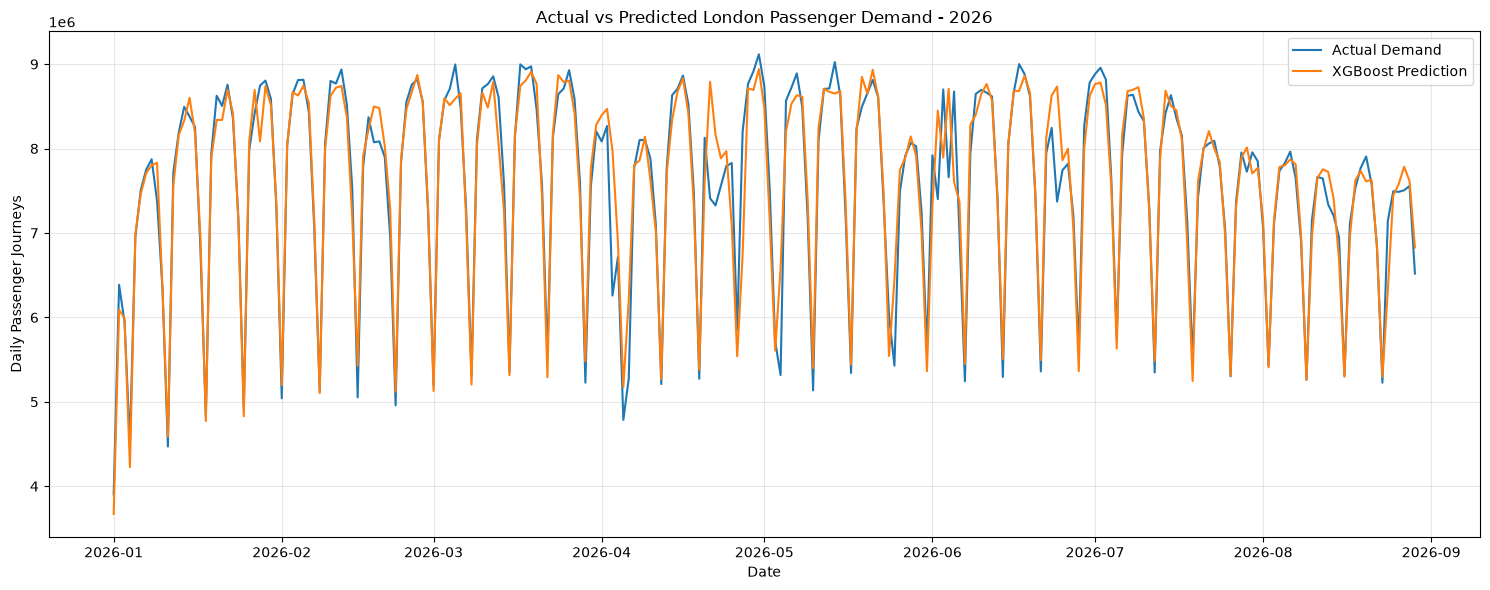

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))

plt.plot(
    test["TravelDate"],
    y_test,
    label="Actual Demand",
    linewidth=1.5
)

plt.plot(
    test["TravelDate"],
    xgb_pred,
    label="XGBoost Prediction",
    linewidth=1.5
)

plt.title("Actual vs Predicted London Passenger Demand - 2026")
plt.xlabel("Date")
plt.ylabel("Daily Passenger Journeys")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

,Feature,Importance
7,Lag_7,0.626585
8,Lag_14,0.086394
10,RollingMean_7,0.078795
5,IsWeekend,0.056849
6,Lag_1,0.041717
9,Lag_28,0.023557
2,WeekOfYear,0.023454
0,DayOfWeekNum,0.019948
1,DayOfYear,0.014073
3,Month,0.011281


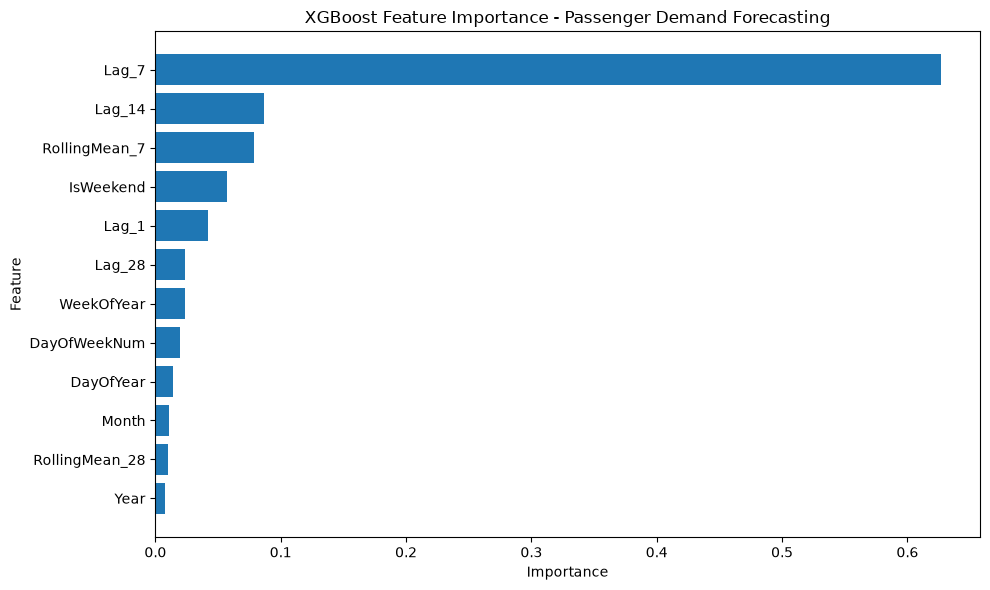

In [20]:
# XGBoost feature importance

feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": xgb_model.feature_importances_
}).sort_values("Importance", ascending=False)

display(feature_importance)

plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.gca().invert_yaxis()
plt.title("XGBoost Feature Importance - Passenger Demand Forecasting")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()

plt.show()

In [21]:
# Analyse XGBoost prediction errors

prediction_results = test[
    ["TravelDate", "DayOfWeek", "TotalJourneyCount"]
].copy()

prediction_results["PredictedDemand"] = xgb_pred

prediction_results["Error"] = (
    prediction_results["TotalJourneyCount"]
    - prediction_results["PredictedDemand"]
)

prediction_results["AbsoluteError"] = abs(
    prediction_results["Error"]
)

prediction_results["PercentageError"] = (
    prediction_results["AbsoluteError"]
    / prediction_results["TotalJourneyCount"]
) * 100

# Largest prediction errors
largest_errors = prediction_results.sort_values(
    "AbsoluteError",
    ascending=False
).head(15)

display(
    largest_errors.style.format({
        "TotalJourneyCount": "{:,.0f}",
        "PredictedDemand": "{:,.0f}",
        "Error": "{:,.0f}",
        "AbsoluteError": "{:,.0f}",
        "PercentageError": "{:.2f}%"
    })
)

,TravelDate,DayOfWeek,TotalJourneyCount,PredictedDemand,Error,AbsoluteError,PercentageError
2621,2026-04-03 00:00:00,Friday,"6,259,000","7,973,405","-1,714,405","1,714,405",27.39%
2645,2026-04-27 00:00:00,Monday,"8,200,000","6,734,776","1,465,224","1,465,224",17.87%
2639,2026-04-21 00:00:00,Tuesday,"7,411,000","8,789,368","-1,378,368","1,378,368",18.60%
2703,2026-06-24 00:00:00,Wednesday,"7,372,000","8,734,413","-1,362,413","1,362,413",18.48%
2652,2026-05-04 00:00:00,Monday,"5,317,000","6,580,444","-1,263,444","1,263,444",23.76%
2684,2026-06-05 00:00:00,Friday,"8,675,000","7,606,723","1,068,277","1,068,277",12.31%
2683,2026-06-04 00:00:00,Thursday,"7,660,000","8,708,183","-1,048,183","1,048,183",13.68%
2681,2026-06-02 00:00:00,Tuesday,"7,401,000","8,448,326","-1,047,326","1,047,326",14.15%
2673,2026-05-25 00:00:00,Monday,"5,428,000","6,444,888","-1,016,888","1,016,888",18.73%
2624,2026-04-06 00:00:00,Monday,"5,275,000","6,212,960","-937,960","937,960",17.78%


In [22]:
import joblib
import os

model_dir = r"C:\Users\User\Documents\UEL\Project\London Public Transport Intelligence Platform\models"

os.makedirs(model_dir, exist_ok=True)

model_path = os.path.join(
    model_dir,
    "xgboost_network_demand_model.pkl"
)

joblib.dump(xgb_model, model_path)

print("Model saved successfully:")
print(model_path)

Model saved successfully:
C:\Users\User\Documents\UEL\Project\London Public Transport Intelligence Platform\models\xgboost_network_demand_model.pkl


In [23]:
import pandas as pd

entries_path = r"C:\Users\User\Documents\UEL\Project\London Public Transport Intelligence Platform\data\processed\numbat_station_entries_long.csv"

exits_path = r"C:\Users\User\Documents\UEL\Project\London Public Transport Intelligence Platform\data\processed\numbat_station_exits_long.csv"

entries = pd.read_csv(entries_path)
exits = pd.read_csv(exits_path)

print("Entries shape:", entries.shape)
print("Exits shape:", exits.shape)

print("\nEntries columns:")
print(entries.columns.tolist())

print("\nExits columns:")
print(exits.columns.tolist())

print("\nEntry sample:")
display(entries.head())

print("\nExit sample:")
display(exits.head())

Entries shape: (226080, 14)
Exits shape: (226080, 14)

Entries columns:
['NLC', 'ASC', 'Station', 'Fare Zone', 'Total', 'Early', 'AM Peak', 'Midday', 'PM Peak', 'Evening', 'Late', 'DayType', 'TimeInterval', 'EntryCount']

Exits columns:
['NLC', 'ASC', 'Station', 'Fare Zone', 'Total', 'Early', 'AM Peak', 'Midday', 'PM Peak', 'Evening', 'Late', 'DayType', 'TimeInterval', 'ExitCount']

Entry sample:


,NLC,ASC,Station,Fare Zone,Total,Early,AM Peak,Midday,PM Peak,Evening,Late,DayType,TimeInterval,EntryCount
0,750,ABRd,Abbey Road,2/3,2250.868790,206.794439,624.727479,723.628359,447.237084,187.455976,61.025452,Monday,0500-0515,3.815536
1,1404,ACCr,Acton Central,3,2557.971981,171.623341,867.835881,705.534070,592.914086,181.666236,38.398367,Monday,0500-0515,0.000000
2,3000,AMLr,Acton Main Line,3,5662.632454,460.624272,2127.596387,1450.753692,1228.461131,297.277119,97.919854,Monday,0500-0515,15.649660
3,500,ACTu,Acton Town,3,7164.369828,425.453114,2353.045905,2219.381504,1567.447040,463.488024,135.554239,Monday,0500-0515,10.382484
4,9441,ADVt,Addington Village,4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,Monday,0500-0515,0.000000



Exit sample:


,NLC,ASC,Station,Fare Zone,Total,Early,AM Peak,Midday,PM Peak,Evening,Late,DayType,TimeInterval,ExitCount
0,750,ABRd,Abbey Road,2/3,2290.703083,121.450125,427.567665,589.187660,672.709404,331.597128,148.191101,Monday,0500-0515,0.313043
1,1404,ACCr,Acton Central,3,2527.613797,37.836013,585.171333,514.684753,872.200744,387.389315,130.331641,Monday,0500-0515,0.000000
2,3000,AMLr,Acton Main Line,3,5339.021414,156.921168,989.558267,894.500642,1826.822309,1004.018915,467.200113,Monday,0500-0515,2.208039
3,500,ACTu,Acton Town,3,7287.832822,280.355645,1589.107862,1522.579341,2152.679866,1208.072870,535.037238,Monday,0500-0515,1.320497
4,9441,ADVt,Addington Village,4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,Monday,0500-0515,0.000000


In [24]:
# Merge NUMBAT entries and exits

merge_keys = [
    "NLC",
    "ASC",
    "Station",
    "Fare Zone",
    "DayType",
    "TimeInterval"
]

station_demand = entries[
    merge_keys + ["EntryCount"]
].merge(
    exits[merge_keys + ["ExitCount"]],
    on=merge_keys,
    how="inner"
)

# Total passenger activity
station_demand["TotalPassengerActivity"] = (
    station_demand["EntryCount"] +
    station_demand["ExitCount"]
)

print("Merged shape:", station_demand.shape)

print("\nMissing values:")
print(
    station_demand[
        ["EntryCount", "ExitCount", "TotalPassengerActivity"]
    ].isnull().sum()
)

print("\nUnique stations:", station_demand["Station"].nunique())
print("Day types:", station_demand["DayType"].unique())
print("Time intervals:", station_demand["TimeInterval"].nunique())

print("\nSample:")
display(station_demand.head())

Merged shape: (226080, 9)

Missing values:
EntryCount                0
ExitCount                 0
TotalPassengerActivity    0
dtype: int64

Unique stations: 471
Day types: <StringArray>
['Monday', 'TWT', 'Friday', 'Saturday', 'Sunday']
Length: 5, dtype: str
Time intervals: 96

Sample:


,NLC,ASC,Station,Fare Zone,DayType,TimeInterval,EntryCount,ExitCount,TotalPassengerActivity
0,750,ABRd,Abbey Road,2/3,Monday,0500-0515,3.815536,0.313043,4.128579
1,1404,ACCr,Acton Central,3,Monday,0500-0515,0.000000,0.000000,0.000000
2,3000,AMLr,Acton Main Line,3,Monday,0500-0515,15.649660,2.208039,17.857699
3,500,ACTu,Acton Town,3,Monday,0500-0515,10.382484,1.320497,11.702980
4,9441,ADVt,Addington Village,4,Monday,0500-0515,0.000000,0.000000,0.000000


In [25]:
# Create time features from 15-minute intervals

# Extract start time, e.g. "0500-0515" -> "0500"
station_demand["StartTime"] = (
    station_demand["TimeInterval"]
    .str.split("-")
    .str[0]
)

# Convert to hour and minute
station_demand["Hour"] = (
    station_demand["StartTime"]
    .str[:2]
    .astype(int)
)

station_demand["Minute"] = (
    station_demand["StartTime"]
    .str[2:4]
    .astype(int)
)

# Convert each interval to an ordered 15-minute slot
station_demand["TimeSlot"] = (
    station_demand["Hour"] * 4
    + station_demand["Minute"] // 15
)

print("Hour range:",
      station_demand["Hour"].min(),
      "to",
      station_demand["Hour"].max())

print("Unique time slots:",
      station_demand["TimeSlot"].nunique())

print("\nSample:")
display(
    station_demand[
        [
            "Station",
            "DayType",
            "TimeInterval",
            "Hour",
            "Minute",
            "TimeSlot",
            "TotalPassengerActivity"
        ]
    ].head(10)
)

Hour range: 0 to 23
Unique time slots: 96

Sample:


,Station,DayType,TimeInterval,Hour,Minute,TimeSlot,TotalPassengerActivity
0,Abbey Road,Monday,0500-0515,5,0,20,4.128579
1,Acton Central,Monday,0500-0515,5,0,20,0.000000
2,Acton Main Line,Monday,0500-0515,5,0,20,17.857699
3,Acton Town,Monday,0500-0515,5,0,20,11.702980
4,Addington Village,Monday,0500-0515,5,0,20,0.000000
5,Addiscombe,Monday,0500-0515,5,0,20,0.000000
6,Aldgate,Monday,0500-0515,5,0,20,6.311092
7,Aldgate East,Monday,0500-0515,5,0,20,8.638675
8,All Saints,Monday,0500-0515,5,0,20,2.686775
9,Alperton,Monday,0500-0515,5,0,20,16.177167


In [26]:
# Encode station and day type

from sklearn.preprocessing import LabelEncoder

station_encoder = LabelEncoder()
daytype_encoder = LabelEncoder()

station_demand["StationCode"] = station_encoder.fit_transform(
    station_demand["Station"]
)

station_demand["DayTypeCode"] = daytype_encoder.fit_transform(
    station_demand["DayType"]
)

print("Number of encoded stations:",
      station_demand["StationCode"].nunique())

print("\nDay Type Encoding:")
for day, code in zip(
    daytype_encoder.classes_,
    daytype_encoder.transform(daytype_encoder.classes_)
):
    print(f"{day}: {code}")

display(
    station_demand[
        [
            "Station",
            "StationCode",
            "DayType",
            "DayTypeCode",
            "TimeInterval",
            "TimeSlot",
            "TotalPassengerActivity"
        ]
    ].head()
)

Number of encoded stations: 471

Day Type Encoding:
Friday: 0
Monday: 1
Saturday: 2
Sunday: 3
TWT: 4


,Station,StationCode,DayType,DayTypeCode,TimeInterval,TimeSlot,TotalPassengerActivity
0,Abbey Road,0,Monday,1,0500-0515,20,4.128579
1,Acton Central,2,Monday,1,0500-0515,20,0.000000
2,Acton Main Line,3,Monday,1,0500-0515,20,17.857699
3,Acton Town,4,Monday,1,0500-0515,20,11.702980
4,Addington Village,5,Monday,1,0500-0515,20,0.000000


In [27]:
# Split by day type
# Train on Monday, Friday, Saturday and Sunday
# Test on TWT (Tuesday/Wednesday/Thursday)

train_station = station_demand[
    station_demand["DayType"] != "TWT"
].copy()

test_station = station_demand[
    station_demand["DayType"] == "TWT"
].copy()

print("Training rows:", len(train_station))
print("Testing rows:", len(test_station))

print("\nTraining day types:")
print(train_station["DayType"].value_counts())

print("\nTesting day types:")
print(test_station["DayType"].value_counts())

print("\nTraining stations:",
      train_station["Station"].nunique())

print("Testing stations:",
      test_station["Station"].nunique())

print("\nTesting intervals:",
      test_station["TimeInterval"].nunique())

Training rows: 180864
Testing rows: 45216

Training day types:
DayType
Monday      45216
Friday      45216
Saturday    45216
Sunday      45216
Name: count, dtype: int64

Testing day types:
DayType
TWT    45216
Name: count, dtype: int64

Training stations: 471
Testing stations: 471

Testing intervals: 96


In [28]:
# Baseline: use Monday demand to predict TWT demand
monday_baseline = station_demand[
    station_demand["DayType"] == "Monday"
][
    ["Station", "TimeInterval", "TotalPassengerActivity"]
].copy()

monday_baseline = monday_baseline.rename(
    columns={"TotalPassengerActivity": "BaselinePrediction"}
)

twt_actual = station_demand[
    station_demand["DayType"] == "TWT"
][
    ["Station", "TimeInterval", "TotalPassengerActivity"]
].copy()

baseline_station = twt_actual.merge(
    monday_baseline,
    on=["Station", "TimeInterval"],
    how="left"
)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

station_baseline_mae = mean_absolute_error(
    baseline_station["TotalPassengerActivity"],
    baseline_station["BaselinePrediction"]
)

station_baseline_rmse = np.sqrt(
    mean_squared_error(
        baseline_station["TotalPassengerActivity"],
        baseline_station["BaselinePrediction"]
    )
)

station_baseline_r2 = r2_score(
    baseline_station["TotalPassengerActivity"],
    baseline_station["BaselinePrediction"]
)

print("Station-Time Monday Baseline")
print("----------------------------")
print(f"MAE : {station_baseline_mae:,.2f}")
print(f"RMSE: {station_baseline_rmse:,.2f}")
print(f"R²  : {station_baseline_r2:.4f}")

Station-Time Monday Baseline
----------------------------
MAE : 33.33
RMSE: 106.00
R²  : 0.9568


In [29]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Features
station_features = [
    "StationCode",
    "TimeSlot",
    "Hour",
    "Minute"
]

X_train_station = train_station[station_features]
y_train_station = train_station["TotalPassengerActivity"]

X_test_station = test_station[station_features]
y_test_station = test_station["TotalPassengerActivity"]

# XGBoost
station_xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

station_xgb.fit(X_train_station, y_train_station)

station_xgb_pred = station_xgb.predict(X_test_station)

# Evaluation
station_xgb_mae = mean_absolute_error(
    y_test_station,
    station_xgb_pred
)

station_xgb_rmse = np.sqrt(
    mean_squared_error(
        y_test_station,
        station_xgb_pred
    )
)

station_xgb_r2 = r2_score(
    y_test_station,
    station_xgb_pred
)

print("Station-Time XGBoost Performance")
print("--------------------------------")
print(f"MAE : {station_xgb_mae:,.2f}")
print(f"RMSE: {station_xgb_rmse:,.2f}")
print(f"R²  : {station_xgb_r2:.4f}")

print("\nMonday Baseline R² :", round(station_baseline_r2, 4))
print("XGBoost R²         :", round(station_xgb_r2, 4))

Station-Time XGBoost Performance
--------------------------------
MAE : 141.20
RMSE: 364.81
R²  : 0.4888

Monday Baseline R² : 0.9568
XGBoost R²         : 0.4888


In [30]:
# Create Monday demand reference feature

monday_reference = station_demand[
    station_demand["DayType"] == "Monday"
][
    ["Station", "TimeInterval", "TotalPassengerActivity"]
].copy()

monday_reference = monday_reference.rename(
    columns={
        "TotalPassengerActivity": "MondayDemand"
    }
)

# Add Monday reference demand to training data
train_station_v2 = train_station.merge(
    monday_reference,
    on=["Station", "TimeInterval"],
    how="left"
)

# Add Monday reference demand to TWT test data
test_station_v2 = test_station.merge(
    monday_reference,
    on=["Station", "TimeInterval"],
    how="left"
)

print("Training shape:", train_station_v2.shape)
print("Testing shape:", test_station_v2.shape)

print("\nMissing MondayDemand:")
print("Train:", train_station_v2["MondayDemand"].isna().sum())
print("Test :", test_station_v2["MondayDemand"].isna().sum())

print("\nMondayDemand summary:")
print(train_station_v2["MondayDemand"].describe())

display(
    test_station_v2[
        [
            "Station",
            "DayType",
            "TimeInterval",
            "MondayDemand",
            "TotalPassengerActivity"
        ]
    ].head(10)
)

Training shape: (180864, 16)
Testing shape: (45216, 16)

Missing MondayDemand:
Train: 0
Test : 0

MondayDemand summary:
count    180864.000000
mean        197.454432
std         426.124824
min           0.000000
25%           4.949592
50%          73.888713
75%         201.484264
max        6728.389800
Name: MondayDemand, dtype: float64


,Station,DayType,TimeInterval,MondayDemand,TotalPassengerActivity
0,Abbey Road,TWT,0500-0515,4.128579,4.123655
1,Acton Central,TWT,0500-0515,0.000000,0.000000
2,Acton Main Line,TWT,0500-0515,17.857699,17.155371
3,Acton Town,TWT,0500-0515,11.702980,12.259585
4,Addington Village,TWT,0500-0515,0.000000,0.000000
5,Addiscombe,TWT,0500-0515,0.000000,0.000000
6,Aldgate,TWT,0500-0515,6.311092,6.300594
7,Aldgate East,TWT,0500-0515,8.638675,7.137497
8,All Saints,TWT,0500-0515,2.686775,2.246435
9,Alperton,TWT,0500-0515,16.177167,19.169869


In [31]:
# XGBoost V2 - Include Monday demand reference

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

features_v2 = [
    "StationCode",
    "TimeSlot",
    "Hour",
    "Minute",
    "DayTypeCode",
    "MondayDemand"
]

X_train_v2 = train_station_v2[features_v2]
y_train_v2 = train_station_v2["TotalPassengerActivity"]

X_test_v2 = test_station_v2[features_v2]
y_test_v2 = test_station_v2["TotalPassengerActivity"]

station_xgb_v2 = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

station_xgb_v2.fit(X_train_v2, y_train_v2)

station_xgb_v2_pred = station_xgb_v2.predict(X_test_v2)

# Metrics
xgb_v2_mae = mean_absolute_error(
    y_test_v2,
    station_xgb_v2_pred
)

xgb_v2_rmse = np.sqrt(
    mean_squared_error(
        y_test_v2,
        station_xgb_v2_pred
    )
)

xgb_v2_r2 = r2_score(
    y_test_v2,
    station_xgb_v2_pred
)

print("Station-Time XGBoost V2")
print("-----------------------")
print(f"MAE : {xgb_v2_mae:,.2f}")
print(f"RMSE: {xgb_v2_rmse:,.2f}")
print(f"R²  : {xgb_v2_r2:.4f}")

print("\nComparison")
print("-----------------------")
print(f"Monday Baseline R² : {station_baseline_r2:.4f}")
print(f"XGBoost V1 R²      : {station_xgb_r2:.4f}")
print(f"XGBoost V2 R²      : {xgb_v2_r2:.4f}")

Station-Time XGBoost V2
-----------------------
MAE : 111.74
RMSE: 336.03
R²  : 0.5663

Comparison
-----------------------
Monday Baseline R² : 0.9568
XGBoost V1 R²      : 0.4888
XGBoost V2 R²      : 0.5663


In [32]:
# Compare demand patterns between NUMBAT day types

daytype_matrix = station_demand.pivot_table(
    index=["Station", "TimeInterval"],
    columns="DayType",
    values="TotalPassengerActivity"
)

print("Day-type demand correlations:")
display(
    daytype_matrix.corr().round(4)
)

print("\nMean passenger activity by day type:")
display(
    station_demand.groupby("DayType")[
        "TotalPassengerActivity"
    ]
    .agg(["mean", "median", "std", "max"])
    .round(2)
)

Day-type demand correlations:


DayType,Friday,Monday,Saturday,Sunday,TWT
DayType,,,,,
Friday,1.0000,0.9654,0.9279,0.9014,0.9625
Monday,0.9654,1.0000,0.8267,0.8164,0.9928
Saturday,0.9279,0.8267,1.0000,0.9723,0.8217
Sunday,0.9014,0.8164,0.9723,1.0000,0.8010
TWT,0.9625,0.9928,0.8217,0.8010,1.0000



Mean passenger activity by day type:


,mean,median,std,max
DayType,,,,
Friday,211.01,88.83,419.29,5711.81
Monday,197.45,73.89,426.13,6728.39
Saturday,192.45,73.67,425.56,5846.84
Sunday,130.73,43.97,300.77,4031.70
TWT,229.33,84.45,510.27,8632.76


In [33]:
# Build station-level expected demand profile

expected_demand_profile = station_demand[
    [
        "NLC",
        "ASC",
        "Station",
        "Fare Zone",
        "DayType",
        "TimeInterval",
        "Hour",
        "Minute",
        "TimeSlot",
        "EntryCount",
        "ExitCount",
        "TotalPassengerActivity"
    ]
].copy()

expected_demand_profile = expected_demand_profile.rename(
    columns={
        "EntryCount": "ExpectedEntryCount",
        "ExitCount": "ExpectedExitCount",
        "TotalPassengerActivity": "ExpectedPassengerActivity"
    }
)

# Sort logically
day_order = {
    "Monday": 0,
    "TWT": 1,
    "Friday": 2,
    "Saturday": 3,
    "Sunday": 4
}

expected_demand_profile["DayOrder"] = (
    expected_demand_profile["DayType"].map(day_order)
)

expected_demand_profile = (
    expected_demand_profile
    .sort_values(
        ["Station", "DayOrder", "TimeSlot"]
    )
    .reset_index(drop=True)
)

print("Expected demand profile shape:",
      expected_demand_profile.shape)

print("Unique stations:",
      expected_demand_profile["Station"].nunique())

print("Day types:",
      expected_demand_profile["DayType"].unique())

print("Intervals:",
      expected_demand_profile["TimeInterval"].nunique())

print("\nMissing expected demand:",
      expected_demand_profile[
          "ExpectedPassengerActivity"
      ].isna().sum())

display(expected_demand_profile.head(10))

Expected demand profile shape: (226080, 13)
Unique stations: 471
Day types: <StringArray>
['Monday', 'TWT', 'Friday', 'Saturday', 'Sunday']
Length: 5, dtype: str
Intervals: 96

Missing expected demand: 0


,NLC,ASC,Station,Fare Zone,DayType,TimeInterval,Hour,Minute,TimeSlot,ExpectedEntryCount,ExpectedExitCount,ExpectedPassengerActivity,DayOrder
0,750,ABRd,Abbey Road,2/3,Monday,0000-0015,0,0,0,2.715818,7.410010,10.125828,0
1,750,ABRd,Abbey Road,2/3,Monday,0015-0030,0,15,1,3.405386,5.636558,9.041944,0
2,750,ABRd,Abbey Road,2/3,Monday,0030-0045,0,30,2,3.068888,3.085949,6.154837,0
3,750,ABRd,Abbey Road,2/3,Monday,0045-0100,0,45,3,2.402185,2.169242,4.571427,0
4,750,ABRd,Abbey Road,2/3,Monday,0100-0115,1,0,4,1.777012,1.182197,2.959209,0
5,750,ABRd,Abbey Road,2/3,Monday,0115-0130,1,15,5,1.477284,0.503408,1.980692,0
6,750,ABRd,Abbey Road,2/3,Monday,0130-0145,1,30,6,0.000000,0.000000,0.000000,0
7,750,ABRd,Abbey Road,2/3,Monday,0145-0200,1,45,7,0.000000,0.000000,0.000000,0
8,750,ABRd,Abbey Road,2/3,Monday,0200-0215,2,0,8,0.000000,0.000000,0.000000,0
9,750,ABRd,Abbey Road,2/3,Monday,0215-0230,2,15,9,0.000000,0.000000,0.000000,0


In [34]:
# Save expected station demand profile

from pathlib import Path

processed_path = Path(
    r"C:\Users\User\Documents\UEL\Project\London Public Transport Intelligence Platform\data\processed"
)

output_file = processed_path / "station_expected_demand_profile_2025.csv"

expected_demand_profile.to_csv(
    output_file,
    index=False
)

print("Saved successfully:")
print(output_file)

print("\nRows saved:", len(expected_demand_profile))
print("Columns saved:", len(expected_demand_profile.columns))

Saved successfully:
C:\Users\User\Documents\UEL\Project\London Public Transport Intelligence Platform\data\processed\station_expected_demand_profile_2025.csv

Rows saved: 226080
Columns saved: 13


In [2]:
import pandas as pd
from pathlib import Path

processed_path = Path(
    r"C:\Users\User\Documents\UEL\Project\London Public Transport Intelligence Platform\data\processed"
)

profile_file = processed_path / "station_expected_demand_profile_2025.csv"

expected_demand_profile = pd.read_csv(profile_file)

print("Loaded successfully")
print("Shape:", expected_demand_profile.shape)
print("Columns:")
print(expected_demand_profile.columns.tolist())

display(expected_demand_profile.head())

Loaded successfully
Shape: (226080, 13)
Columns:
['NLC', 'ASC', 'Station', 'Fare Zone', 'DayType', 'TimeInterval', 'Hour', 'Minute', 'TimeSlot', 'ExpectedEntryCount', 'ExpectedExitCount', 'ExpectedPassengerActivity', 'DayOrder']


,NLC,ASC,Station,Fare Zone,DayType,TimeInterval,Hour,Minute,TimeSlot,ExpectedEntryCount,ExpectedExitCount,ExpectedPassengerActivity,DayOrder
0,750,ABRd,Abbey Road,2/3,Monday,0000-0015,0,0,0,2.715818,7.410010,10.125828,0
1,750,ABRd,Abbey Road,2/3,Monday,0015-0030,0,15,1,3.405386,5.636558,9.041944,0
2,750,ABRd,Abbey Road,2/3,Monday,0030-0045,0,30,2,3.068888,3.085949,6.154837,0
3,750,ABRd,Abbey Road,2/3,Monday,0045-0100,0,45,3,2.402185,2.169242,4.571427,0
4,750,ABRd,Abbey Road,2/3,Monday,0100-0115,1,0,4,1.777012,1.182197,2.959209,0


In [3]:
# Create anomaly-detection features

anomaly_df = expected_demand_profile.copy()

# Typical network demand for each day type and 15-minute interval
network_time_stats = (
    anomaly_df
    .groupby(["DayType", "TimeInterval"])["ExpectedPassengerActivity"]
    .agg(["mean", "median", "std"])
    .reset_index()
    .rename(
        columns={
            "mean": "NetworkMeanDemand",
            "median": "NetworkMedianDemand",
            "std": "NetworkStdDemand"
        }
    )
)

anomaly_df = anomaly_df.merge(
    network_time_stats,
    on=["DayType", "TimeInterval"],
    how="left"
)

# Difference from network average
anomaly_df["DemandDifference"] = (
    anomaly_df["ExpectedPassengerActivity"]
    - anomaly_df["NetworkMeanDemand"]
)

# Standardised difference
anomaly_df["DemandZScore"] = (
    anomaly_df["DemandDifference"]
    / anomaly_df["NetworkStdDemand"].replace(0, 1)
)

print("Shape:", anomaly_df.shape)

print("\nMissing values:")
print(
    anomaly_df[
        [
            "NetworkMeanDemand",
            "NetworkMedianDemand",
            "NetworkStdDemand",
            "DemandDifference",
            "DemandZScore"
        ]
    ].isnull().sum()
)

print("\nZ-score summary:")
print(anomaly_df["DemandZScore"].describe())

Shape: (226080, 18)

Missing values:
NetworkMeanDemand      0
NetworkMedianDemand    0
NetworkStdDemand       0
DemandDifference       0
DemandZScore           0
dtype: int64

Z-score summary:
count    2.260800e+05
mean    -8.045778e-18
std      9.989401e-01
min     -7.882239e-01
25%     -4.397155e-01
50%     -2.650687e-01
75%     -3.631412e-02
max      2.153825e+01
Name: DemandZScore, dtype: float64


In [4]:
# Save anomaly reference features

output_file = processed_path / "station_anomaly_reference_2025.csv"

anomaly_df.to_csv(
    output_file,
    index=False
)

print("Saved successfully:")
print(output_file)

print("\nRows:", len(anomaly_df))
print("Columns:", len(anomaly_df.columns))

Saved successfully:
C:\Users\User\Documents\UEL\Project\London Public Transport Intelligence Platform\data\processed\station_anomaly_reference_2025.csv

Rows: 226080
Columns: 18


In [5]:
import requests
import pandas as pd

url = "https://api.tfl.gov.uk/Line/Mode/tube,overground,elizabeth-line,dlr/Status"

response = requests.get(url, timeout=30)

print("Status code:", response.status_code)

data = response.json()

records = []

for line in data:
    line_name = line.get("name")

    for status in line.get("lineStatuses", []):
        records.append({
            "Line": line_name,
            "StatusSeverity": status.get("statusSeverity"),
            "StatusDescription": status.get("statusSeverityDescription"),
            "Reason": status.get("reason")
        })

line_status_df = pd.DataFrame(records)

print("Rows:", len(line_status_df))

display(line_status_df)

Status code: 200
Rows: 21


,Line,StatusSeverity,StatusDescription,Reason
0,Bakerloo,10,Good Service,NaN
1,Central,10,Good Service,NaN
2,Circle,10,Good Service,NaN
3,District,10,Good Service,NaN
4,DLR,10,Good Service,NaN
5,Elizabeth line,9,Minor Delays,Minor delays between Paddington and Heathrow T...
6,Hammersmith & City,10,Good Service,NaN
7,Jubilee,10,Good Service,NaN
8,Liberty,10,Good Service,NaN
9,Lioness,10,Good Service,NaN


In [6]:
from datetime import datetime

# Create a clean live line-status snapshot

live_line_status = line_status_df.copy()

# Replace missing reasons with a readable value
live_line_status["Reason"] = (
    live_line_status["Reason"]
    .fillna("No disruption reported")
)

# Add collection timestamp
live_line_status["CapturedAt"] = datetime.now()

# Create simple disruption flag
live_line_status["IsDisrupted"] = (
    live_line_status["StatusDescription"] != "Good Service"
).astype(int)

print("Snapshot time:")
print(live_line_status["CapturedAt"].iloc[0])

print("\nTotal status records:", len(live_line_status))
print("Disrupted records:", live_line_status["IsDisrupted"].sum())

print("\nCurrent disrupted services:")
display(
    live_line_status[
        live_line_status["IsDisrupted"] == 1
    ][
        [
            "Line",
            "StatusDescription",
            "Reason",
            "CapturedAt"
        ]
    ]
)

Snapshot time:
2026-09-11 10:42:14.119402

Total status records: 21
Disrupted records: 6

Current disrupted services:


,Line,StatusDescription,Reason,CapturedAt
5,Elizabeth line,Minor Delays,Minor delays between Paddington and Heathrow T...,2026-09-11 10:42:14.119402
10,Metropolitan,Severe Delays,Metropolitan Line: No service between Baker St...,2026-09-11 10:42:14.119402
11,Metropolitan,Minor Delays,Metropolitan Line: No service between Baker St...,2026-09-11 10:42:14.119402
12,Metropolitan,Part Suspended,Metropolitan Line: No service between Baker St...,2026-09-11 10:42:14.119402
15,Piccadilly,Severe Delays,Piccadilly Line: Severe delays due to an earli...,2026-09-11 10:42:14.119402
17,Victoria,Minor Delays,Victoria Line: Minor delays due to train cance...,2026-09-11 10:42:14.119402


In [7]:
# Save live line-status snapshot to CSV history

from pathlib import Path
import pandas as pd

live_data_path = Path(
    r"C:\Users\User\Documents\UEL\Project\London Public Transport Intelligence Platform\data\processed"
)

history_file = live_data_path / "live_line_status_history.csv"

if history_file.exists():
    existing_history = pd.read_csv(history_file)

    updated_history = pd.concat(
        [existing_history, live_line_status],
        ignore_index=True
    )
else:
    updated_history = live_line_status.copy()

updated_history.to_csv(
    history_file,
    index=False
)

print("Saved live status history:")
print(history_file)

print("\nTotal rows in history:", len(updated_history))
print("Latest snapshot rows:", len(live_line_status))

Saved live status history:
C:\Users\User\Documents\UEL\Project\London Public Transport Intelligence Platform\data\processed\live_line_status_history.csv

Total rows in history: 21
Latest snapshot rows: 21


In [8]:
# Live TfL arrivals - Stratford

import requests
import pandas as pd
from datetime import datetime

stop_id = "910GSTFD"

url = f"https://api.tfl.gov.uk/StopPoint/{stop_id}/Arrivals"

response = requests.get(url, timeout=30)

print("Status code:", response.status_code)

arrivals_data = response.json()

arrival_records = []

for item in arrivals_data:
    arrival_records.append({
        "StopID": stop_id,
        "StopName": item.get("stationName"),
        "Line": item.get("lineName"),
        "Mode": item.get("modeName"),
        "Destination": item.get("destinationName"),
        "Direction": item.get("direction"),
        "Platform": item.get("platformName"),
        "VehicleID": item.get("vehicleId"),
        "TimeToStationSeconds": item.get("timeToStation"),
        "ExpectedArrival": item.get("expectedArrival"),
        "CurrentLocation": item.get("currentLocation"),
        "CapturedAt": datetime.now()
    })

arrivals_df = pd.DataFrame(arrival_records)

print("Arrival records:", len(arrivals_df))

if not arrivals_df.empty:
    arrivals_df["MinutesToArrival"] = (
        arrivals_df["TimeToStationSeconds"] / 60
    ).round(1)

    arrivals_df = arrivals_df.sort_values(
        "TimeToStationSeconds"
    )

    display(
        arrivals_df[
            [
                "StopName",
                "Line",
                "Mode",
                "Destination",
                "Platform",
                "MinutesToArrival",
                "VehicleID"
            ]
        ].head(20)
    )
else:
    print("No live arrivals returned.")

Status code: 200
Arrival records: 48


,StopName,Line,Mode,Destination,Platform,MinutesToArrival,VehicleID
4,Stratford (London) Rail Station,Elizabeth line,elizabeth-line,Shenfield Rail Station,Platform 8,1.2,202609116737849
40,Stratford (London) Rail Station,Mildmay,overground,Stratford (London) Rail Station,Platform 1,1.2,202609117158839
20,Stratford (London) Rail Station,Elizabeth line,elizabeth-line,Paddington,Platform 5,5.2,202609116738422
33,Stratford (London) Rail Station,Mildmay,overground,Stratford (London) Rail Station,Platform 2,6.2,202609117107216
5,Stratford (London) Rail Station,Elizabeth line,elizabeth-line,Shenfield Rail Station,Platform 8,8.2,202609116737859
21,Stratford (London) Rail Station,Elizabeth line,elizabeth-line,Paddington,Platform 5,13.2,202609116738427
41,Stratford (London) Rail Station,Mildmay,overground,Stratford (London) Rail Station,Platform 1,15.2,202609117158844
6,Stratford (London) Rail Station,Elizabeth line,elizabeth-line,Shenfield Rail Station,Platform 8,16.2,202609116737867
34,Stratford (London) Rail Station,Mildmay,overground,Stratford (London) Rail Station,Platform 2,19.2,202609117107221
22,Stratford (London) Rail Station,Elizabeth line,elizabeth-line,Paddington,Platform 5,20.2,202609116738436


In [9]:
# Test live bus arrivals

import requests
import pandas as pd
from datetime import datetime

bus_stop_id = "490004889E"

url = f"https://api.tfl.gov.uk/StopPoint/{bus_stop_id}/Arrivals"

response = requests.get(url, timeout=30)

print("Status code:", response.status_code)

response.raise_for_status()

bus_data = response.json()

print("Live bus predictions:", len(bus_data))

bus_records = []

for x in bus_data:
    bus_records.append({
        "collected_at": datetime.now(),
        "stop_id": x.get("naptanId"),
        "stop_name": x.get("stationName"),
        "route": x.get("lineName"),
        "vehicle_id": x.get("vehicleId"),
        "destination": x.get("destinationName"),
        "direction": x.get("direction"),
        "time_to_stop_seconds": x.get("timeToStation"),
        "expected_arrival": x.get("expectedArrival"),
        "current_location": x.get("currentLocation"),
        "towards": x.get("towards")
    })

bus_arrivals = pd.DataFrame(bus_records)

if not bus_arrivals.empty:
    bus_arrivals["minutes_to_arrival"] = (
        bus_arrivals["time_to_stop_seconds"] / 60
    ).round(1)

    bus_arrivals = bus_arrivals.sort_values(
        "time_to_stop_seconds"
    )

    display(
        bus_arrivals[
            [
                "stop_name",
                "route",
                "destination",
                "minutes_to_arrival",
                "vehicle_id",
                "current_location"
            ]
        ]
    )
else:
    print("No live bus arrivals currently returned.")

Status code: 200
Live bus predictions: 6


,stop_name,route,destination,minutes_to_arrival,vehicle_id,current_location
0,Abbeville Road,355,Brixton,0.5,LV25CSF,
4,Abbeville Road,50,"Croydon, Town Centre",2.7,LV23ZCY,
1,Abbeville Road,355,Brixton,12.5,LV25CSU,
3,Abbeville Road,50,"Croydon, Town Centre",13.2,LV23ZCE,
2,Abbeville Road,355,Brixton,25.4,LV25CVS,
5,Abbeville Road,50,"Croydon, Town Centre",25.4,LY24FWV,


In [10]:
def get_bus_arrivals(stop_id):
    """
    Get live TfL bus arrivals for a bus stop.
    """

    import requests
    import pandas as pd
    from datetime import datetime

    url = f"https://api.tfl.gov.uk/StopPoint/{stop_id}/Arrivals"

    response = requests.get(url, timeout=30)
    response.raise_for_status()

    data = response.json()

    records = []

    for x in data:
        records.append({
            "collected_at": datetime.now(),
            "stop_id": x.get("naptanId"),
            "stop_name": x.get("stationName"),
            "route": x.get("lineName"),
            "vehicle_id": x.get("vehicleId"),
            "destination": x.get("destinationName"),
            "direction": x.get("direction"),
            "time_to_stop_seconds": x.get("timeToStation"),
            "expected_arrival": x.get("expectedArrival"),
            "current_location": x.get("currentLocation"),
            "towards": x.get("towards")
        })

    df = pd.DataFrame(records)

    if not df.empty:
        df["minutes_to_arrival"] = (
            df["time_to_stop_seconds"] / 60
        ).round(1)

        df = df.sort_values(
            "time_to_stop_seconds"
        ).reset_index(drop=True)

    return df

In [11]:
bus_test = get_bus_arrivals("490004889E")

display(
    bus_test[
        [
            "stop_name",
            "route",
            "destination",
            "minutes_to_arrival",
            "vehicle_id"
        ]
    ]
)

,stop_name,route,destination,minutes_to_arrival,vehicle_id
0,Abbeville Road,355,Brixton,3.7,LV25CSU
1,Abbeville Road,50,"Croydon, Town Centre",8.4,LV23ZCE
2,Abbeville Road,355,Brixton,18.5,LV25CVS
3,Abbeville Road,50,"Croydon, Town Centre",18.5,LY24FWV


In [12]:
def get_tfl_rail_arrivals(station_id):
    """
    Get live TfL arrivals for Tube, DLR,
    London Overground or Elizabeth line stations.
    """

    import requests
    import pandas as pd
    from datetime import datetime

    url = f"https://api.tfl.gov.uk/StopPoint/{station_id}/Arrivals"

    response = requests.get(url, timeout=30)
    response.raise_for_status()

    data = response.json()

    records = []

    for x in data:
        records.append({
            "collected_at": datetime.now(),
            "station_id": x.get("naptanId"),
            "station_name": x.get("stationName"),
            "line_id": x.get("lineId"),
            "line_name": x.get("lineName"),
            "platform_name": x.get("platformName"),
            "destination": x.get("destinationName"),
            "direction": x.get("direction"),
            "vehicle_id": x.get("vehicleId"),
            "time_to_station_seconds": x.get("timeToStation"),
            "expected_arrival": x.get("expectedArrival"),
            "current_location": x.get("currentLocation"),
            "towards": x.get("towards")
        })

    df = pd.DataFrame(records)

    if not df.empty:
        df["minutes_to_arrival"] = (
            df["time_to_station_seconds"] / 60
        ).round(1)

        df = df.sort_values(
            "time_to_station_seconds"
        ).reset_index(drop=True)

    return df

In [13]:
rail_test = get_tfl_rail_arrivals("940GZZLUSTD")

display(
    rail_test[
        [
            "station_name",
            "line_name",
            "destination",
            "platform_name",
            "minutes_to_arrival",
            "vehicle_id"
        ]
    ].head(20)
)

,station_name,line_name,destination,platform_name,minutes_to_arrival,vehicle_id
0,Stratford Underground Station,Central,West Ruislip Underground Station,Westbound - Platform 3,1.7,042
1,Stratford Underground Station,Jubilee,Stratford Underground Station,Westbound - Platform 15,2.2,314
2,Stratford Underground Station,Jubilee,Stratford Underground Station,Westbound - Platform 14,2.7,314
3,Stratford Underground Station,Jubilee,Stratford Underground Station,Westbound - Platform 13,2.8,314
4,Stratford Underground Station,Central,West Ruislip Underground Station,Westbound - Platform 3,4.2,032
5,Stratford Underground Station,Jubilee,Stratford Underground Station,Westbound - Platform 15,4.7,306
6,Stratford Underground Station,Central,White City Underground Station,Westbound - Platform 3,4.7,053
7,Stratford Underground Station,Central,Epping Underground Station,Eastbound - Platform 6,4.7,310
8,Stratford Underground Station,Jubilee,Stratford Underground Station,Westbound - Platform 14,4.7,306
9,Stratford Underground Station,Jubilee,Stratford Underground Station,Westbound - Platform 13,4.8,306


In [14]:
%pip install psycopg2-binary

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/2.9 MB ? eta -:--:--
   --- ------------------------------------ 0.3/2.9 MB ? eta -:--:--
   ---------------------------------------- 2.9/2.9 MB 22.8 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
import psycopg2
import pandas as pd
from getpass import getpass
from psycopg2.extras import execute_values

# Ask for PostgreSQL password securely
pg_password = getpass("PostgreSQL password: ")

conn = psycopg2.connect(
    host="localhost",
    port=5433,
    database="london_transport_intelligence",
    user="postgres",
    password=pg_password
)

print("Connected to PostgreSQL successfully.")

PostgreSQL password:  ········


Connected to PostgreSQL successfully.


In [16]:
# Prepare bus arrivals for PostgreSQL

bus_db = bus_test.copy()

bus_db["expected_arrival"] = pd.to_datetime(
    bus_db["expected_arrival"],
    errors="coerce",
    utc=True
).dt.tz_convert(None)

bus_db = bus_db[
    [
        "collected_at",
        "stop_id",
        "stop_name",
        "route",
        "vehicle_id",
        "destination",
        "direction",
        "time_to_stop_seconds",
        "expected_arrival",
        "current_location",
        "towards",
        "minutes_to_arrival"
    ]
]

bus_db = bus_db.where(pd.notnull(bus_db), None)

bus_rows = list(bus_db.itertuples(index=False, name=None))

sql = """
INSERT INTO live_bus_arrivals (
    collected_at,
    stop_id,
    stop_name,
    route,
    vehicle_id,
    destination,
    direction,
    time_to_stop_seconds,
    expected_arrival,
    current_location,
    towards,
    minutes_to_arrival
)
VALUES %s
"""

with conn.cursor() as cur:
    execute_values(cur, sql, bus_rows)

conn.commit()

print("Bus rows inserted:", len(bus_rows))

Bus rows inserted: 4


In [17]:
# Prepare TfL rail arrivals for PostgreSQL

rail_db = rail_test.copy()

rail_db["expected_arrival"] = pd.to_datetime(
    rail_db["expected_arrival"],
    errors="coerce",
    utc=True
).dt.tz_convert(None)

rail_db = rail_db[
    [
        "collected_at",
        "station_id",
        "station_name",
        "line_id",
        "line_name",
        "platform_name",
        "destination",
        "direction",
        "vehicle_id",
        "time_to_station_seconds",
        "expected_arrival",
        "current_location",
        "towards",
        "minutes_to_arrival"
    ]
]

rail_db = rail_db.where(pd.notnull(rail_db), None)

rail_rows = list(rail_db.itertuples(index=False, name=None))

sql = """
INSERT INTO live_tfl_rail_arrivals (
    collected_at,
    station_id,
    station_name,
    line_id,
    line_name,
    platform_name,
    destination,
    direction,
    vehicle_id,
    time_to_station_seconds,
    expected_arrival,
    current_location,
    towards,
    minutes_to_arrival
)
VALUES %s
"""

with conn.cursor() as cur:
    execute_values(cur, sql, rail_rows)

conn.commit()

print("Rail rows inserted:", len(rail_rows))

Rail rows inserted: 37


In [21]:
from datetime import datetime
import requests
import pandas as pd
from psycopg2.extras import execute_values

def collect_and_store_live_data(
    conn,
    bus_stop_id="490004889E",
    rail_station_id="940GZZLUSTD"
):
    captured_at = datetime.now()

    # -----------------------------
    # 1. BUS ARRIVALS
    # -----------------------------
    bus_url = f"https://api.tfl.gov.uk/StopPoint/{bus_stop_id}/Arrivals"
    bus_response = requests.get(bus_url, timeout=30)
    bus_response.raise_for_status()
    bus_data = bus_response.json()

    bus_records = []

    for x in bus_data:
        bus_records.append({
            "collected_at": captured_at,
            "stop_id": x.get("naptanId"),
            "stop_name": x.get("stationName"),
            "route": x.get("lineName"),
            "vehicle_id": x.get("vehicleId"),
            "destination": x.get("destinationName"),
            "direction": x.get("direction"),
            "time_to_stop_seconds": x.get("timeToStation"),
            "expected_arrival": x.get("expectedArrival"),
            "current_location": x.get("currentLocation"),
            "towards": x.get("towards")
        })

    bus_df = pd.DataFrame(bus_records)

    if not bus_df.empty:
        bus_df["minutes_to_arrival"] = (
            bus_df["time_to_stop_seconds"] / 60
        ).round(2)

        bus_df["expected_arrival"] = pd.to_datetime(
            bus_df["expected_arrival"],
            errors="coerce",
            utc=True
        ).dt.tz_convert(None)

        bus_df = bus_df.where(pd.notnull(bus_df), None)

        bus_rows = list(
            bus_df[
                [
                    "collected_at",
                    "stop_id",
                    "stop_name",
                    "route",
                    "vehicle_id",
                    "destination",
                    "direction",
                    "time_to_stop_seconds",
                    "expected_arrival",
                    "current_location",
                    "towards",
                    "minutes_to_arrival"
                ]
            ].itertuples(index=False, name=None)
        )

        bus_sql = """
        INSERT INTO live_bus_arrivals (
            collected_at,
            stop_id,
            stop_name,
            route,
            vehicle_id,
            destination,
            direction,
            time_to_stop_seconds,
            expected_arrival,
            current_location,
            towards,
            minutes_to_arrival
        )
        VALUES %s
        """

        with conn.cursor() as cur:
            execute_values(cur, bus_sql, bus_rows)

    # -----------------------------
    # 2. TFL RAIL ARRIVALS
    # -----------------------------
    rail_url = f"https://api.tfl.gov.uk/StopPoint/{rail_station_id}/Arrivals"
    rail_response = requests.get(rail_url, timeout=30)
    rail_response.raise_for_status()
    rail_data = rail_response.json()

    rail_records = []

    for x in rail_data:
        rail_records.append({
            "collected_at": captured_at,
            "station_id": x.get("naptanId"),
            "station_name": x.get("stationName"),
            "line_id": x.get("lineId"),
            "line_name": x.get("lineName"),
            "platform_name": x.get("platformName"),
            "destination": x.get("destinationName"),
            "direction": x.get("direction"),
            "vehicle_id": x.get("vehicleId"),
            "time_to_station_seconds": x.get("timeToStation"),
            "expected_arrival": x.get("expectedArrival"),
            "current_location": x.get("currentLocation"),
            "towards": x.get("towards")
        })

    rail_df = pd.DataFrame(rail_records)

    if not rail_df.empty:
        rail_df["minutes_to_arrival"] = (
            rail_df["time_to_station_seconds"] / 60
        ).round(2)

        rail_df["expected_arrival"] = pd.to_datetime(
            rail_df["expected_arrival"],
            errors="coerce",
            utc=True
        ).dt.tz_convert(None)

        rail_df = rail_df.where(pd.notnull(rail_df), None)

        rail_rows = list(
            rail_df[
                [
                    "collected_at",
                    "station_id",
                    "station_name",
                    "line_id",
                    "line_name",
                    "platform_name",
                    "destination",
                    "direction",
                    "vehicle_id",
                    "time_to_station_seconds",
                    "expected_arrival",
                    "current_location",
                    "towards",
                    "minutes_to_arrival"
                ]
            ].itertuples(index=False, name=None)
        )

        rail_sql = """
        INSERT INTO live_tfl_rail_arrivals (
            collected_at,
            station_id,
            station_name,
            line_id,
            line_name,
            platform_name,
            destination,
            direction,
            vehicle_id,
            time_to_station_seconds,
            expected_arrival,
            current_location,
            towards,
            minutes_to_arrival
        )
        VALUES %s
        """

        with conn.cursor() as cur:
            execute_values(cur, rail_sql, rail_rows)

    conn.commit()

    print("Snapshot time:", captured_at)
    print("Bus rows inserted:", len(bus_df))
    print("Rail rows inserted:", len(rail_df))

In [22]:
collect_and_store_live_data(conn)

Snapshot time: 2026-09-11 11:19:27.883831
Bus rows inserted: 5
Rail rows inserted: 50


In [23]:
import requests
import pandas as pd
from datetime import datetime
from psycopg2.extras import execute_values

def collect_line_status(conn):
    collected_at = datetime.now()

    url = (
        "https://api.tfl.gov.uk/"
        "Line/Mode/tube,overground,elizabeth-line,dlr/Status"
    )

    response = requests.get(url, timeout=30)
    response.raise_for_status()

    data = response.json()

    records = []

    for line in data:
        for status in line.get("lineStatuses", []):
            records.append({
                "collected_at": collected_at,
                "line_id": line.get("id"),
                "line_name": line.get("name"),
                "status_severity": status.get("statusSeverity"),
                "status_description": status.get("statusSeverityDescription"),
                "reason": status.get("reason"),
                "is_disrupted": status.get("statusSeverity", 10) != 10
            })

    df = pd.DataFrame(records)

    if df.empty:
        print("No line status records returned.")
        return df

    df = df.where(pd.notnull(df), None)

    rows = list(
        df[
            [
                "collected_at",
                "line_id",
                "line_name",
                "status_severity",
                "status_description",
                "reason",
                "is_disrupted"
            ]
        ].itertuples(index=False, name=None)
    )

    sql = """
    INSERT INTO live_line_status (
        collected_at,
        line_id,
        line_name,
        status_severity,
        status_description,
        reason,
        is_disrupted
    )
    VALUES %s
    """

    with conn.cursor() as cur:
        execute_values(cur, sql, rows)

    conn.commit()

    print("Snapshot time:", collected_at)
    print("Line status rows inserted:", len(rows))
    print("Disrupted rows:", df["is_disrupted"].sum())

    return df

In [24]:
line_status_test = collect_line_status(conn)

Snapshot time: 2026-09-11 11:27:56.197530
Line status rows inserted: 20
Disrupted rows: 5


In [25]:
line_status_test[
    [
        "line_name",
        "status_description",
        "reason",
        "is_disrupted"
    ]
]

,line_name,status_description,reason,is_disrupted
0,Bakerloo,Good Service,NaN,False
1,Central,Good Service,NaN,False
2,Circle,Good Service,NaN,False
3,District,Minor Delays,District Line: Minor delays between Turnham Gr...,True
4,DLR,Good Service,NaN,False
5,Elizabeth line,Minor Delays,Minor delays between Paddington and Heathrow T...,True
6,Hammersmith & City,Good Service,NaN,False
7,Jubilee,Good Service,NaN,False
8,Liberty,Good Service,NaN,False
9,Lioness,Good Service,NaN,False


In [26]:
import requests
import pandas as pd
from datetime import datetime
from psycopg2.extras import execute_values

def collect_disruptions(conn):
    collected_at = datetime.now()

    url = "https://api.tfl.gov.uk/Disruptions/Lifts/v2"

    response = requests.get(url, timeout=30)
    response.raise_for_status()

    data = response.json()

    records = []

    for x in data:
        records.append({
            "collected_at": collected_at,
            "disruption_id": x.get("id"),
            "category": x.get("category"),
            "disruption_type": x.get("type"),
            "description": x.get("description"),
            "summary": x.get("summary"),
            "additional_info": x.get("additionalInfo")
        })

    df = pd.DataFrame(records)

    if df.empty:
        print("No disruption records returned.")
        return df

    df = df.where(pd.notnull(df), None)

    rows = list(
        df[
            [
                "collected_at",
                "disruption_id",
                "category",
                "disruption_type",
                "description",
                "summary",
                "additional_info"
            ]
        ].itertuples(index=False, name=None)
    )

    sql = """
    INSERT INTO live_disruptions (
        collected_at,
        disruption_id,
        category,
        disruption_type,
        description,
        summary,
        additional_info
    )
    VALUES %s
    """

    with conn.cursor() as cur:
        execute_values(cur, sql, rows)

    conn.commit()

    print("Snapshot time:", collected_at)
    print("Disruption rows inserted:", len(rows))

    return df

In [27]:
disruptions_test = collect_disruptions(conn)

Snapshot time: 2026-09-11 11:34:32.655916
Disruption rows inserted: 18


In [28]:
disruptions_test.head(20)

,collected_at,disruption_id,category,disruption_type,description,summary,additional_info
0,2026-09-11 11:34:32.655916,None,None,None,None,None,None
1,2026-09-11 11:34:32.655916,None,None,None,None,None,None
2,2026-09-11 11:34:32.655916,None,None,None,None,None,None
3,2026-09-11 11:34:32.655916,None,None,None,None,None,None
4,2026-09-11 11:34:32.655916,None,None,None,None,None,None
5,2026-09-11 11:34:32.655916,None,None,None,None,None,None
6,2026-09-11 11:34:32.655916,None,None,None,None,None,None
7,2026-09-11 11:34:32.655916,None,None,None,None,None,None
8,2026-09-11 11:34:32.655916,None,None,None,None,None,None
9,2026-09-11 11:34:32.655916,None,None,None,None,None,None


In [29]:
import requests
import json

url = "https://api.tfl.gov.uk/Disruptions/Lifts/v2"

response = requests.get(url, timeout=30)
response.raise_for_status()

data = response.json()

print("Number of records:", len(data))

print("\nFirst record:")
print(json.dumps(data[0], indent=2))

Number of records: 18

First record:
{
  "stationUniqueId": "940GZZLUWYP",
  "disruptedLiftUniqueIds": [
    "940GZZLUWYP-Lift-5"
  ],
  "message": "WEMBLEY PARK STATION: From Monday 10 March until Autumn 2026, no lift service between the street (Wembley Way / car park) and ticket hall. Step-free access is still available by using the entrance/exit on Bridge Road which is level between street and ticket hall. Lifts remain available to all platforms."
}


In [30]:
import requests
import pandas as pd
from datetime import datetime
from psycopg2.extras import execute_values

def collect_lift_disruptions(conn):
    collected_at = datetime.now()

    url = "https://api.tfl.gov.uk/Disruptions/Lifts/v2"

    response = requests.get(url, timeout=30)
    response.raise_for_status()

    data = response.json()

    records = []

    for x in data:
        station_id = x.get("stationUniqueId")
        message = x.get("message")

        lift_ids = x.get("disruptedLiftUniqueIds", [])

        # One row per disrupted lift
        if lift_ids:
            for lift_id in lift_ids:
                records.append({
                    "collected_at": collected_at,
                    "station_unique_id": station_id,
                    "disrupted_lift_unique_id": lift_id,
                    "message": message
                })
        else:
            records.append({
                "collected_at": collected_at,
                "station_unique_id": station_id,
                "disrupted_lift_unique_id": None,
                "message": message
            })

    df = pd.DataFrame(records)

    if df.empty:
        print("No lift disruptions returned.")
        return df

    df = df.where(pd.notnull(df), None)

    rows = list(
        df[
            [
                "collected_at",
                "station_unique_id",
                "disrupted_lift_unique_id",
                "message"
            ]
        ].itertuples(index=False, name=None)
    )

    sql = """
    INSERT INTO live_disruptions (
        collected_at,
        station_unique_id,
        disrupted_lift_unique_id,
        message
    )
    VALUES %s
    """

    with conn.cursor() as cur:
        execute_values(cur, sql, rows)

    conn.commit()

    print("Snapshot time:", collected_at)
    print("Lift disruption rows inserted:", len(rows))

    return df

In [31]:
lift_disruptions_test = collect_lift_disruptions(conn)

Snapshot time: 2026-09-11 11:37:19.203218
Lift disruption rows inserted: 23


In [32]:
lift_disruptions_test.head(20)

,collected_at,station_unique_id,disrupted_lift_unique_id,message
0,2026-09-11 11:37:19.203218,940GZZLUWYP,940GZZLUWYP-Lift-5,WEMBLEY PARK STATION: From Monday 10 March unt...
1,2026-09-11 11:37:19.203218,HUBZCW,HUBZCW-Lift-4,Canada Water: No Step Free Access - Step free ...
2,2026-09-11 11:37:19.203218,910GWEALING,910GWEALING-Lift-2,West Ealing: No Step Free Access - Step free a...
3,2026-09-11 11:37:19.203218,HUBKGX,HUBKGX-Lift-A,ST PANCRAS INTERNATIONAL STATION: From Monday ...
4,2026-09-11 11:37:19.203218,HUBKGX,HUBKGX-Lift-B,ST PANCRAS INTERNATIONAL STATION: From Monday ...
5,2026-09-11 11:37:19.203218,HUBEPH,HUBEPH-Lift-6,ELEPHANT & CASTLE UNDERGROUND STATION: Until l...
6,2026-09-11 11:37:19.203218,HUBEPH,HUBEPH-Lift-5,ELEPHANT & CASTLE UNDERGROUND STATION: Until l...
7,2026-09-11 11:37:19.203218,910GHANWELL,910GHANWELL-Lift-1,Hanwell: No Step Free Access - Step free acces...
8,2026-09-11 11:37:19.203218,HUBBAN,HUBBAN-Lift-7,Bank: No Step Free Access - Step free access i...
9,2026-09-11 11:37:19.203218,910GWHMDSTD,910GWHMDSTD-Lift-2,West Hampstead: No Step Free Access - Step fre...


In [33]:
def collect_network_snapshot(conn):
    print("Collecting TfL network snapshot...\n")

    line_df = collect_line_status(conn)
    lift_df = collect_lift_disruptions(conn)

    print("\nNetwork snapshot complete.")
    print("Line status records:", len(line_df))
    print("Lift disruption records:", len(lift_df))

    return line_df, lift_df

In [34]:
line_snapshot, lift_snapshot = collect_network_snapshot(conn)


Snapshot time: 2026-09-11 11:38:53.176638
Line status rows inserted: 20
Disrupted rows: 5
Snapshot time: 2026-09-11 11:38:54.174602
Lift disruption rows inserted: 23

Network snapshot complete.
Line status records: 20
Lift disruption records: 23


In [35]:
import streamlit as st

st.set_page_config(
    page_title="London Transport Intelligence Platform",
    page_icon="🚇",
    layout="wide"
)

st.title("🚇 London Transport Intelligence Platform")

st.write(
    "Historical analytics, machine-learning demand forecasting "
    "and live TfL operational intelligence."
)

col1, col2, col3 = st.columns(3)

with col1:
    st.metric("Transport Modes", "5")

with col2:
    st.metric("Best ML Model", "XGBoost")

with col3:
    st.metric("Live Data", "TfL API")

st.divider()

st.subheader("Platform Modules")

st.write("""
- 📊 Network Overview
- 📈 Demand Forecasting
- 🚉 Station Intelligence
- 🚦 Live Line Status
- 🚌 Live Bus & Rail Arrivals
- ♿ Accessibility Disruptions
""")import streamlit as st
import pandas as pd
import psycopg2

st.set_page_config(
    page_title="London Transport Intelligence Platform",
    page_icon="🚇",
    layout="wide"
)

st.title("🚇 London Transport Intelligence Platform")

st.write(
    "Historical analytics, machine-learning demand forecasting "
    "and live TfL operational intelligence."
)

# PostgreSQL connection
@st.cache_resource
def get_connection():
    return psycopg2.connect(
        host="localhost",
        port=5433,
        database="london_transport_intelligence",
        user="postgres",
        password="YOUR_POSTGRES_PASSWORD"
    )

conn = get_connection()

# Get latest line-status snapshot
query = """
SELECT
    collected_at,
    line_name,
    status_description,
    reason,
    is_disrupted
FROM live_line_status
WHERE collected_at = (
    SELECT MAX(collected_at)
    FROM live_line_status
)
ORDER BY line_name;
"""

line_status_df = pd.read_sql(query, conn)

st.subheader("Live TfL Line Status")

if line_status_df.empty:
    st.warning("No live line-status data found.")
else:
    latest_time = line_status_df["collected_at"].max()

    total_lines = len(line_status_df)
    disrupted = int(line_status_df["is_disrupted"].sum())
    good_service = total_lines - disrupted

    col1, col2, col3 = st.columns(3)

    with col1:
        st.metric("Status Records", total_lines)

    with col2:
        st.metric("Disrupted", disrupted)

    with col3:
        st.metric("Good Service", good_service)

    st.caption(f"Latest snapshot: {latest_time}")

    st.dataframe(
        line_status_df[
            [
                "line_name",
                "status_description",
                "reason"
            ]
        ],
        use_container_width=True,
        hide_index=True
    )

2026-09-11 11:44:13.145 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-11 11:44:13.148 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-11 11:44:13.420 
  command:

    streamlit run C:\Users\User\AppData\Roaming\Python\Python314\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-09-11 11:44:13.421 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-11 11:44:13.424 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-11 11:44:13.426 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-11 11:44:13.427 Thread 'MainThread': missing ScriptRunContext! This warning can be

In [36]:
import streamlit as st
import pandas as pd
import psycopg2

st.set_page_config(
    page_title="London Transport Intelligence Platform",
    page_icon="🚇",
    layout="wide"
)

st.title("🚇 London Transport Intelligence Platform")

st.write(
    "Historical analytics, machine-learning demand forecasting "
    "and live TfL operational intelligence."
)

# PostgreSQL connection
@st.cache_resource
def get_connection():
    return psycopg2.connect(
        host="localhost",
        port=5433,
        database="london_transport_intelligence",
        user="postgres",
        password="YOUR_POSTGRES_PASSWORD"
    )

conn = get_connection()

# Get latest line-status snapshot
query = """
SELECT
    collected_at,
    line_name,
    status_description,
    reason,
    is_disrupted
FROM live_line_status
WHERE collected_at = (
    SELECT MAX(collected_at)
    FROM live_line_status
)
ORDER BY line_name;
"""

line_status_df = pd.read_sql(query, conn)

st.subheader("Live TfL Line Status")

if line_status_df.empty:
    st.warning("No live line-status data found.")
else:
    latest_time = line_status_df["collected_at"].max()

    total_lines = len(line_status_df)
    disrupted = int(line_status_df["is_disrupted"].sum())
    good_service = total_lines - disrupted

    col1, col2, col3 = st.columns(3)

    with col1:
        st.metric("Status Records", total_lines)

    with col2:
        st.metric("Disrupted", disrupted)

    with col3:
        st.metric("Good Service", good_service)

    st.caption(f"Latest snapshot: {latest_time}")

    st.dataframe(
        line_status_df[
            [
                "line_name",
                "status_description",
                "reason"
            ]
        ],
        use_container_width=True,
        hide_index=True
    )

2026-09-11 11:50:54.869 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-11 11:50:54.871 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-11 11:50:54.872 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-11 11:50:54.873 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-11 11:50:54.875 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-11 11:50:54.876 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-11 11:50:54.878 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-11 11:50:54.900 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

OperationalError: connection to server at "localhost" (::1), port 5433 failed: FATAL:  password authentication failed for user "postgres"


In [37]:
import joblib

model_path = r"C:\Users\User\Documents\UEL\Project\London Public Transport Intelligence Platform\models\xgboost_network_demand_model.pkl"

model = joblib.load(model_path)

print("Model type:")
print(type(model))

print("\nFeature names:")
if hasattr(model, "feature_names_in_"):
    print(list(model.feature_names_in_))

elif hasattr(model, "get_booster"):
    print(model.get_booster().feature_names)

else:
    print("Feature names are not stored directly in the model.")

print("\nNumber of expected features:")
if hasattr(model, "n_features_in_"):
    print(model.n_features_in_)
elif hasattr(model, "get_booster"):
    print(model.get_booster().num_features())

Model type:
<class 'xgboost.sklearn.XGBRegressor'>

Feature names:
[np.str_('DayOfWeekNum'), np.str_('DayOfYear'), np.str_('WeekOfYear'), np.str_('Month'), np.str_('Year'), np.str_('IsWeekend'), np.str_('Lag_1'), np.str_('Lag_7'), np.str_('Lag_14'), np.str_('Lag_28'), np.str_('RollingMean_7'), np.str_('RollingMean_28')]

Number of expected features:
12
